In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Any, Iterable
import matplotlib as mpl


from scipy.stats import norm

# jeżeli używasz funkcji normal_pdf:
def normal_pdf(x, mean, var):
    return 1.0 / np.sqrt(2.0 * np.pi * var) * np.exp(-(x - mean) ** 2 / (2.0 * var))


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.figsize": (14, 4),     # domyślna szerokość/ wysokość
    "figure.dpi": 120,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.titlesize": 14,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

### SBM symulacja i wizualizacja

In [3]:
#Symulacja SBM (Euler–Maruyama)

def simulate_sbm(alpha: float,
                 T: float,
                 dt: float,
                 n_paths: int,
                 rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    """
    Symuluje skalowany ruch Browna (SBM) za pomocą schematu Euler–Maruyama
    dla równania:
        dX(t) = sqrt(alpha * t^{alpha-1}) dW(t),  X(0) = 0

    Parametry:
        alpha    : parametr SBM, alpha > 0
        T        : horyzont czasowy
        dt       : krok czasowy
        n_paths  : liczba trajektorii
        rng      : instancja numpy.random.Generator

    Zwraca:
        t : wektor czasów (N+1,)
        X : macierz trajektorii (n_paths, N+1)
    """
    if alpha <= 0:
        raise ValueError("SBM wymaga alpha > 0.")

    N = int(np.round(T / dt))             # liczba kroków czasowych
    t = np.linspace(0.0, T, N + 1)        # wektor czasów t_k
    X = np.zeros((n_paths, N + 1))        # trajektorie

    # współczynnik dyfuzji g(t) = sqrt(alpha * t^{alpha-1})
    g = np.zeros_like(t)
    # dla t=0 współczynnik formalnie jest 0 (początek w 0)
    g[1:] = np.sqrt(alpha * np.power(t[1:], alpha - 1.0))

    # przyrosty Wienera: ΔW ~ N(0, dt)
    dW = rng.normal(loc=0.0,
                    scale=np.sqrt(dt),
                    size=(n_paths, N))

    for k in range(N):
        X[:, k+1] = X[:, k] + g[k] * dW[:, k]

    return t, X

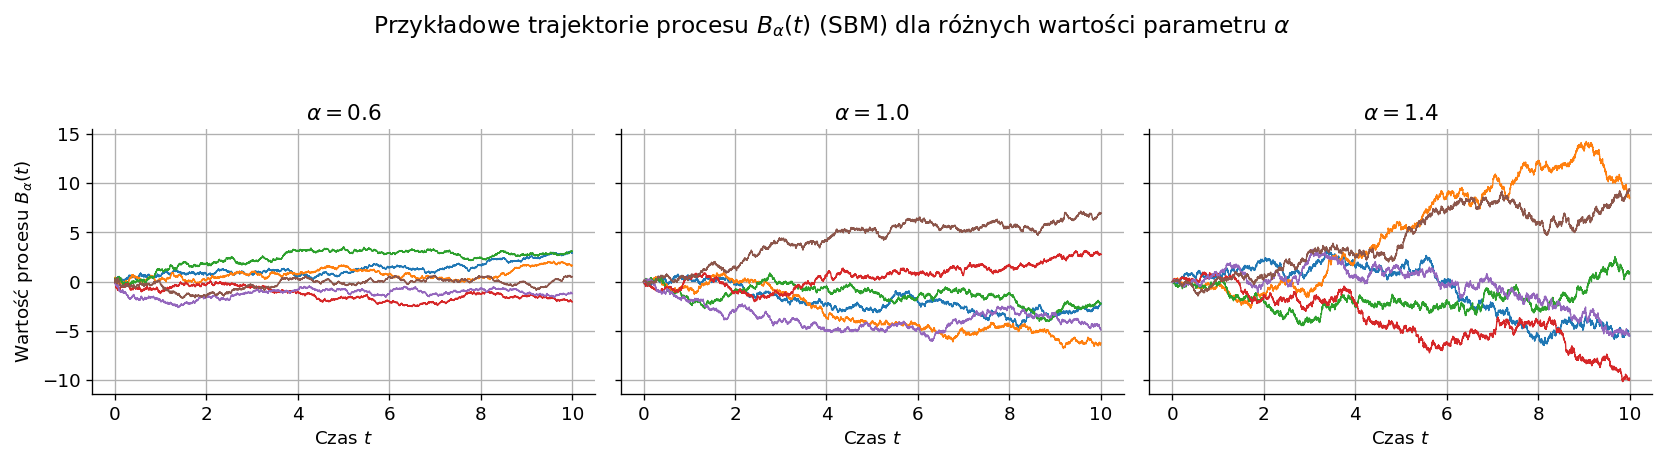

In [4]:
rng = np.random.default_rng(seed=12)
T = 10.0
dt = 0.001
alphas = [0.6, 1.0, 1.4]
n_paths = 6  # ile trajektorii na panel

fig, axes = plt.subplots(1, 3, sharey=True)

for ax, alpha in zip(axes, alphas):
    t, X = simulate_sbm(alpha=alpha, T=T, dt=dt, n_paths=n_paths, rng=rng)
    for i in range(n_paths):
        ax.plot(t, X[i, :], linewidth=0.8)

    ax.set_title(rf"$\alpha = {alpha}$")
    ax.set_xlabel(r"Czas $t$")

axes[0].set_ylabel(r"Wartość procesu $B_{\alpha}(t)$")
fig.suptitle(r"Przykładowe trajektorie procesu $B_{\alpha}(t)$ (SBM) "
    r"dla różnych wartości parametru $\alpha$")
fig.tight_layout(rect=[0, 0.03, 1, 0.93])

plt.savefig("trajektorie_SBM.png", dpi=300)
plt.show()

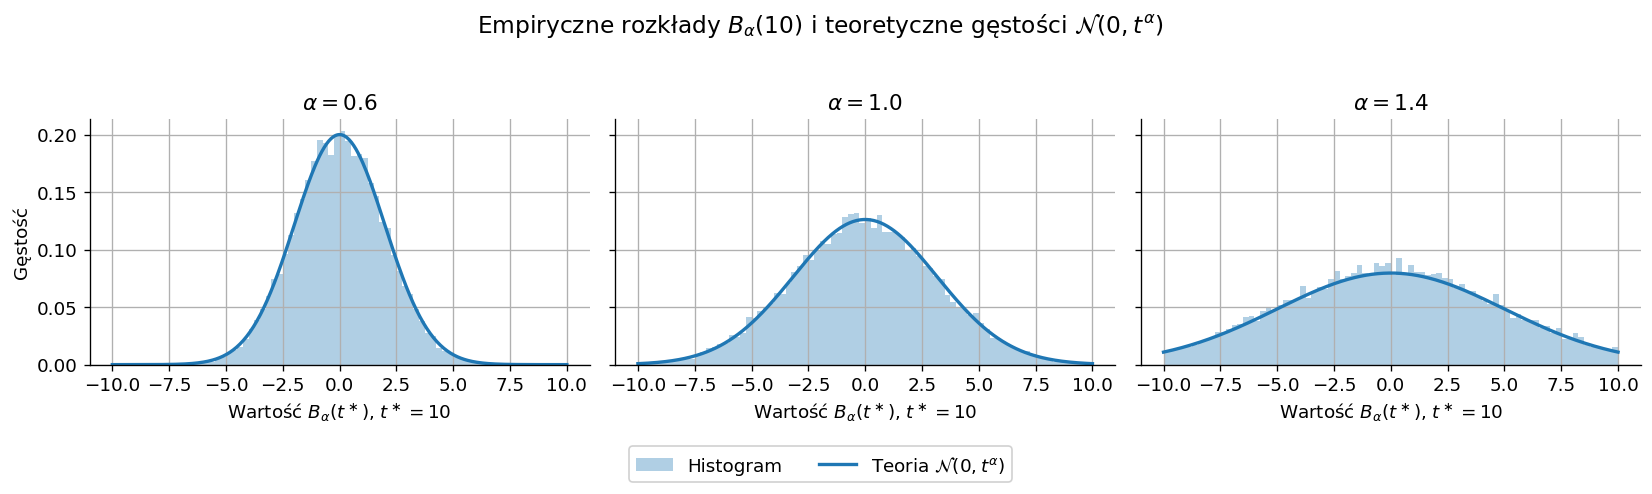

In [5]:
rng = np.random.default_rng(seed=12345)

T = 10.0
dt = 0.001
t_star = 10.0
M = 20000
alphas = [0.6, 1.0, 1.4]

x_min, x_max = -10, 10
x_grid = np.linspace(x_min, x_max, 400)

fig, axes = plt.subplots(1, 3, sharey=True)

for j, (ax, alpha) in enumerate(zip(axes, alphas)):
    t, X = simulate_sbm(alpha=alpha, T=T, dt=dt, n_paths=M, rng=rng)
    samples = X[:, -1]

    # Histogram – etykiety tylko w pierwszym panelu
    if j == 0:
        ax.hist(samples,
                bins=80,
                range=(x_min, x_max),
                density=True,
                alpha=0.35,
                color="tab:blue",
                label="Histogram")
    else:
        ax.hist(samples,
                bins=80,
                range=(x_min, x_max),
                density=True,
                alpha=0.35,
                color="tab:blue")

    # Teoretyczna gęstość
    var = t_star ** alpha
    pdf_vals = normal_pdf(x_grid, mean=0.0, var=var)
    if j == 0:
        ax.plot(x_grid, pdf_vals, linewidth=2,
                label=r"Teoria $\mathcal{N}(0,t^\alpha)$")
    else:
        ax.plot(x_grid, pdf_vals, linewidth=2)

    ax.set_title(rf"$\alpha = {alpha}$")
    ax.set_xlabel(r"Wartość $B_{\alpha}(t^\ast)$, $t^\ast = 10$")
    ax.grid(True)

axes[0].set_ylabel("Gęstość")

# globalna legenda pod wykresem
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    r"Empiryczne rozkłady $B_{\alpha}(10)$ "
    r"i teoretyczne gęstości $\mathcal{N}(0,t^\alpha)$"
)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

plt.savefig("gestosci_SBM_tstar10.png", dpi=300, bbox_inches="tight")
plt.show()


### SBMRE symulacja i wizualizacja

In [6]:
def sample_alpha_two_point(n, rng, A1=0.8, A2=2.0, p=0.5):
    """Rozkład dwupunktowy: P(alpha=A1)=p, P(alpha=A2)=1-p."""
    u = rng.uniform(size=n)
    alphas = np.where(u < p, A1, A2)
    return alphas


def sample_alpha_beta_segment(n, rng, A1=0.8, A2=2.0, gamma=0.5, beta=0.5):
    """
    Rozkład beta przeskalowany na [A1, A2]: alpha = A1 + (A2-A1)*Y,  Y ~ Beta(gamma, beta).
    Uwaga: gamma,beta > 0.
    """
    y = rng.beta(gamma, beta, size=n)
    alphas = A1 + (A2 - A1) * y
    return alphas

def sample_alpha_uniform_segment(n, rng, A1=0.8, A2=2.0):
    """
    Rozkład jednostajny na [A1, A2]:
        alpha ~ U(A1, A2)
    Zwraca wektor długości n.
    """
    if not np.isfinite(A1) or not np.isfinite(A2):
        raise ValueError("A1 i A2 muszą być skończone.")
    if A2 <= A1:
        raise ValueError("Wymagane A2 > A1.")
    return rng.uniform(A1, A2, size=n)


In [7]:
def simulate_sbmre(T: float, dt: float, n_paths: int, seed: int, alpha_sampler):
    rng = np.random.default_rng(seed)
    N = int(np.round(T / dt))
    t = np.linspace(0.0, T, N + 1)

    alphas = alpha_sampler(n_paths, rng)
    X_all = np.zeros((n_paths, N + 1))

    for i in range(n_paths):
        alpha_i = alphas[i]
        t_, Xi = simulate_sbm(alpha_i, T, dt, 1, rng)
        X_all[i] = Xi[0]
    return t, X_all, alphas

In [8]:
import numpy as np

# ---------------------------------------------
# Parametry rozkładów wykładnika 𝓐 (E[𝓐] ≈ 1.4)
# ---------------------------------------------
A1 = 0.8
A2 = 2.0   # tak, żeby E[A] = (A1 + A2)/2 = 1.4 dla dwupunktowego / jednostajnego

# bazowe samplery, które mieliśmy wcześniej
def sample_alpha_two_point(n, rng, A1=A1, A2=A2, p=0.5):
    """
    Rozkład dwupunktowy:
        P(A = A1) = p,  P(A = A2) = 1-p.
    """
    u = rng.uniform(size=n)
    alphas = np.where(u < p, A1, A2)
    return alphas


def sample_alpha_uniform_segment(n, rng, A1=A1, A2=A2):
    """
    Rozkład jednostajny na [A1, A2].
    """
    return rng.uniform(A1, A2, size=n)


def sample_alpha_beta_segment(n, rng, A1=A1, A2=A2, gamma=0.5, beta=0.5):
    """
    Rozkład Beta przeskalowany na [A1, A2]:
        Y ~ Beta(gamma, beta)
        A = A1 + (A2 - A1) * Y
    """
    y = rng.beta(gamma, beta, size=n)
    alphas = A1 + (A2 - A1) * y
    return alphas


# ---------------------------------------------
# Samplery w formie "opakowań" (bez dodatkowych argumentów)
# używane np. przy simulate_sbmre(...)
# ---------------------------------------------

def alpha_sampler_two_point(n, rng):
    return sample_alpha_two_point(n, rng, A1=A1, A2=A2, p=0.5)

def alpha_sampler_uniform(n, rng):
    return sample_alpha_uniform_segment(n, rng, A1=A1, A2=A2)

def alpha_sampler_beta(n, rng):
    # tu zostawiamy Beta(0.5, 0.5) przeskalowaną na [A1, A2]
    return sample_alpha_beta_segment(n, rng, A1=A1, A2=A2, gamma=0.5, beta=0.5)


# Lista do pętli po rozkładach (np. przy generowaniu sbmre_results)
samplers = [
    ("dwupunktowy", alpha_sampler_two_point, 321),
    ("jednostajny", alpha_sampler_uniform,   654),
    ("Beta",        alpha_sampler_beta,      987),
]


In [9]:
# def make_sampler_two_point(A1: float, A2: float, p: float):
#     def _sampler(n, rng):
#         return sample_alpha_two_point(n, rng, A1=A1, A2=A2, p=p)
#     return _sampler


# def make_sampler_beta(A1: float, A2: float, gamma: float, beta: float):
#     def _sampler(n, rng):
#         return sample_alpha_beta_segment(n, rng, A1=A1, A2=A2, gamma=gamma, beta=beta)
#     return _sampler

# def make_sampler_uniform(A1: float, A2: float):
#     def _sampler(n, rng):
#         return sample_alpha_uniform_segment(n, rng, A1=A1, A2=A2)
#     return _sampler

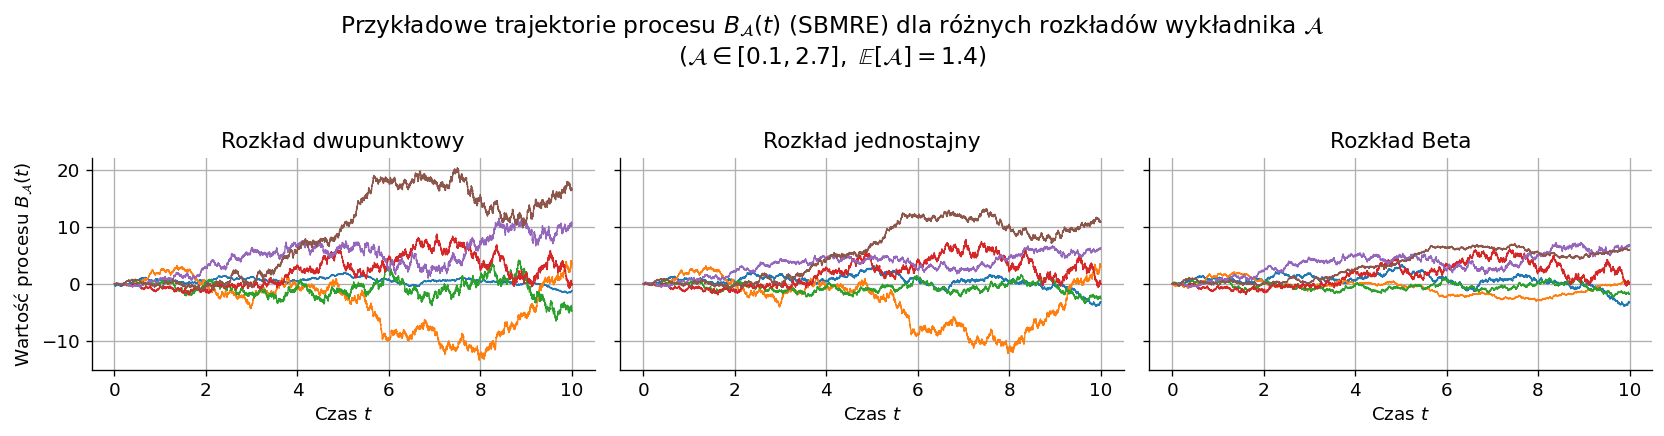

In [10]:
%matplotlib inline

# parametry
T = 10.0          # przedział czasu [0,10], żeby było spójnie z SBM
dt = 0.001
n_paths = 6

samplers = [
    (r"dwupunktowy", alpha_sampler_two_point, 2137),
    (r"jednostajny", alpha_sampler_uniform,   2137),
    (r"Beta",        alpha_sampler_beta,      2137),
]

fig, axes = plt.subplots(1, 3, sharey=True)

for ax, (name, sampler, seed) in zip(axes, samplers):
    t, X_all, alphas = simulate_sbmre(T=T, dt=dt, n_paths=n_paths,
                                     seed=seed, alpha_sampler=sampler)

    for i in range(n_paths):
        ax.plot(t, X_all[i, :], linewidth=0.8)

    ax.set_title(rf"Rozkład {name}")
    ax.set_xlabel(r"Czas $t$")

axes[0].set_ylabel(r"Wartość procesu $B_{\mathcal{A}}(t)$")
fig.suptitle(
    r"Przykładowe trajektorie procesu $B_{\mathcal{A}}(t)$ (SBMRE) "
    r"dla różnych rozkładów wykładnika $\mathcal{A}$"
    "\n"
    r"($\mathcal{A}\in[0.1,2.7],\ \mathbb{E}[\mathcal{A}]=1.4$)"
)
fig.tight_layout(rect=[0, 0.08, 1, 0.93])

plt.savefig("trajektorie_SBMRE.png", dpi=300)
plt.show()

In [11]:
T = 10.0
t_star = 10.0
M = 20000

x_min, x_max = -15, 15
x_grid = np.linspace(x_min, x_max, 500)

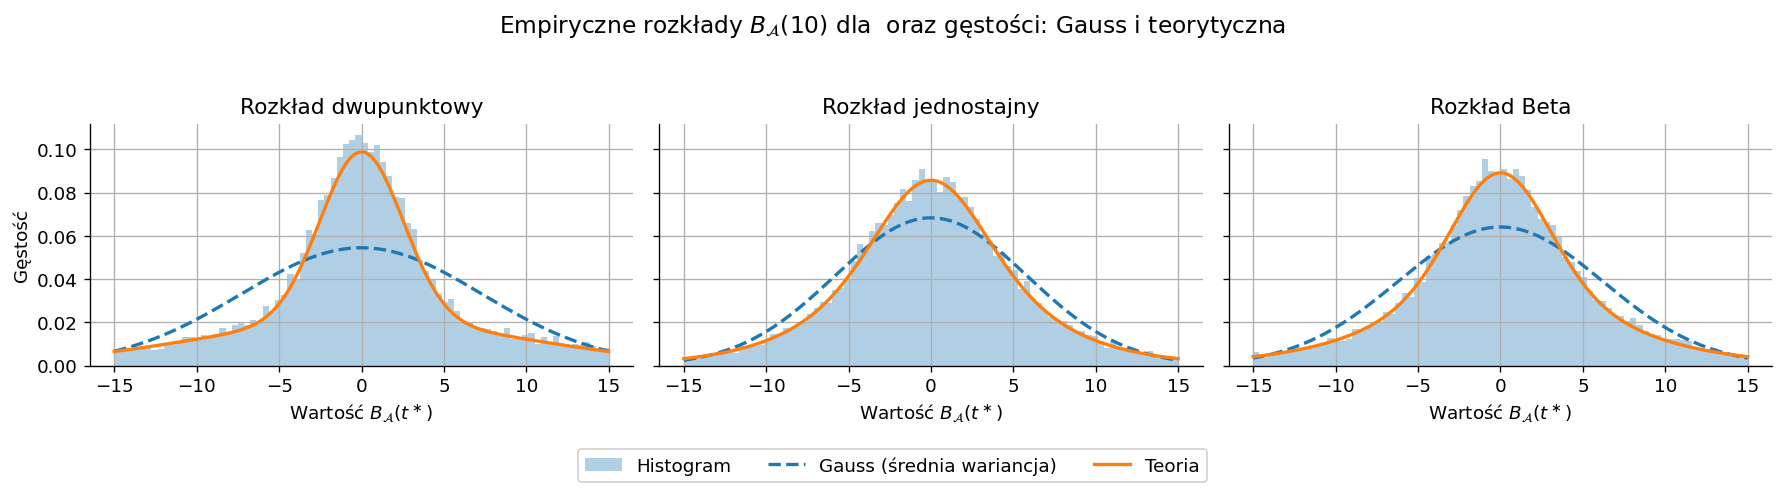

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for j, (ax, (name, sampler, seed)) in enumerate(zip(axes, samplers)):
    rng = np.random.default_rng(seed)

    alphas = sampler(M, rng)
    Z = rng.normal(0.0, 1.0, size=M)
    vars_ = t_star ** alphas
    samples = Z * np.sqrt(vars_)

    # tylko w pierwszym panelu ustawiamy label-e
    if j == 0:
        ax.hist(samples, bins=80, range=(x_min, x_max),
                density=True, alpha=0.35, color="tab:blue",
                label="Histogram")
    else:
        ax.hist(samples, bins=80, range=(x_min, x_max),
                density=True, alpha=0.35, color="tab:blue")

    mean_var = np.mean(vars_)
    gauss_pdf = norm.pdf(x_grid, loc=0.0, scale=np.sqrt(mean_var))
    if j == 0:
        ax.plot(x_grid, gauss_pdf, linestyle="--", linewidth=2,
                label=r"Gauss (średnia wariancja)")
    else:
        ax.plot(x_grid, gauss_pdf, linestyle="--", linewidth=2)

    pdf_vals = norm.pdf(x_grid[None, :],
                        loc=0.0,
                        scale=np.sqrt(vars_)[:, None])
    mix_pdf = pdf_vals.mean(axis=0)
    if j == 0:
        ax.plot(x_grid, mix_pdf, linewidth=2,
                label=r"Teoria")
    else:
        ax.plot(x_grid, mix_pdf, linewidth=2)

    ax.set_title(fr"Rozkład {name}")
    ax.set_xlabel(r"Wartość $B_{\mathcal{A}}(t^\ast)$")
    ax.grid(True)

axes[0].set_ylabel("Gęstość")

# globalna legenda pod wykresem
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.02))

title = (
    r"Empiryczne rozkłady $B_{\mathcal{A}}(10)$ dla "
    r" oraz gęstości: Gauss i teorytyczna"
)
fig.suptitle(title)
fig.tight_layout(rect=[0, 0.08, 1, 0.94])

plt.savefig("gestosci_SBMRE_tstar10.png", dpi=300, bbox_inches="tight")
plt.show()


### Miary dynamiki procesu

In [126]:
# Parametry do porównań SBM vs SBMRE
T = 10.0
dt = 0.001
n_paths = 1000   # możesz zwiększyć, jeśli komputer wytrzyma

rng = np.random.default_rng(2025)

# --- SBM z deterministycznym alpha = 1.4 ---
alpha_sbm = 1.4
t_sbm, X_sbm = simulate_sbm(alpha=alpha_sbm,
                            T=T,
                            dt=dt,
                            n_paths=n_paths,
                            rng=rng)

# --- SBMRE dla trzech rozkładów A ---
# upewniamy się, że mamy listę samplerów
samplers = [
    (r"dwupunktowy", alpha_sampler_two_point, 123),
    (r"jednostajny", alpha_sampler_uniform,   456),
    (r"Beta",        alpha_sampler_beta,      789),
]

sbmre_results = {}  # name -> dict z trajektoriami i alphas

for name, sampler, seed in samplers:
    t_re, X_re, alphas_re = simulate_sbmre(
        T=T,
        dt=dt,
        n_paths=n_paths,
        seed=seed,
        alpha_sampler=sampler
    )
    sbmre_results[name] = {
        "t": t_re,
        "X": X_re,
        "alphas": alphas_re
    }

# kontrolnie:
print("SBM  alpha =", alpha_sbm)
for name, data in sbmre_results.items():
    print(f"SBMRE ({name}): E[A] ~ {np.mean(data['alphas']):.3f}, min={data['alphas'].min():.3f}, max={data['alphas'].max():.3f}")


SBM  alpha = 1.4
SBMRE (dwupunktowy): E[A] ~ 1.399, min=0.800, max=2.000
SBMRE (jednostajny): E[A] ~ 1.410, min=0.801, max=2.000
SBMRE (Beta): E[A] ~ 1.386, min=0.800, max=2.000


In [127]:
def ensemble_msd(X: np.ndarray) -> np.ndarray:
    """
    MSD(t) = <X(t)^2> – średnia po trajektoriach.
    X ma kształt (n_paths, N+1).
    """
    return np.mean(X**2, axis=0)

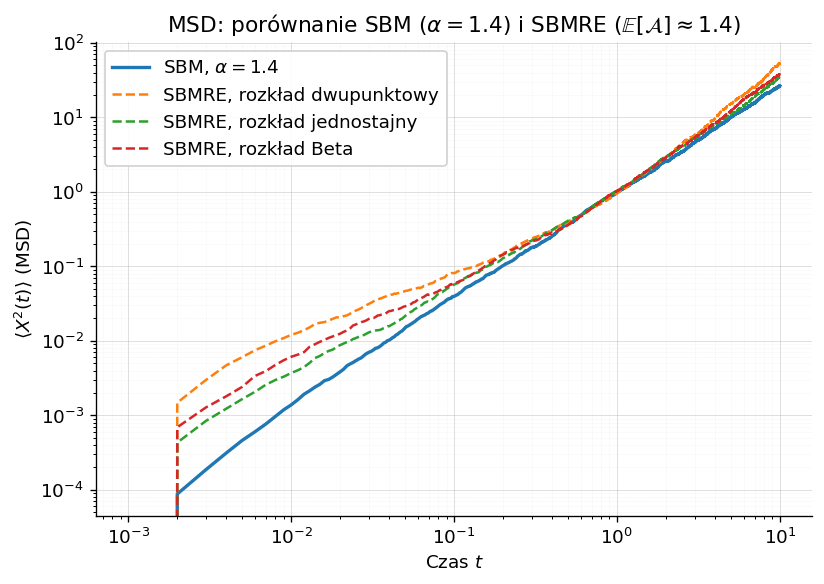

In [128]:
# MSD dla SBM
msd_sbm = ensemble_msd(X_sbm)

# MSD dla SBMRE (dla każdego rozkładu A)
msd_sbmre = {}
for name, data in sbmre_results.items():
    msd_sbmre[name] = ensemble_msd(data["X"])

plt.figure(figsize=(7, 5))

# log-log, pomijamy t=0
plt.loglog(t_sbm[1:], msd_sbm[1:],
           label=rf"SBM, $\alpha = {alpha_sbm}$",
           linewidth=2)

for name, data in sbmre_results.items():
    t_re = data["t"]
    msd_re = msd_sbmre[name]
    plt.loglog(t_re[1:], msd_re[1:],
               linestyle="--",
               linewidth=1.5,
               label=rf"SBMRE, rozkład {name}")

plt.xlabel(r"Czas $t$")
plt.ylabel(r"$\langle X^2(t) \rangle$ (MSD)")
plt.title(r"MSD: porównanie SBM ($\alpha=1.4$) i SBMRE ($\mathbb{E}[\mathcal{A}] \approx 1.4$)")
plt.legend()
plt.grid(which="major", linestyle="-", linewidth=0.4, alpha=0.6)
plt.grid(which="minor", linestyle=":", linewidth=0.3, alpha=0.3)

plt.tight_layout()
plt.show()


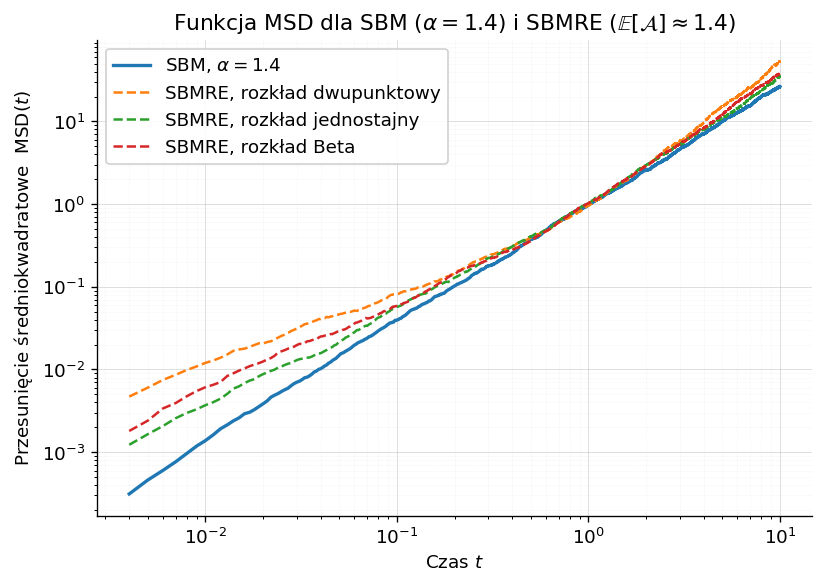

In [129]:
# wybieramy minimalny czas, od którego rysujemy (np. 1e-2)
t_min = 10**(-2.5)

plt.figure(figsize=(7, 5))

# --- SBM ---
mask_sbm = t_sbm >= t_min
plt.loglog(
    t_sbm[mask_sbm],
    msd_sbm[mask_sbm],
    label=rf"SBM, $\alpha = {alpha_sbm}$",
    linewidth=2
)

# --- SBMRE ---
for name, data in sbmre_results.items():
    t_re = data["t"]
    msd_re = msd_sbmre[name]

    mask_re = t_re >= t_min
    plt.loglog(
        t_re[mask_re],
        msd_re[mask_re],
        linestyle="--",
        linewidth=1.5,
        label=rf"SBMRE, rozkład {name}"
    )

plt.xlabel(r"Czas $t$")
plt.ylabel(r"Przesunięcie średniokwadratowe  MSD$(t)$")
plt.title(
    r"Funkcja MSD dla SBM ($\alpha=1.4$) i SBMRE "
    r"($\mathbb{E}[\mathcal{A}] \approx 1.4$)"
)
plt.legend()
plt.grid(which="major", linestyle="-", linewidth=0.4, alpha=0.6)
plt.grid(which="minor", linestyle=":", linewidth=0.3, alpha=0.3)

plt.tight_layout()
plt.show()


In [130]:
def tamsd_all_lags(X: np.ndarray,
                   dt: float,
                   lag_max_fraction: float = 0.25,
                   n_lags: int = 40):
    """
    Zwraca:
        tau       – czasy opóźnienia (τ) (n_lags,)
        lags      – opóźnienia w krokach (n_lags,)
        tamsd_all – macierz TAMSD dla każdej trajektorii i każdego τ,
                    shape = (n_paths, n_lags)
    """
    n_paths, Np1 = X.shape
    N = Np1 - 1

    max_lag = int(lag_max_fraction * N)
    max_lag = max(1, max_lag)

    lags = np.unique(
        np.logspace(0, np.log10(max_lag), n_lags).astype(int)
    )
    tau = lags * dt

    tamsd_all = np.zeros((n_paths, len(lags)))

    for k, lag in enumerate(lags):
        diffs = X[:, lag:] - X[:, :-lag]  # (n_paths, N+1-lag)
        sq = diffs**2
        # średnia po czasie – dla każdej trajektorii osobno
        tamsd_all[:, k] = np.mean(sq, axis=1)

    return tau, lags, tamsd_all

# --- liczymy TAMSD dla SBM i SBMRE ---

tamsd_data = {}

# SBM
tau_sbm, lags_sbm, tamsd_sbm_all = tamsd_all_lags(X_sbm, dt)
tamsd_data["SBM"] = {
    "tau": tau_sbm,
    "lags": lags_sbm,
    "paths": tamsd_sbm_all
}

# SBMRE (każdy rozkład A osobno)
for name, data in sbmre_results.items():
    tau_re, lags_re, tamsd_re_all = tamsd_all_lags(data["X"], dt)
    tamsd_data[f"SBMRE_{name}"] = {
        "tau": tau_re,
        "lags": lags_re,
        "paths": tamsd_re_all
    }

# podgląd
for key, d in tamsd_data.items():
    print(key, d["paths"].shape)


SBM (1000, 35)
SBMRE_dwupunktowy (1000, 35)
SBMRE_jednostajny (1000, 35)
SBMRE_Beta (1000, 35)


Boxplot dla tau ≈ 0.916


C:\Users\User\AppData\Local\Temp\ipykernel_1180\2534097965.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=labels, showfliers=False)


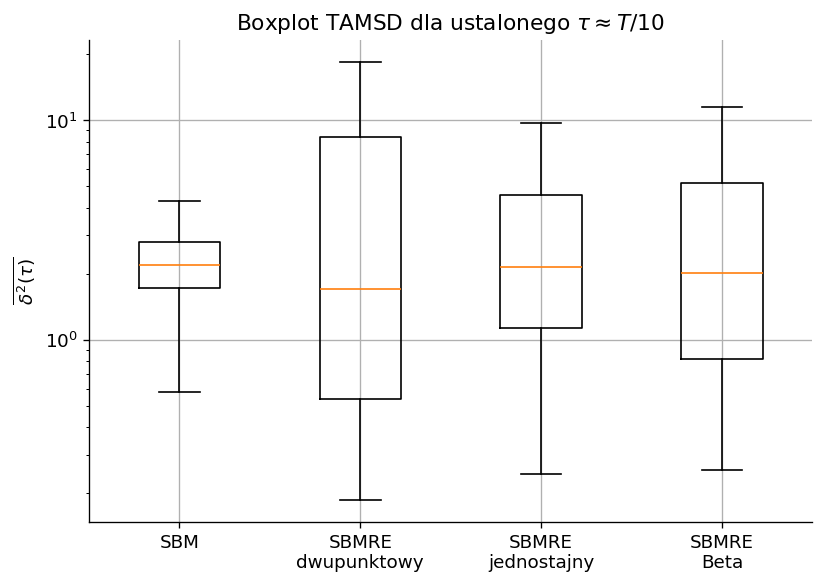

In [131]:
# wybieramy τ ~ T/10 (jak wcześniej)
T_total = t_sbm[-1]
tau_target = T_total / 10.0

# wybieramy najbliższy index w siatce τ
tau_arr = tamsd_data["SBM"]["tau"]
idx_tau = np.argmin(np.abs(tau_arr - tau_target))
tau_fixed = tau_arr[idx_tau]
print(f"Boxplot dla tau ≈ {tau_fixed:.3f}")

labels = []
data_box = []

# SBM
labels.append("SBM")
data_box.append(tamsd_data["SBM"]["paths"][:, idx_tau])

# SBMRE
for name in ["dwupunktowy", "jednostajny", "Beta"]:
    key = f"SBMRE_{name}"
    labels.append(f"SBMRE\n{name}")
    data_box.append(tamsd_data[key]["paths"][:, idx_tau])

plt.figure(figsize=(7, 5))
plt.boxplot(data_box, labels=labels, showfliers=False)
plt.yscale("log")
plt.ylabel(r"$\overline{\delta^2(\tau)}$")
plt.title(r"Boxplot TAMSD dla ustalonego $\tau \approx T/10$")
plt.tight_layout()
plt.show()


Boxplot dla tau ≈ 0.916


C:\Users\User\AppData\Local\Temp\ipykernel_1180\1728705450.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=labels, showfliers=False)


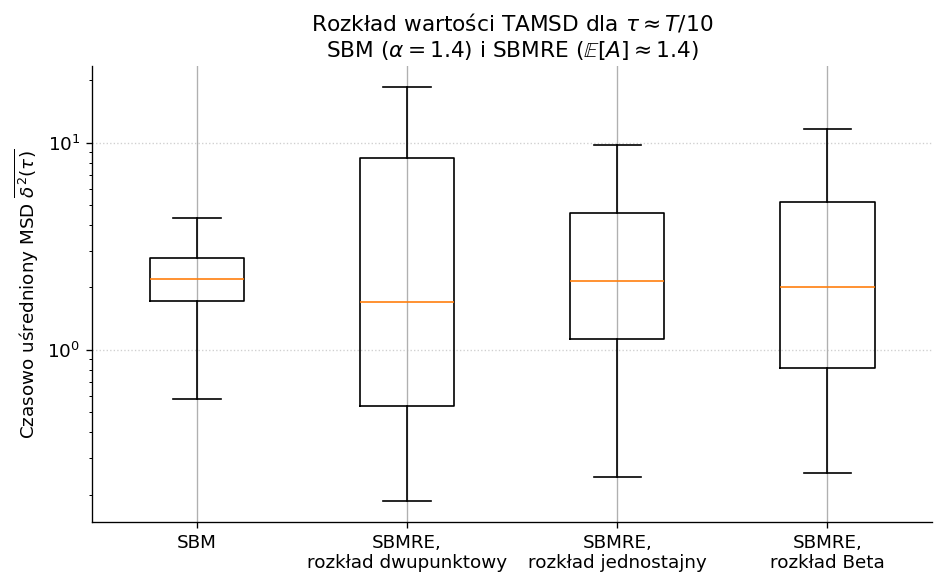

In [137]:
# wybieramy τ ≈ T/10
T_total = t_sbm[-1]
tau_target = T_total / 10.0

tau_arr = tamsd_data["SBM"]["tau"]
idx_tau = np.argmin(np.abs(tau_arr - tau_target))
tau_fixed = tau_arr[idx_tau]
print(f"Boxplot dla tau ≈ {tau_fixed:.3f}")

labels = []
data_box = []

# SBM
labels.append("SBM")
data_box.append(tamsd_data["SBM"]["paths"][:, idx_tau])

# SBMRE – rozkłady wykładnika A
pretty_names = {
    "dwupunktowy": "rozkład dwupunktowy",
    "jednostajny": "rozkład jednostajny",
    "Beta":        "rozkład Beta"
}

for name in ["dwupunktowy", "jednostajny", "Beta"]:
    key = f"SBMRE_{name}"
    labels.append(f"SBMRE,\n{pretty_names[name]}")
    data_box.append(tamsd_data[key]["paths"][:, idx_tau])

plt.figure(figsize=(8, 5))
plt.boxplot(data_box, labels=labels, showfliers=False)

plt.yscale("log")
plt.ylabel(r"Czasowo uśredniony MSD $\overline{\delta^2(\tau)}$")
plt.title(
    r"Rozkład wartości TAMSD dla $\tau \approx T/10$"
    "\n"
    r"SBM ($\alpha = 1.4$) i SBMRE ($\mathbb{E}[A] \approx 1.4$)"
)
#plt.title(r"Porównanie funkcji TAMSD($\tau \approx T/10) - porównanie SBM i SBMRE")
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


In [133]:
# import numpy as np
# import matplotlib.pyplot as plt

# # frakcje całkowitego czasu, dla których robimy boxploty
# tau_fractions = [1/20, 1/10, 1/5]   # ≈ T/20, T/10, T/5

# tau_arr = tamsd_data["SBM"]["tau"]   # siatka τ (taka sama dla wszystkich modeli)
# T_total = tau_arr[-1]                # maksymalne dostępne opóźnienie

# for frac in tau_fractions:
#     # docelowe tau
#     tau_target = frac * T_total

#     # wybieramy najbliższy index w siatce τ
#     idx_tau = np.argmin(np.abs(tau_arr - tau_target))
#     tau_fixed = tau_arr[idx_tau]
#     print(f"Boxplot dla tau ≈ {tau_fixed:.3f} (≈ {frac:.2f} T)")

#     labels = []
#     data_box = []

#     # SBM
#     labels.append("SBM")
#     data_box.append(tamsd_data["SBM"]["paths"][:, idx_tau])

#     # SBMRE
#     for name in ["dwupunktowy", "jednostajny", "Beta"]:
#         key = f"SBMRE_{name}"
#         labels.append(f"SBMRE\n{name}")
#         data_box.append(tamsd_data[key]["paths"][:, idx_tau])

#     # rysujemy boxplot
#     plt.figure(figsize=(7, 5))
#     plt.boxplot(data_box, labels=labels, showfliers=False)
#     plt.yscale("log")
#     plt.ylabel(r"$\overline{\delta^2(\tau)}$")
#     plt.title(rf"Boxplot TAMSD dla $\tau \approx {tau_fixed:.3f}$ (≈ {frac:.2f} T)")
#     plt.tight_layout()
#     plt.show()


In [134]:
def dma_single(x: np.ndarray, tau_steps: int) -> float:
    """
    DMA dla jednej trajektorii x i rozmiaru okna tau_steps (w krokach).
    """
    n = len(x)
    if tau_steps < 2 or tau_steps >= n:
        raise ValueError("tau_steps musi być w [2, n-1].")

    sq_vals = []
    for j in range(tau_steps - 1, n):
        window = x[j - tau_steps + 1: j + 1]
        mean = np.mean(window)
        sq_vals.append((x[j] - mean) ** 2)

    return float(np.mean(sq_vals))


def dma_ensemble(X: np.ndarray,
                 dt: float,
                 tau_max_fraction: float = 0.25,
                 n_taus: int = 20,
                 max_paths: int = 200):
    """
    DMA(τ) uśrednione po trajektoriach (na podzbiorze max_paths trajektorii,
    żeby nie zabić komputera).

    Zwraca:
        tau_times – czasy okna (τ)
        dma_mean  – wartości DMA(τ)
    """
    n_paths, n_points = X.shape

    # Podzbiór trajektorii do liczenia DMA
    m = min(max_paths, n_paths)
    X_sub = X[:m]   # bierzemy pierwsze m ścieżek; można też losować

    # maksymalne okno w krokach (nie może przekraczać n_points-1)
    max_tau_steps = int(tau_max_fraction * n_points)
    max_tau_steps = max(3, min(max_tau_steps, n_points - 1))

    # logarytmiczna siatka od 2 do max_tau_steps
    tau_steps_arr = np.unique(
        np.logspace(np.log10(2), np.log10(max_tau_steps), n_taus).astype(int)
    )
    # filtr bezpieczeństwa
    tau_steps_arr = tau_steps_arr[(tau_steps_arr >= 2) & (tau_steps_arr < n_points)]

    tau_times = tau_steps_arr * dt
    dma_mean = np.zeros_like(tau_steps_arr, dtype=float)

    for k, tau_steps in enumerate(tau_steps_arr):
        vals = [dma_single(X_sub[i], tau_steps) for i in range(m)]
        dma_mean[k] = np.mean(vals)

    return tau_times, dma_mean


In [135]:
# # DMA dla SBM
# tau_dma_sbm, dma_sbm = dma_ensemble(X_sbm, dt,
#                                     tau_max_fraction=0.25,
#                                     n_taus=20,
#                                     max_paths=200)

# # DMA dla SBMRE
# dma_sbmre = {}
# tau_dma_sbmre = {}
# for name, data in sbmre_results.items():
#     tau_dma_re, dma_re = dma_ensemble(data["X"], dt,
#                                       tau_max_fraction=0.1,
#                                       n_taus=15,
#                                       max_paths=200)
#     tau_dma_sbmre[name] = tau_dma_re
#     dma_sbmre[name] = dma_re


# plt.figure(figsize=(7, 5))

# plt.loglog(tau_dma_sbm, dma_sbm,
#            label=rf"SBM, $\alpha = {alpha_sbm}$",
#            linewidth=2)

# for name in sbmre_results.keys():
#     plt.loglog(tau_dma_sbmre[name], dma_sbmre[name],
#                linestyle="--",
#                linewidth=1.5,
#                label=rf"SBMRE, rozkład {name}")

# plt.xlabel(r"Rozmiar okna $\tau$")
# plt.ylabel(r"DMA($\tau$)")
# plt.title(r"DMA: porównanie SBM ($\alpha=1.4$) i SBMRE")
# plt.legend()
# plt.grid(True, which="both", ls=":")

# plt.tight_layout()
# plt.show()


In [136]:
def dma_per_trajectory(X: np.ndarray, dt: float, tau_steps: int) -> np.ndarray:
    """
    Zwraca tablicę DMA(τ) policzoną osobno dla każdej trajektorii,
    dla ustalonego rozmiaru okna tau_steps (w krokach).
    """
    n_paths, n_points = X.shape
    vals = np.zeros(n_paths)
    for i in range(n_paths):
        vals[i] = dma_single(X[i], tau_steps)
    return vals

# wybieramy tau ~ T/10
T = t_sbm[-1]
dt = t_sbm[1] - t_sbm[0]
tau_target = T / 10.0
tau_steps = int(tau_target / dt)
tau_fixed = tau_steps * dt
print(f"Używam okna tau ≈ {tau_fixed:.3f}, tau_steps = {tau_steps}")

# DMA(τ*) dla SBM
dma_paths_sbm = dma_per_trajectory(X_sbm, dt, tau_steps)

# DMA(τ*) dla SBMRE
dma_paths_sbmre = {}
for name, data in sbmre_results.items():
    dma_paths_sbmre[name] = dma_per_trajectory(data["X"], dt, tau_steps)

# BOX PLOT
labels = ["SBM"] + [f"SBMRE\n{name}" for name in sbmre_results.keys()]
data_box = [dma_paths_sbm] + [dma_paths_sbmre[name] for name in sbmre_results.keys()]

plt.figure(figsize=(7,5))
plt.boxplot(data_box, labels=labels, showfliers=False)
plt.yscale("log")
plt.ylabel(r"DMA($\tau$)")
plt.title(r"Boxplot DMA dla ustalonego okna $\tau \approx T/10$")
plt.tight_layout()
plt.show()


Używam okna tau ≈ 1.000, tau_steps = 1000


KeyboardInterrupt: 

Użyte opóźnienie: τ ≈ 1.000, tau_steps = 1000


C:\Users\User\AppData\Local\Temp\ipykernel_1180\413843471.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=labels, showfliers=False)
C:\Users\User\AppData\Local\Temp\ipykernel_1180\413843471.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=labels, showfliers=False)


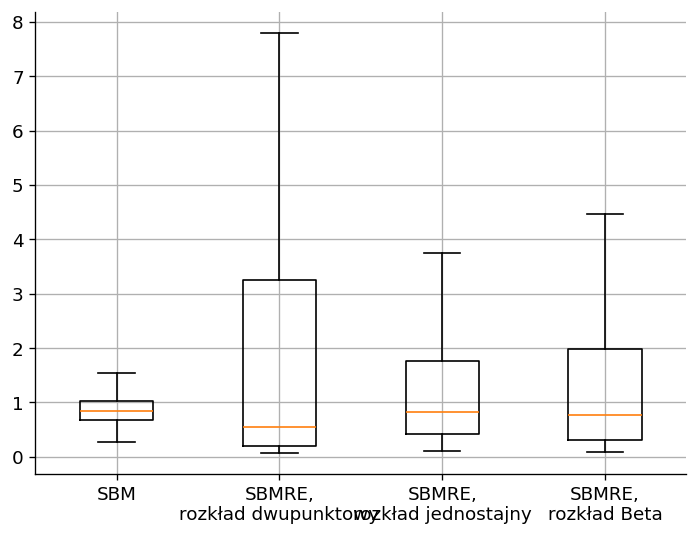

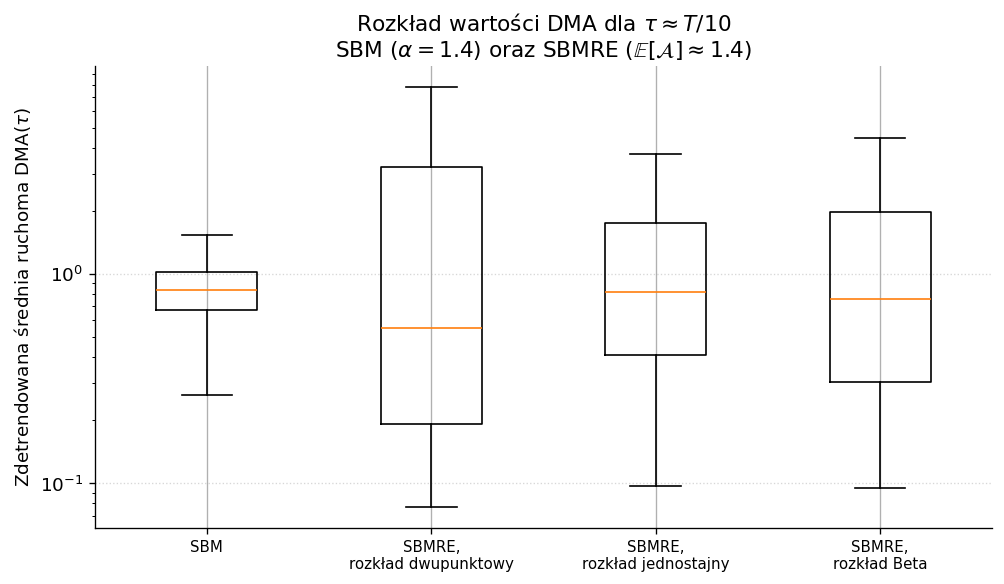

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Funkcja DMA dla każdej trajektorii (czasowo uśrednione odchylenie)
# ============================================================

def dma_per_trajectory(X: np.ndarray, dt: float, tau_steps: int) -> np.ndarray:
    """
    Zwraca wartości DMA(τ) policzone oddzielnie dla każdej trajektorii.
    
    X : ndarray (n_paths, n_points)
    tau_steps : liczba kroków czasowych okna τ
    """
    n_paths, _ = X.shape
    out = np.zeros(n_paths)

    for i in range(n_paths):
        out[i] = dma_single(X[i], tau_steps)

    return out


# ============================================================
# Ustalanie τ ≈ T/10
# ============================================================

T = t_sbm[-1]                       # całkowity czas
dt = t_sbm[1] - t_sbm[0]            # krok czasowy
tau_target = T / 10.0               # interesująca skala opóźnienia
tau_steps = int(tau_target / dt)    # liczba kroków
tau_fixed = tau_steps * dt          # dokładna wartość τ w siatce

print(f"Użyte opóźnienie: τ ≈ {tau_fixed:.3f}, tau_steps = {tau_steps}")


# ============================================================
# DMA dla SBM
# ============================================================

dma_paths_sbm = dma_per_trajectory(X_sbm, dt, tau_steps)


# ============================================================
# DMA dla SBMRE — dla każdego rozkładu A
# ============================================================

dma_paths_sbmre = {}

for name, data in sbmre_results.items():
    dma_paths_sbmre[name] = dma_per_trajectory(data["X"], dt, tau_steps)


# ============================================================
# Boxplot — spójny styl jak MSD i TAMSD
# ============================================================

labels = [
    "SBM",
    "SBMRE,\nrozkład dwupunktowy",
    "SBMRE,\nrozkład jednostajny",
    "SBMRE,\nrozkład Beta"
]

data_box = [
    dma_paths_sbm,
    dma_paths_sbmre["dwupunktowy"],
    dma_paths_sbmre["jednostajny"],
    dma_paths_sbmre["Beta"],
]

plt.figure(figsize=(7,5))
plt.boxplot(data_box, labels=labels, showfliers=False)
fig, ax = plt.subplots(figsize=(8.5, 5))  # było (7,5)

ax.boxplot(data_box, labels=labels, showfliers=False)
ax.set_yscale("log")

ax.set_ylabel(r"Zdetrendowana średnia ruchoma DMA$(\tau)$")
ax.set_title(
    r"Rozkład wartości DMA dla $\tau \approx T/10$"
    "\n"
    r"SBM ($\alpha=1.4$) oraz SBMRE ($\mathbb{E}[\mathcal{A}] \approx 1.4$)"
)

ax.grid(axis="y", linestyle=":", alpha=0.5)

# mniejsza czcionka na osi x, żeby się nie stykały
for tick in ax.get_xticklabels():
    tick.set_fontsize(9)

fig.tight_layout()
plt.show()



### miary kształtu rozkładu

In [25]:
import numpy as np
from scipy.stats import skew, kurtosis

# ------------------------------------------------
# Funkcje pomocnicze: kurtoza(t), skosnosc(t)
# ------------------------------------------------

def time_kurtosis(X: np.ndarray) -> np.ndarray:
    """
    Kurtoza rozkładu w każdej chwili czasu.
    X: macierz (n_paths, n_points) – M trajektorii.
    Zwraca: wektor długości n_points.
    """
    n_paths, n_points = X.shape
    out = np.zeros(n_points)
    for j in range(n_points):
        # fisher=False -> klasyczna kurtoza (Gauss ma 3)
        out[j] = kurtosis(X[:, j], fisher=False, bias=False)
    return out


def time_skewness(X: np.ndarray) -> np.ndarray:
    """
    Skośność rozkładu w każdej chwili czasu.
    X: macierz (n_paths, n_points).
    """
    n_paths, n_points = X.shape
    out = np.zeros(n_points)
    for j in range(n_points):
        out[j] = skew(X[:, j], bias=False)
    return out


# ------------------------------------------------
# Ujednolicamy siatkę czasów
# (zakładam, że SBM i SBMRE są symulowane na tej samej siatce t)
# ------------------------------------------------

t_grid = t_sbm.copy()

# ------------------------------------------------
# Kurtoza: SBM
# ------------------------------------------------
kurt_sbm = time_kurtosis(X_sbm)

# ------------------------------------------------
# Kurtoza: SBMRE dla różnych rozkładów A
# ------------------------------------------------
X_dw   = sbmre_results["dwupunktowy"]["X"]
X_unif = sbmre_results["jednostajny"]["X"]
X_beta = sbmre_results["Beta"]["X"]

kurt_sbmre_dw   = time_kurtosis(X_dw)
kurt_sbmre_unif = time_kurtosis(X_unif)
kurt_sbmre_beta = time_kurtosis(X_beta)

# ------------------------------------------------
# Skośność: SBM
# ------------------------------------------------
skew_sbm = time_skewness(X_sbm)

# ------------------------------------------------
# Skośność: SBMRE dla różnych rozkładów A
# ------------------------------------------------
skew_sbmre_dw   = time_skewness(X_dw)
skew_sbmre_unif = time_skewness(X_unif)
skew_sbmre_beta = time_skewness(X_beta)

print("Gotowe: policzone kurtozy i skośności dla SBM i SBMRE.")


Gotowe: policzone kurtozy i skośności dla SBM i SBMRE.


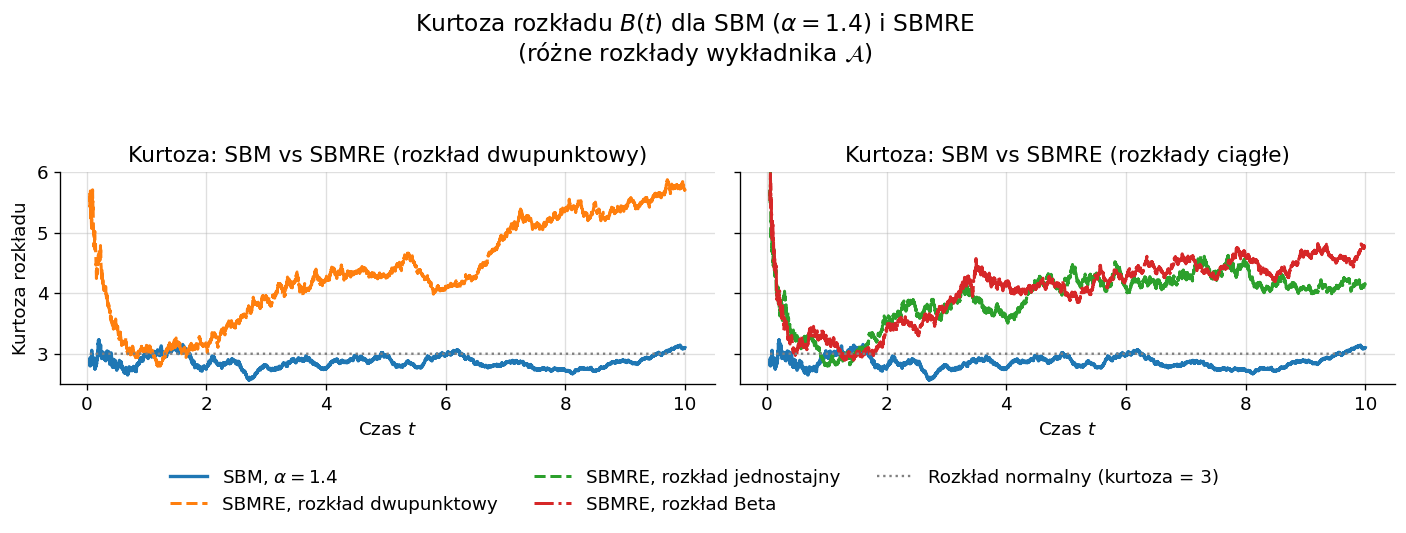

In [26]:
import matplotlib.pyplot as plt
import numpy as np

alpha_sbm = 1.4   # do tytułu

# Obcinamy bardzo wczesne czasy
t_min = 0.05
mask = t_grid >= t_min

t_plot = t_grid[mask]
k_sbm  = kurt_sbm[mask]
k_dw   = kurt_sbmre_dw[mask]
k_unif = kurt_sbmre_unif[mask]
k_beta = kurt_sbmre_beta[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# -------------------------------------------------
# Panel 1: SBM vs SBMRE (rozkład dwupunktowy)
# -------------------------------------------------
ax = axes[0]

line_sbm, = ax.plot(
    t_plot, k_sbm,
    color="C0", linewidth=2.0,
    label=rf"SBM, $\alpha={alpha_sbm}$"
)
line_dw, = ax.plot(
    t_plot, k_dw,
    color="C1", linestyle="--", linewidth=1.8,
    label="SBMRE, rozkład dwupunktowy"
)
line_gauss, = ax.plot(
    t_plot, 3.0 * np.ones_like(t_plot),
    color="gray", linestyle=":", linewidth=1.4,
    label="Rozkład normalny (kurtoza = 3)"
)

ax.set_title("Kurtoza: SBM vs SBMRE (rozkład dwupunktowy)")
ax.set_xlabel(r"Czas $t$")
ax.set_ylabel("Kurtoza rozkładu")
ax.grid(True, alpha=0.4)
ax.set_ylim(2.5, 6.0)        # sztucznie obcinamy do 6

# -------------------------------------------------
# Panel 2: SBM vs SBMRE (rozkłady ciągłe)
# -------------------------------------------------
ax = axes[1]

ax.plot(
    t_plot, k_sbm,
    color="C0", linewidth=2.0
)
line_unif, = ax.plot(
    t_plot, k_unif,
    color="C2", linestyle="--", linewidth=1.8,
    label="SBMRE, rozkład jednostajny"
)
line_beta, = ax.plot(
    t_plot, k_beta,
    color="C3", linestyle="-.", linewidth=1.8,
    label="SBMRE, rozkład Beta"
)
ax.plot(
    t_plot, 3.0 * np.ones_like(t_plot),
    color="gray", linestyle=":", linewidth=1.4
)

ax.set_title("Kurtoza: SBM vs SBMRE (rozkłady ciągłe)")
ax.set_xlabel(r"Czas $t$")
ax.grid(True, alpha=0.4)
ax.set_ylim(2.5, 6.0)

# -------------------------------------------------
# Wspólna legenda dla wszystkich linii
# -------------------------------------------------
fig.suptitle(
    rf"Kurtoza rozkładu $B(t)$ dla SBM ($\alpha = {alpha_sbm}$) i SBMRE"
    "\n(różne rozkłady wykładnika $\\mathcal{A}$)",
    fontsize=14
)

fig.legend(
    [line_sbm, line_dw, line_unif, line_beta, line_gauss],
    [
        rf"SBM, $\alpha={alpha_sbm}$",
        "SBMRE, rozkład dwupunktowy",
        "SBMRE, rozkład jednostajny",
        "SBMRE, rozkład Beta",
        "Rozkład normalny (kurtoza = 3)",
    ],
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1)
)

fig.tight_layout(rect=[0, 0.05, 1, 0.9])
plt.show()


c:\Users\User\miniconda3\Lib\site-packages\scipy\stats\_stats_py.py:1469: RuntimeWarning: invalid value encountered in divide
  nval = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)


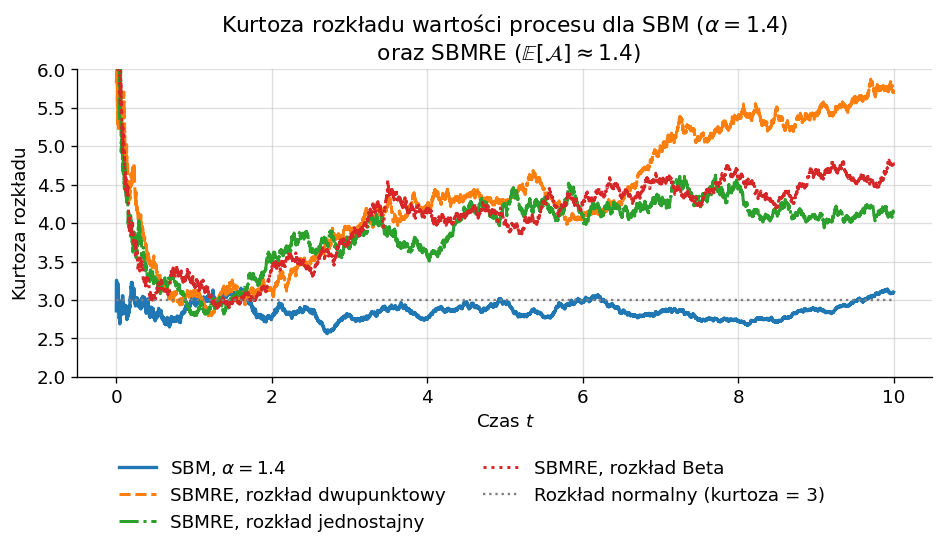

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

alpha_sbm = 1.4

# --------- funkcja: kurtoza w czasie dla danego zestawu trajektorii ---------
def time_kurtosis(X: np.ndarray) -> np.ndarray:
    """
    Kurtoza rozkładu B(t) w każdej chwili t.
    X: array (n_paths, n_points) – trajektorie w kolumnach czasu.
    Zwraca: wektor kurtozy o długości n_points.
    """
    # fisher=False -> kurtoza normalna = 3
    return kurtosis(X, axis=0, fisher=False, bias=False)

# kurtoza dla SBM
kurt_sbm = time_kurtosis(X_sbm)

# kurtozy dla SBMRE
kurt_sbmre = {}
for name in ["dwupunktowy", "jednostajny", "Beta"]:
    X_re = sbmre_results[name]["X"]
    kurt_sbmre[name] = time_kurtosis(X_re)

# żeby nie psuły skali, możemy lekko "przyciąć" wartości
def clip_kurt(k):
    return np.clip(k, 2.0, 6.0)   # wszystko poniżej 2 i powyżej 6 obcinamy

kurt_sbm_clip = clip_kurt(kurt_sbm)
kurt_dw_clip  = clip_kurt(kurt_sbmre["dwupunktowy"])
kurt_un_clip  = clip_kurt(kurt_sbmre["jednostajny"])
kurt_be_clip  = clip_kurt(kurt_sbmre["Beta"])

t = t_sbm

# pomijamy t=0 (tam czasem wychodzą brzydkie wartości numeryczne)
mask = t > 1e-3

fig, ax = plt.subplots(figsize=(8, 4.5))

# SBM
line_sbm, = ax.plot(
    t[mask], kurt_sbm_clip[mask],
    linewidth=2.0,
    label=rf"SBM, $\alpha = {alpha_sbm}$"
)

# SBMRE – różne rozkłady A (różne kolory / style)
line_dw, = ax.plot(
    t[mask], kurt_dw_clip[mask],
    linestyle="--",
    linewidth=1.8,
    label="SBMRE, rozkład dwupunktowy"
)

line_un, = ax.plot(
    t[mask], kurt_un_clip[mask],
    linestyle="-.",
    linewidth=1.8,
    label="SBMRE, rozkład jednostajny"
)

line_be, = ax.plot(
    t[mask], kurt_be_clip[mask],
    linestyle=":",
    linewidth=1.8,
    label="SBMRE, rozkład Beta"
)

# linia referencyjna – rozkład normalny (kurtoza = 3)
line_gauss, = ax.plot(
    t[mask],
    3.0 * np.ones_like(t[mask]),
    color="gray",
    linestyle=":",
    linewidth=1.4,
    label="Rozkład normalny (kurtoza = 3)"
)

ax.set_xlabel(r"Czas $t$")
ax.set_ylabel("Kurtoza rozkładu")
ax.set_title(
    rf"Kurtoza rozkładu wartości procesu dla SBM ($\alpha = {alpha_sbm}$)"
    "\n"
    r" oraz SBMRE ($\mathbb{E}[\mathcal{A}] \approx 1.4$)"
)

ax.grid(True, alpha=0.4)
ax.set_ylim(2.0, 6.0)  # zakres osi Y po przycięciu

# legenda pod wykresem
fig.legend(
    [line_sbm, line_dw, line_un, line_be, line_gauss],
    [
        rf"SBM, $\alpha={alpha_sbm}$",
        "SBMRE, rozkład dwupunktowy",
        "SBMRE, rozkład jednostajny",
        "SBMRE, rozkład Beta",
        "Rozkład normalny (kurtoza = 3)",
    ],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08)   # <-- było -0.22
)

fig.tight_layout(rect=[0, 0.10, 1, 0.95])  # <-- było [0, 0.18, 1, 0.95]
plt.show()




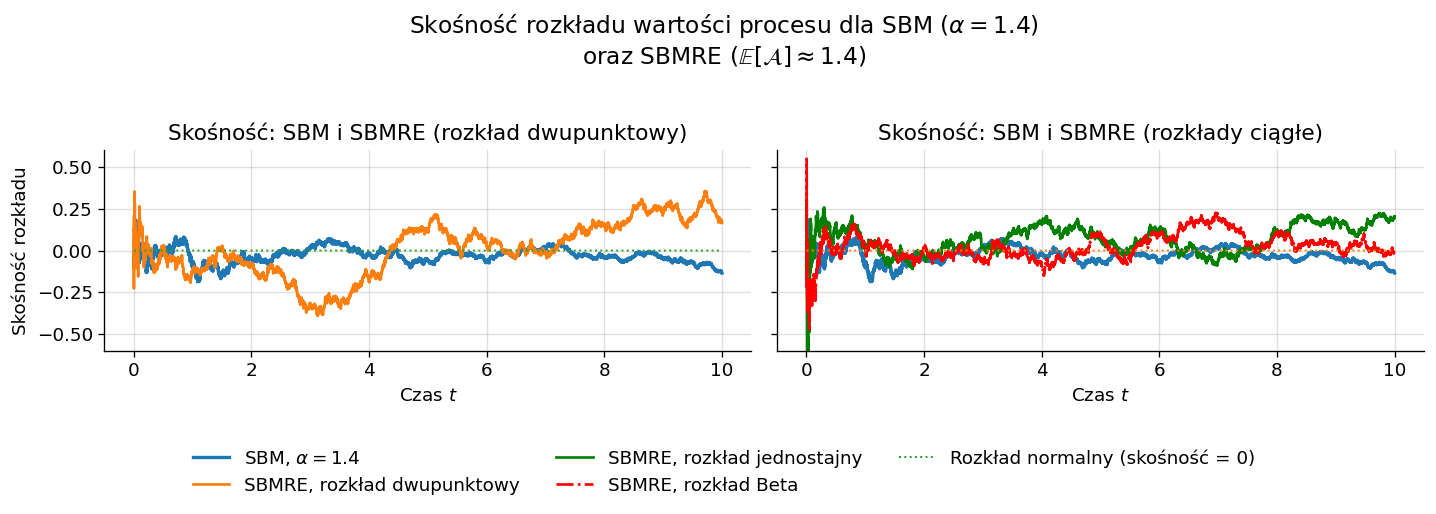

In [142]:
from scipy.stats import skew

alpha_sbm = 1.4

def time_skew(X: np.ndarray) -> np.ndarray:
    """Skośność rozkładu B(t) w każdej chwili t."""
    return skew(X, axis=0, bias=False)

# skośność dla SBM
skew_sbm = time_skew(X_sbm)

# skośności dla SBMRE
skew_sbmre_dw   = time_skew(sbmre_results["dwupunktowy"]["X"])
skew_sbmre_unif = time_skew(sbmre_results["jednostajny"]["X"])
skew_sbmre_beta = time_skew(sbmre_results["Beta"]["X"])

# --- maska wspólna dla wszystkich ---
t = t_sbm
mask = t > 1e-3          # pomijamy t≈0
t_plot = t[mask]

s_sbm  = skew_sbm[mask]
s_dw   = skew_sbmre_dw[mask]
s_unif = skew_sbmre_unif[mask]
s_beta = skew_sbmre_beta[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# --- panel 1: SBM vs SBMRE dwupunktowy ---
ax = axes[0]
line_sbm, = ax.plot(t_plot, s_sbm, linewidth=2.0)
line_dw,  = ax.plot(t_plot, s_dw,  linestyle="-", linewidth=1.6)
line_zero, = ax.plot(t_plot, np.zeros_like(t_plot),
                     linestyle=":", linewidth=1.2)

ax.set_title("Skośność: SBM i SBMRE (rozkład dwupunktowy)")
ax.set_xlabel(r"Czas $t$")
ax.set_ylabel("Skośność rozkładu")
ax.grid(True, alpha=0.4)
ax.set_ylim(-0.6, 0.6)

# --- panel 2: SBM vs SBMRE rozkłady ciągłe ---
ax = axes[1]
line_sbm2,  = ax.plot(t_plot, s_sbm,  linewidth=2.0)
line_unif,  = ax.plot(t_plot, s_unif, linestyle="-", linewidth=1.6, c="green")
line_beta,  = ax.plot(t_plot, s_beta, linestyle="-.", linewidth=1.6, c="red")
ax.plot(t_plot, np.zeros_like(t_plot),
        linestyle=":", linewidth=1.2)

ax.set_title("Skośność: SBM i SBMRE (rozkłady ciągłe)")
ax.set_xlabel(r"Czas $t$")
ax.grid(True, alpha=0.4)
ax.set_ylim(-0.6, 0.6)

fig.suptitle(
    rf"Skośność rozkładu wartości procesu dla SBM ($\alpha = {alpha_sbm}$)"
    "\n"
    r"oraz SBMRE ($\mathbb{E}[\mathcal{A}] \approx 1.4$)",
    fontsize=14,
    y=0.96,   # trochę niżej
)

fig.legend(
    [line_sbm, line_dw, line_unif, line_beta, line_zero],
    [
        rf"SBM, $\alpha={alpha_sbm}$",
        "SBMRE, rozkład dwupunktowy",
        "SBMRE, rozkład jednostajny",
        "SBMRE, rozkład Beta",
        "Rozkład normalny (skośność = 0)",
    ],
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

fig.tight_layout(rect=[0, 0.10, 1, 0.93])
plt.show()


Generowanie wykresów p-value...


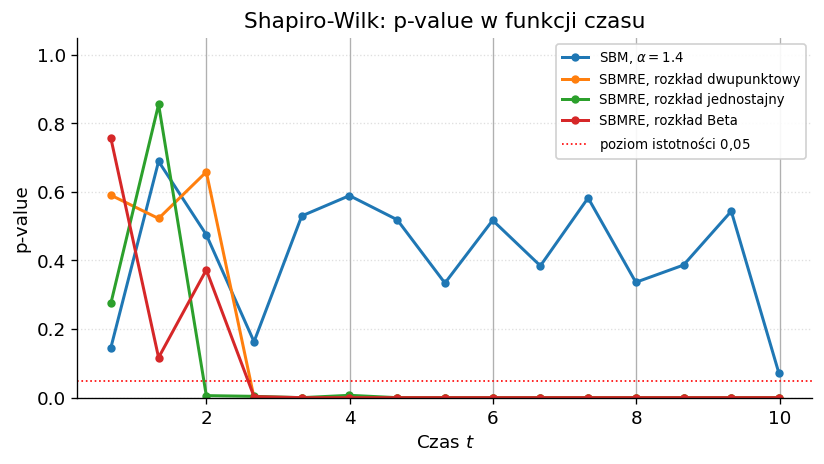

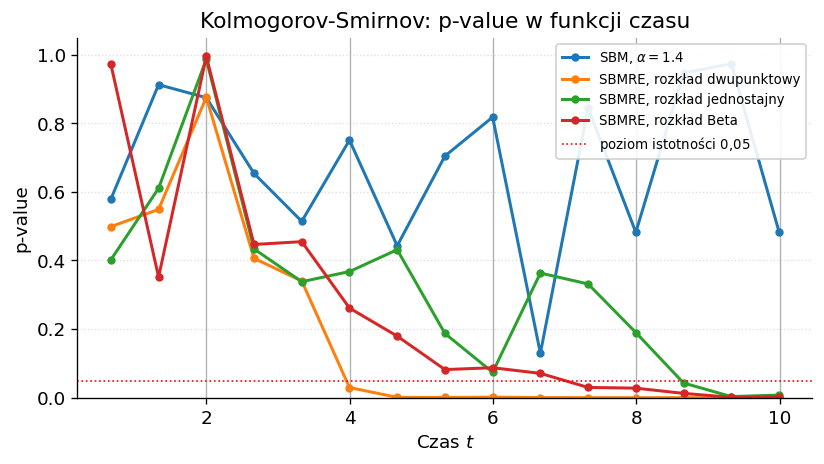

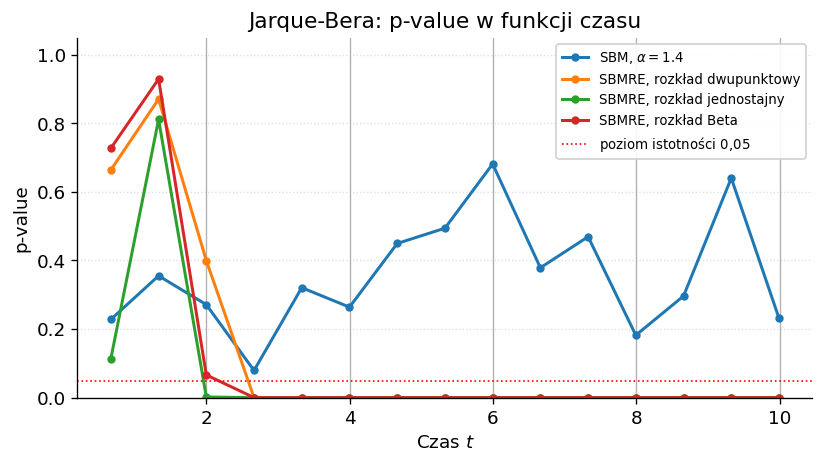

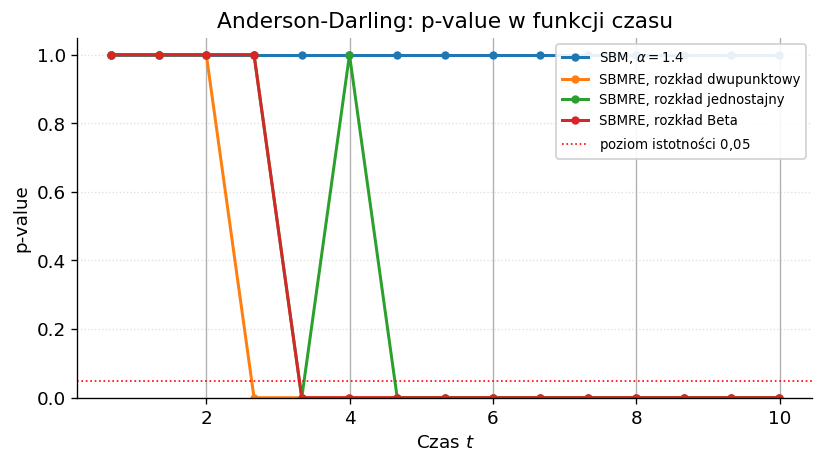

Generowanie wykresów statystyk testowych...


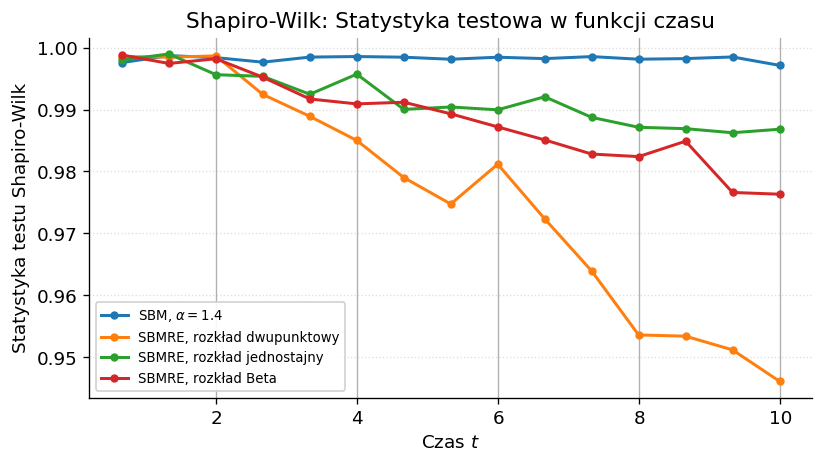

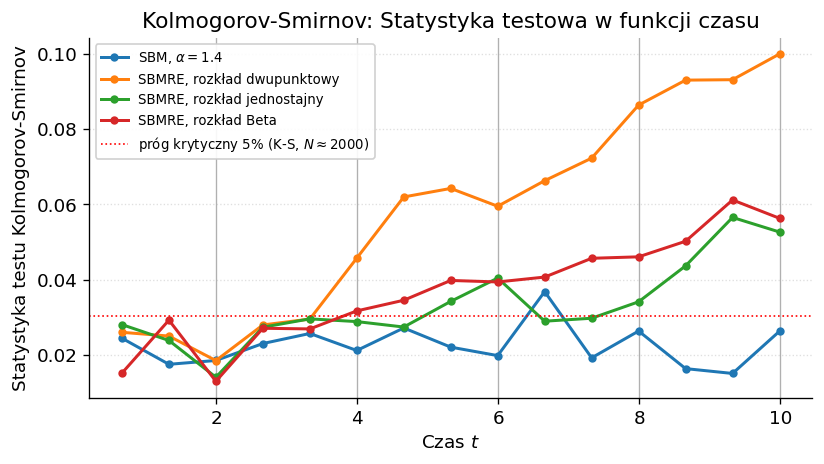

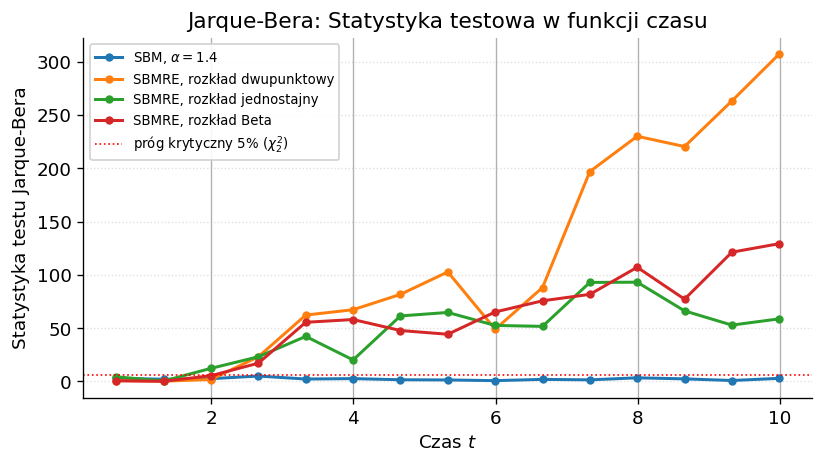

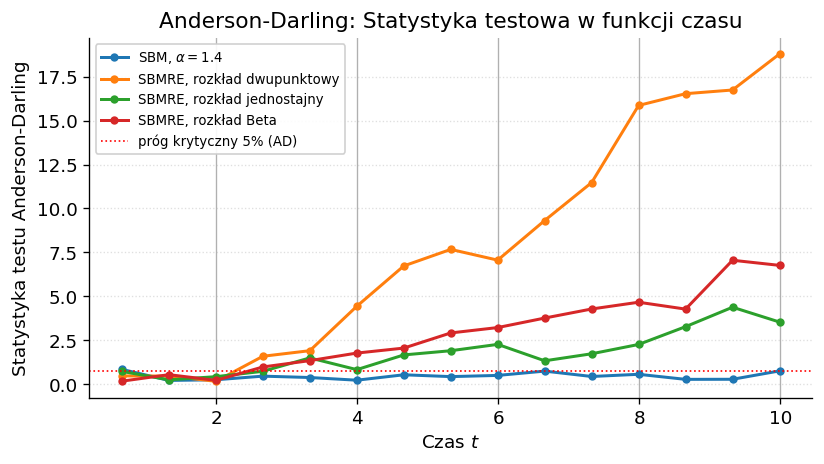

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kstest, jarque_bera, anderson
from scipy.interpolate import interp1d

alpha_sbm = 1.4

# Przybliżenie p-value dla testu Andersona–Darlinga
def approx_anderson_darling_p_value(statistic: float, critical_values: np.ndarray, significance_levels: np.ndarray) -> float:
    """
    Przybliża p-value dla testu Andersona–Darlinga na podstawie statystyki
    testowej i znanych wartości krytycznych/poziomów istotności SciPy.
    """
    
    # 1. Sprawdzamy, czy statystyka jest poza zakresem
    # critical_values są dla alpha: [15%, 10%, 5%, 2.5%, 1%]
    # Im mniejsza statystyka, tym większe p-value (mniejsze niż 15%)
    if statistic < critical_values[-1]:
        return 1.0 # Statystyka jest mniejsza niż próg dla 15%, więc p-value > 0.15
    
    # Im większa statystyka, tym mniejsze p-value (mniejsze niż 1%)
    if statistic > critical_values[0]:
        return 0.0 # Statystyka jest większa niż próg dla 1%, więc p-value < 0.01

    # 2. Interpolacja liniowa
    # Prawidłowe dla interpolacji (X - rosnąco, Y - malejąco)
    # X_interp: wartości krytyczne (rosnąco, v_15% do v_1%)
    # Y_interp: odpowiadające p-value (malejąco, 0.15 do 0.01)
    
    # SciPy zwraca:
    # critical_values: [v_1%, v_2.5%, v_5%, v_10%, v_15%] (MALEJĄCE wartości krytyczne)
    # significance_level: [1.0, 2.5, 5.0, 10.0, 15.0] (MALEJĄCE poziomy istotności w %)
    
    # Odwracamy kolejność, aby X (wartości krytyczne) były ROSNĄCE.
    x_crit_sorted = np.flip(critical_values) # [v_15%, v_10%, v_5%, v_2.5%, v_1%] -> [v_1%, v_2.5%, v_5%, v_10%, v_15%]
    y_pvals_sorted = np.flip(significance_levels) / 100.0 # [1.0 -> 15.0]% -> [0.01 -> 0.15]
    
    # x: [0.509, 0.573, 0.658, 0.778, 1.066] (Rosnące wartości krytyczne)
    # y: [0.15, 0.10, 0.05, 0.025, 0.01] (Malejące p-value - to źle!)
    
    # Poprawne mapowanie dla SciPy:
    # SciPy: critical_values: [1.066, 0.778, 0.658, 0.573, 0.509]
    # Odwracamy: [0.509, 0.573, 0.658, 0.778, 1.066] (Rosnące - X)
    # p-value: [0.15, 0.10, 0.05, 0.025, 0.01] (Malejące - Y)
    
    f_interp = interp1d(x_crit_sorted, y_pvals_sorted, kind='linear')
    
    return f_interp(statistic).item()

# -------------------------------------------------------
# 1. Funkcja: testy normalności dla jednej próbki (zmodyfikowana)
# -------------------------------------------------------

def run_normality_tests(samples: np.ndarray, max_n: int = 2000, seed: int = 123):
    """
    Zwraca p-value oraz statystyki testowe dla 4 testów normalności.
    """
    samples = np.asarray(samples, dtype=float)

    # podpróbkowanie
    if samples.size > max_n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(samples.size, size=max_n, replace=False)
        samples = samples[idx]

    # standaryzacja do ~N(0,1)
    m = samples.mean()
    s = samples.std(ddof=1)
    if s == 0:
        return {
            "Shapiro-Wilk_p": np.nan, "Shapiro-Wilk_stat": np.nan,
            "Kolmogorov-Smirnov_p": np.nan, "Kolmogorov-Smirnov_stat": np.nan,
            "Jarque-Bera_p": np.nan, "Jarque-Bera_stat": np.nan,
            "Anderson-Darling_p": np.nan, "Anderson-Darling_stat": np.nan,
            "AD_crit_5": np.nan,
        }

    z = (samples - m) / s

    res = {}

    # Shapiro-Wilk
    stat, p = shapiro(z)
    res["Shapiro-Wilk_p"] = p
    res["Shapiro-Wilk_stat"] = stat

    # Kolmogorov-Smirnov
    stat, p = kstest(z, "norm")
    res["Kolmogorov-Smirnov_p"] = p
    res["Kolmogorov-Smirnov_stat"] = stat

    # Jarque-Bera
    stat, p = jarque_bera(z)
    res["Jarque-Bera_p"] = p
    res["Jarque-Bera_stat"] = stat

    # Anderson–Darling
    AD = anderson(z, dist="norm")
    res["Anderson-Darling_stat"] = AD.statistic
    res["AD_crit_5"] = AD.critical_values[2] # 5%
    
    try:
        p_ad = approx_anderson_darling_p_value(AD.statistic, AD.critical_values, AD.significance_level)
    except ValueError:
        p_ad = 0.0 if AD.statistic > AD.critical_values[0] else 1.0
        
    res["Anderson-Darling_p"] = p_ad

    return res


# -------------------------------------------------------
# 2. Dane procesów: SBM + SBMRE
# -------------------------------------------------------

# UWAGA: Wymagane są zmienne X_sbm, sbmre_results, t_sbm.
# Przyjmuję, że są one zdefiniowane w Twoim środowisku.

process_names = [
    r"SBM, $\alpha = 1.4$",
    "SBMRE, rozkład dwupunktowy",
    "SBMRE, rozkład jednostajny",
    "SBMRE, rozkład Beta",
]

process_data = [
    X_sbm,
    sbmre_results["dwupunktowy"]["X"],
    sbmre_results["jednostajny"]["X"],
    sbmre_results["Beta"]["X"],
]

test_names = [
    "Shapiro-Wilk",
    "Kolmogorov-Smirnov",
    "Jarque-Bera",
    "Anderson-Darling",
]

t = t_sbm

# -------------------------------------------------------
# 3. Wybór chwil czasu
# -------------------------------------------------------

points_per_curve = 15           # ~liczba punktów czasowych na wykresie
step_raw = max(1, len(t) // points_per_curve)
idx_times = np.arange(1, len(t), step_raw)
t_grid = t[idx_times]

n_tests = len(test_names)
n_proc    = len(process_names)
n_times   = len(t_grid)

# pvals[test, process, time]
pvals = np.zeros((n_tests, n_proc, n_times))
# stats[test, process, time]
stats = np.zeros((n_tests, n_proc, n_times))
# Progi krytyczne dla testów, które je mają (AD, ale uzyjemy tylko dla AD)
crit_vals = {
    "Shapiro-Wilk": np.nan, 
    "Kolmogorov-Smirnov": np.nan, # Brak prostego, stałego progu (zależny od n)
    "Jarque-Bera": 5.991, # Próg dla alpha=0.05, df=2
    "Anderson-Darling": None, # Pobierany dynamicznie
}


# -------------------------------------------------------
# 4. Liczenie p-value i statystyk
# -------------------------------------------------------

for kt, idx in enumerate(idx_times):
    for ip, X in enumerate(process_data):
        samples_t = X[:, idx]
        res = run_normality_tests(samples_t, max_n=2000, seed=123 + kt + 10*ip) 

        for jt, tname in enumerate(test_names):
            # Zapis p-value
            pvals[jt, ip, kt] = res[f"{tname}_p"]
            # Zapis statystyki
            stats[jt, ip, kt] = res[f"{tname}_stat"]
            
            # Zapis progu krytycznego AD
            if tname == "Anderson-Darling" and crit_vals["Anderson-Darling"] is None and not np.isnan(res["AD_crit_5"]):
                 crit_vals["Anderson-Darling"] = res["AD_crit_5"]

# Jeśli z jakiegoś powodu nie udało się ustalić progu AD
if crit_vals["Anderson-Darling"] is None:
    crit_vals["Anderson-Darling"] = np.nan


# -------------------------------------------------------
# 5. Wykresy p-value dla wszystkich testów
# -------------------------------------------------------

print("Generowanie wykresów p-value...")
alpha_level = 0.05  # poziom istotności dla p-value

for jt, tname in enumerate(test_names):
    fig, ax = plt.subplots(figsize=(7, 4))

    for ip, pname in enumerate(process_names):
        ax.plot(
            t_grid,
            pvals[jt, ip, :],
            linewidth=1.8,
            marker="o",
            markersize=4,
            label=pname,
        )

    # poziom istotności
    ax.axhline(alpha_level,
               color="red", linestyle=":", linewidth=1.0,
               label=r"poziom istotności $0{,}05$")

    ax.set_xlabel(r"Czas $t$")
    ax.set_ylabel("p-value")
    ax.set_title(f"{tname}: p-value w funkcji czasu")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right")
    fig.tight_layout()

    fname = "pvalues_" + tname.lower().replace(" ", "_").replace("–", "_") + ".png"
    plt.savefig(fname, dpi=300)
    plt.show()

# -------------------------------------------------------
# 6. Wykresy statystyk testowych dla wszystkich testów
# -------------------------------------------------------

print("Generowanie wykresów statystyk testowych...")

# Dodatkowe informacje o progu krytycznym dla Shapiro-Wilka:
# Wartość krytyczna zależy od N, ale dla N=2000 (max_n) i alpha=0.05 
# jest bliska 0.998. Zostawiamy NaN dla czystej statystyki.
# Dla K-S, próg zależy od N: ~1.36/sqrt(N). Dla N=2000, próg to ~0.03.

for jt, tname in enumerate(test_names):
    fig, ax = plt.subplots(figsize=(7, 4))

    for ip, pname in enumerate(process_names):
        ax.plot(
            t_grid,
            stats[jt, ip, :],
            linewidth=1.8,
            marker="o",
            markersize=4,
            label=pname,
        )

    # Rysowanie progu krytycznego, jeśli jest stały/łatwo dostępny
    crit_val = crit_vals[tname]
    
    # Próg krytyczny dla Anderson-Darlinga (5%):
    if tname == "Anderson-Darling" and not np.isnan(crit_val):
        ax.axhline(
            crit_val,
            color="red",
            linestyle=":",
            linewidth=1.0,
            label=r"próg krytyczny 5% (AD)"
        )
    # Próg krytyczny dla Jarque-Bera (5%, df=2):
    elif tname == "Jarque-Bera" and not np.isnan(crit_val):
        ax.axhline(
            crit_val,
            color="red",
            linestyle=":",
            linewidth=1.0,
            label=r"próg krytyczny 5% ($\chi^2_2$)"
        )
    # Próg krytyczny dla Kołmogorowa-Smirnowa (dla N=2000):
    elif tname == "Kolmogorov-Smirnov":
         # Próg K-S (Lilliefors, przy standaryzacji, ale używamy 'norm'): 1.36 / sqrt(N)
         N_max = 2000
         KS_crit = 1.36 / np.sqrt(N_max)
         ax.axhline(
            KS_crit,
            color="red",
            linestyle=":",
            linewidth=1.0,
            label=r"próg krytyczny 5% (K-S, $N\approx 2000$)"
        )

    ax.set_xlabel(r"Czas $t$")
    ax.set_ylabel(f"Statystyka testu {tname}")
    ax.set_title(f"{tname}: Statystyka testowa w funkcji czasu")
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()

    fname = "stats_" + tname.lower().replace(" ", "_").replace("–", "_") + ".png"
    plt.savefig(fname, dpi=300)
    plt.show()

# Ostatni wykres ze statystyką AD jest teraz generowany w pętli.
# W sekcji 6.

### Rozdział 3

#### Wpływ długości trajektorii

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# -----------------------
# Pomocnicze: MSD, TAMSD, kurtoza
# -----------------------

def compute_msd_curve(X):
    """MSD(t) ≈ mean_i X_i(t)^2, średnia po trajektoriach."""
    return np.mean(X**2, axis=0)

def compute_tamsd_per_path(X, m):
    """
    TAMSD dla jednego laga m (w krokach dt), liczona osobno dla każdej trajektorii.
    X: (n_paths, N+1)
    Zwraca: (n_paths,)
    """
    if m <= 0:
        raise ValueError("Lag m musi być >= 1.")
    if m >= X.shape[1]:
        raise ValueError("Lag m jest za duży względem długości trajektorii.")
    diffs = X[:, m:] - X[:, :-m]
    return np.mean(diffs**2, axis=1)

def compute_kurtosis_curve(X, fisher=False):
    """
    Kurtoza po trajektoriach w kolejnych czasach.
    fisher=False -> kurtoza klasyczna (normalny ~ 3).
    """
    # kurtosis liczymy wzdłuż osi 0 (po trajektoriach)
    return kurtosis(X, axis=0, fisher=fisher, bias=False)

def downsample(arr, step):
    """Downsampling do wykresów (żeby było szybciej i czytelniej)."""
    return arr[::step]


In [144]:
# -----------------------
# Parametry "domyślne" tej sekcji
# -----------------------
alpha_sbm = 1.4
A1, A2 = 0.8, 2.0  # E=1.4 dla dwupunktowego i jednostajnego
dt = 1e-3

T_list = [1, 5, 10]          # długości trajektorii do porównania
n_paths = 1000             # jeśli wolno -> zmniejsz np. do 2000 na czas testów

# Lags τ do TAMSD (w sekundach) -> zamienimy na m=τ/dt
tau_list = [0.05, 0.1, 0.5]  # dobierz pod siebie; ważne by tau << T
m_list = [int(round(tau/dt)) for tau in tau_list]

# Wybór losowości w SBMRE (trzymamy stałe w tej sekcji!)
# 1) dwupunktowy: E=1.4 jeśli A1=0.8, A2=2.0, p=0.5
def alpha_sampler_sbmre_two_point(n, rng):
    return sample_alpha_two_point(n, rng, A1=A1, A2=A2, p=0.5)

# Alternatywnie możesz odkomentować uniform lub beta:
def alpha_sampler_sbmre_uniform(n, rng):
    return sample_alpha_uniform_segment(n, rng, A1=A1, A2=A2)

def alpha_sampler_sbmre_beta(n, rng):
    return sample_alpha_beta_segment(n, rng, A1=A1, A2=A2, gamma=0.5, beta=0.5)

seed_base = 123

A1, A2 = 0.8, 2.0  # zakres dla uniform/beta, wartości dla dwupunktowego

samplers = {
    "SBMRE: dwupunktowy": lambda n, rng: sample_alpha_two_point(n, rng, A1=A1, A2=A2, p=0.5),
    "SBMRE: jednostajny": lambda n, rng: sample_alpha_uniform_segment(n, rng, A1=A1, A2=A2),
    "SBMRE: beta (a=b=0.5)": lambda n, rng: sample_alpha_beta_segment(n, rng, A1=A1, A2=A2, gamma=0.5, beta=0.5),
}



In [145]:
results = {}  # results[T] -> dict z SBM i SBMRE (3 warianty)

for idx, T in enumerate(T_list):
    print(f"== T = {T} ==")

    # --- SBM (jeden) ---
    rng_sbm = np.random.default_rng(seed_base + 1000 + idx)
    t_sbm, X_sbm = simulate_sbm(alpha_sbm, T, dt, n_paths, rng_sbm)

    out = {
        "t": t_sbm,
        "SBM": {
            "X": X_sbm,
            "msd": compute_msd_curve(X_sbm),
            "kurt": compute_kurtosis_curve(X_sbm, fisher=False),
            "tamsd": {tau: compute_tamsd_per_path(X_sbm, m) for tau, m in zip(tau_list, m_list)}
        }
    }

    # --- SBMRE (3 warianty) ---
    for j, (label, sampler) in enumerate(samplers.items()):
        seed = seed_base + 2000 + 10*idx + j
        t_re, X_re, A_re = simulate_sbmre(T=T, dt=dt, n_paths=n_paths, seed=seed, alpha_sampler=sampler)

        out[label] = {
            "X": X_re,
            "msd": compute_msd_curve(X_re),
            "kurt": compute_kurtosis_curve(X_re, fisher=False),
            "tamsd": {tau: compute_tamsd_per_path(X_re, m) for tau, m in zip(tau_list, m_list)}
        }

    results[T] = out


== T = 1 ==


c:\Users\User\miniconda3\Lib\site-packages\scipy\stats\_stats_py.py:1469: RuntimeWarning: invalid value encountered in divide
  nval = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)


== T = 5 ==
== T = 10 ==


In [33]:
# tau_ref = tau_list[0]

# plt.figure(figsize=(10,4))
# data, labels = [], []

# for T in T_list:
#     data.append(results[T]["SBM"]["tamsd"][tau_ref])
#     labels.append(f"SBM, T={T}")

#     for label in samplers.keys():
#         data.append(results[T][label]["tamsd"][tau_ref])
#         labels.append(f"{label}, T={T}")

# plt.boxplot(data, labels=labels, showfliers=False)
# plt.title(f"TAMSD (tau={tau_ref}) — wpływ długości trajektorii i typu losowości")
# plt.ylabel("TAMSD")
# plt.xticks(rotation=35, ha="right")
# plt.grid(True, axis="y", alpha=0.3)
# plt.tight_layout()
# plt.show()


In [34]:
# import matplotlib.pyplot as plt

# tau_ref = tau_list[0]  # np. 0.05

# # krótsze nazwy do osi X
# short_names = {
#     "SBM": "SBM",
#     "SBMRE: dwupunktowy": "SBMRE: 2pkt",
#     "SBMRE: jednostajny": "SBMRE: U",
#     "SBMRE: beta (a=b=0.5)": "SBMRE: beta",
# }

# T_show = [1, 5, 10]  # albo T_list, jeśli masz inne

# fig, axes = plt.subplots(1, len(T_show), figsize=(5*len(T_show), 4), sharey=True)
# if len(T_show) == 1:
#     axes = [axes]

# for ax, T in zip(axes, T_show):
#     data = [
#         results[T]["SBM"]["tamsd"][tau_ref],
#         results[T]["SBMRE: dwupunktowy"]["tamsd"][tau_ref],
#         results[T]["SBMRE: jednostajny"]["tamsd"][tau_ref],
#         results[T]["SBMRE: beta (a=b=0.5)"]["tamsd"][tau_ref],
#     ]
#     labels = [
#         short_names["SBM"],
#         short_names["SBMRE: dwupunktowy"],
#         short_names["SBMRE: jednostajny"],
#         short_names["SBMRE: beta (a=b=0.5)"],
#     ]

#     ax.boxplot(data, labels=labels, showfliers=False)
#     ax.set_title(f"TAMSD (τ={tau_ref}), T={T}")
#     ax.set_xlabel("Model")
#     ax.grid(True, axis="y", alpha=0.3)

# axes[0].set_ylabel("TAMSD")
# plt.tight_layout()
# plt.show()


In [35]:
# import matplotlib.pyplot as plt

# tau_ref = tau_list[0]          # np. 0.05
# T_show  = [1, 5, 10]           # długości trajektorii do porównania

# # krótsze etykiety na osi X (jak na screenie)
# labels = ["SBM", "SBMRE,\nrozkład dwupunktowy", "SBMRE,\nrozkład jednostajny", "SBMRE,\nrozkład Beta"]

# # kolejność serii (spójna dla każdego T)
# keys = ["SBM", "SBMRE: dwupunktowy", "SBMRE: jednostajny", "SBMRE: beta (a=b=0.5)"]

# # --- figura ---
# fig, axes = plt.subplots(1, len(T_show), figsize=(5.4*len(T_show), 4.2), sharey=True)
# if len(T_show) == 1:
#     axes = [axes]

# for ax, T in zip(axes, T_show):
#     data = [results[T][k]["tamsd"][tau_ref] for k in keys]

#     ax.boxplot(
#         data,
#         labels=labels,
#         showfliers=False,
#         widths=0.55,
#         medianprops=dict(linewidth=1.8),
#         boxprops=dict(linewidth=1.3),
#         whiskerprops=dict(linewidth=1.2),
#         capprops=dict(linewidth=1.2),
#     )

#     # mały tytuł tylko z T (jak chciałaś)
#     ax.set_title(f"T = {T}", fontsize=12, pad=6)

#     # siatka jak na screenie (delikatna)
#     ax.grid(True, axis="y", alpha=0.35)

#     # obrót etykiet (żeby były czytelne)
#     ax.tick_params(axis="x", labelrotation=0)

# # oś Y jak na screenie
# axes[0].set_ylabel(r"Czasowo uśredniony kwadrat przesunięcia $\overline{\delta^2(\tau)}$")

# # wspólny tytuł całej figury (duży)
# fig.suptitle(
#     rf"Rozkład wartości TAMSD dla $\tau = {tau_ref}$" + "\n" +
#     r"SBM ($\alpha = 1.4$) i SBMRE ($\mathbb{E}[\mathcal{A}] \approx 1.4$)",
#     fontsize=14, y=1.05
# )

# plt.tight_layout()
# plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_1180\4241776249.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\4241776249.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\4241776249.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


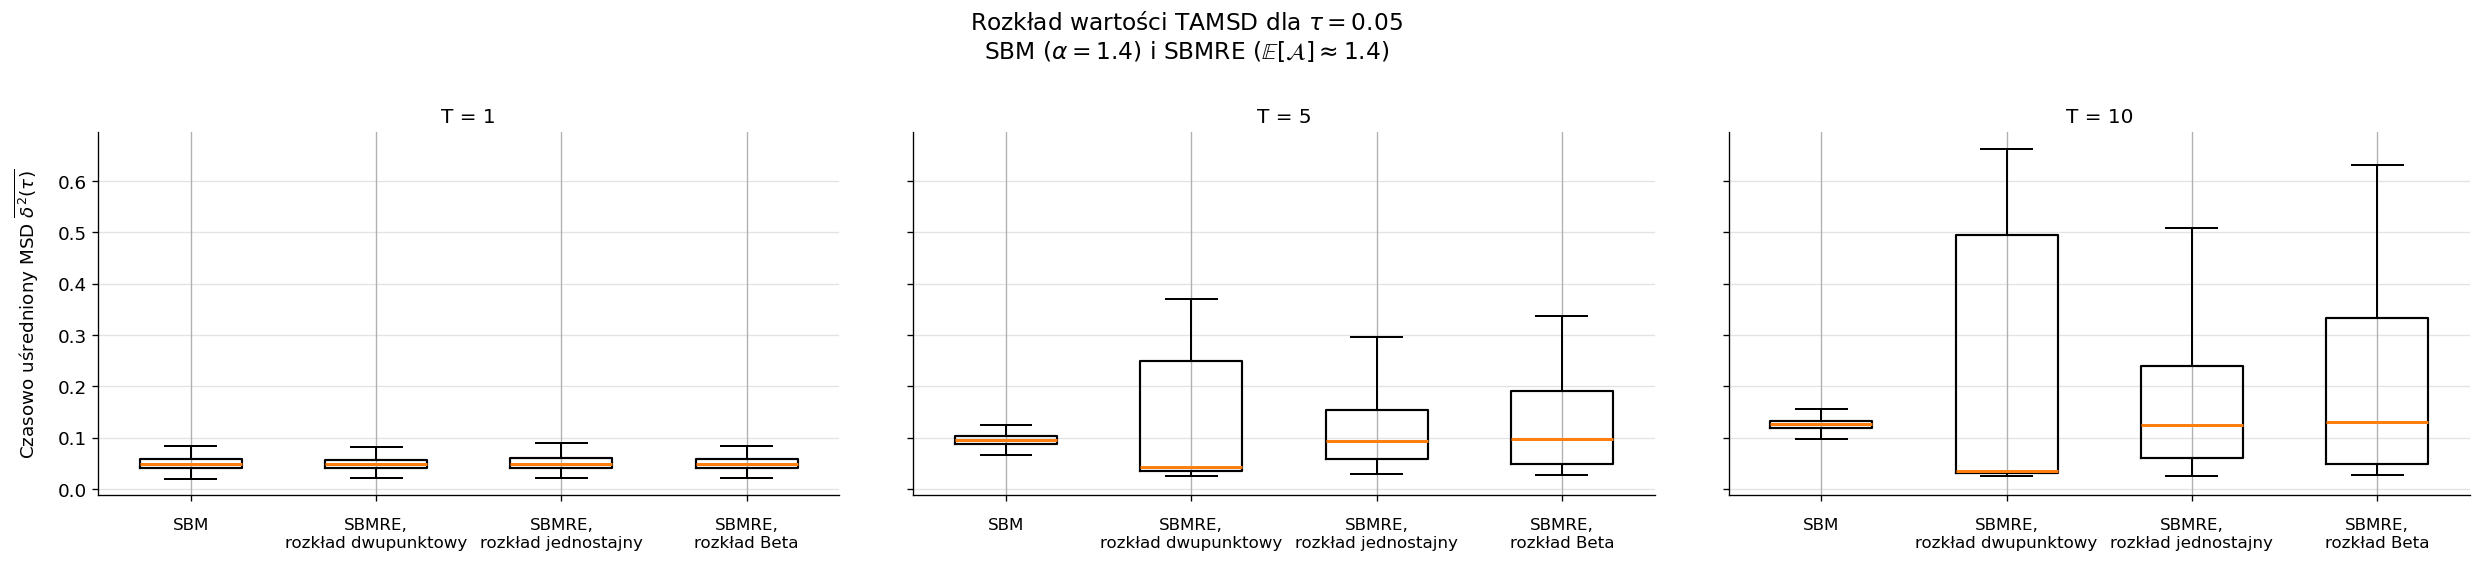

In [146]:
import matplotlib.pyplot as plt

tau_ref = tau_list[0]
T_show  = [1, 5, 10]

labels = [
    "SBM",
    "SBMRE,\nrozkład dwupunktowy",
    "SBMRE,\nrozkład jednostajny",
    "SBMRE,\nrozkład Beta"
]
keys = ["SBM", "SBMRE: dwupunktowy", "SBMRE: jednostajny", "SBMRE: beta (a=b=0.5)"]

# --- figura: większa (szczególnie wysokość) ---
fig, axes = plt.subplots(1, len(T_show), figsize=(7.2*len(T_show), 5.6), sharey=True)

for ax, T in zip(axes, T_show):
    data = [results[T][k]["tamsd"][tau_ref] for k in keys]

    ax.boxplot(
        data,
        labels=labels,
        showfliers=False,
        widths=0.55,
        medianprops=dict(linewidth=1.8),
        boxprops=dict(linewidth=1.3),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )

    ax.set_title(f"T = {T}", fontsize=12, pad=6)
    ax.grid(True, axis="y", alpha=0.35)

    # klucz: mniejsza czcionka + trochę odstępu
    ax.tick_params(axis="x", labelsize=10, pad=10)

# oś Y
axes[0].set_ylabel(r"Czasowo uśredniony MSD $\overline{\delta^2(\tau)}$", labelpad=10)

# wspólny tytuł (wyżej, żeby nie ścinało)
fig.suptitle(
    rf"Rozkład wartości TAMSD dla $\tau = {tau_ref}$" + "\n" +
    r"SBM ($\alpha = 1.4$) i SBMRE ($\mathbb{E}[\mathcal{A}] \approx 1.4$)",
    fontsize=14
)

# ręczne marginesy: więcej miejsca na tytuł i etykiety X + nie ucina Y
fig.subplots_adjust(left=0.08, right=0.995, bottom=0.26, top=0.80, wspace=0.10)

plt.show()


In [37]:
def cv(x):
    x = np.asarray(x)
    return np.std(x, ddof=1) / np.mean(x)

tau_ref = tau_list[0]
T_min, T_max = min(T_list), max(T_list)

print(f"=== CV(TAMSD) dla tau={tau_ref} ===")
labels_all = ["SBM"] + list(samplers.keys())

for label in labels_all:
    cv_min = cv(results[T_min][label]["tamsd"][tau_ref])
    cv_max = cv(results[T_max][label]["tamsd"][tau_ref])
    drop = (cv_min - cv_max) / cv_min * 100
    print(f"{label:25s}: CV(T={T_min})={cv_min:.4f}, CV(T={T_max})={cv_max:.4f}, spadek={drop:.1f}%")


=== CV(TAMSD) dla tau=0.05 ===
SBM                      : CV(T=1)=0.2702, CV(T=10)=0.0862, spadek=68.1%
SBMRE: dwupunktowy       : CV(T=1)=0.2571, CV(T=10)=0.9404, spadek=-265.7%
SBMRE: jednostajny       : CV(T=1)=0.2854, CV(T=10)=0.7601, spadek=-166.3%
SBMRE: beta (a=b=0.5)    : CV(T=1)=0.2821, CV(T=10)=0.8413, spadek=-198.2%


In [147]:
# --- zakres z alpha0 i eps ---
alpha0 = 1.4
eps = 0.6
A1, A2 = alpha0 - eps, alpha0 + eps  # [0.8, 2.0]

def make_two_point_sampler(alpha0, eps, p=0.5):
    A1, A2 = alpha0 - eps, alpha0 + eps
    def sampler(n, rng):
        return sample_alpha_two_point(n, rng, A1=A1, A2=A2, p=p)
    return sampler

def make_uniform_sampler(alpha0, eps):
    A1, A2 = alpha0 - eps, alpha0 + eps
    def sampler(n, rng):
        return sample_alpha_uniform_segment(n, rng, A1=A1, A2=A2)
    return sampler

def make_beta_sampler(alpha0, eps, a=0.5, b=0.5):
    A1, A2 = alpha0 - eps, alpha0 + eps
    def sampler(n, rng):
        return sample_alpha_beta_segment(n, rng, A1=A1, A2=A2, gamma=a, beta=b)
    return sampler

samplers = {
    "SBMRE: 2pkt": make_two_point_sampler(alpha0, eps, p=0.5),
    "SBMRE: U":    make_uniform_sampler(alpha0, eps),
    "SBMRE: Beta": make_beta_sampler(alpha0, eps, a=0.5, b=0.5),
}


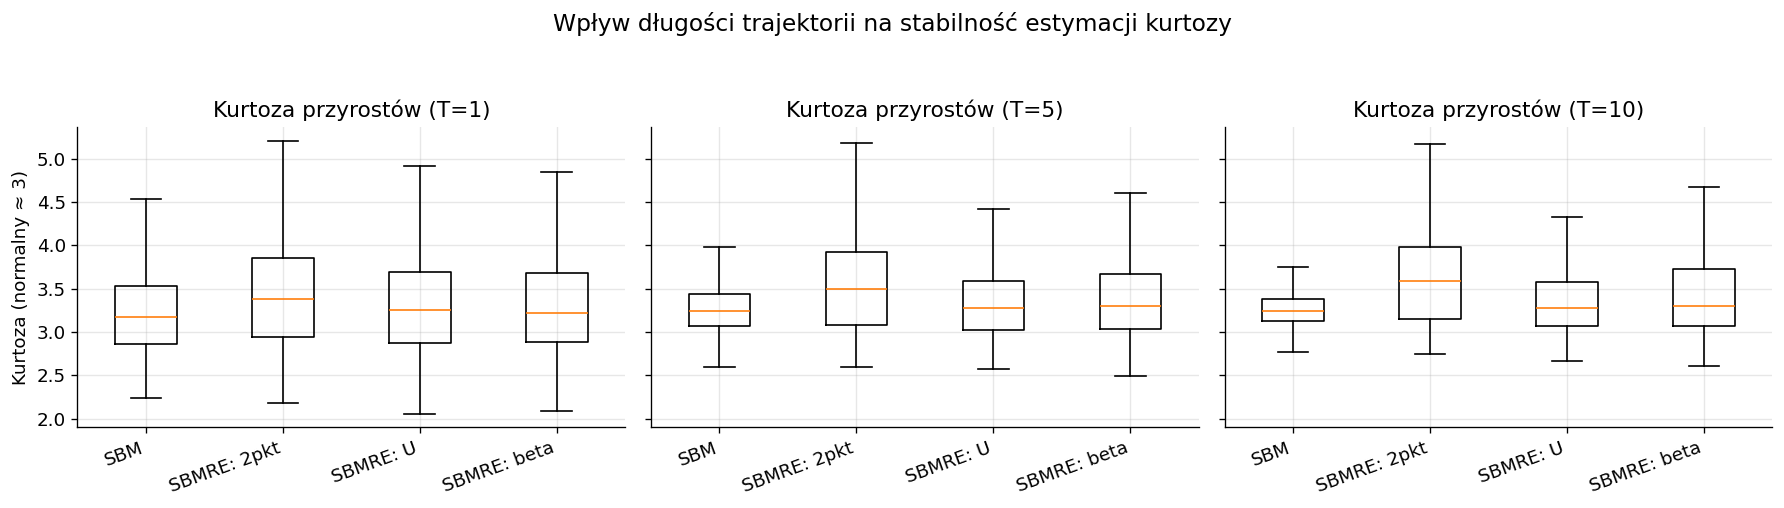

Mediana kurtozy (IQR) dla przyrostów:

T = 1
SBM         : 3.177  (IQR=0.674)
SBMRE: 2pkt : 3.375  (IQR=0.917)
SBMRE: U    : 3.251  (IQR=0.822)
SBMRE: beta : 3.223  (IQR=0.796)

T = 5
SBM         : 3.241  (IQR=0.369)
SBMRE: 2pkt : 3.497  (IQR=0.840)
SBMRE: U    : 3.272  (IQR=0.568)
SBMRE: beta : 3.300  (IQR=0.631)

T = 10
SBM         : 3.238  (IQR=0.260)
SBMRE: 2pkt : 3.593  (IQR=0.826)
SBMRE: U    : 3.274  (IQR=0.516)
SBMRE: beta : 3.304  (IQR=0.651)


In [148]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# ------------------------------------------------------------
# 1) Ustawienia eksperymentu
# ------------------------------------------------------------
T_list = [1, 5, 10]
dt = 1e-2
n_paths = 1000          # możesz zmienić (np. 1000–5000)
alpha_sbm = 1.4         # stały wykładnik dla SBM

# ------------------------------------------------------------
# 2) Funkcja: kurtoza dla każdej trajektorii (z przyrostów)
#    - fisher=False => kurtoza normalna = 3
# ------------------------------------------------------------
def traj_kurtosis_from_increments(X, fisher=False):
    """
    X: macierz (n_paths, n_time)
    liczymy kurtozę dla każdej trajektorii osobno na podstawie przyrostów dX.
    """
    dX = np.diff(X, axis=1)  # (n_paths, n_time-1)

    # standaryzacja przyrostów trajektoria-po-trajektorii, żeby skala nie dominowała
    mu = dX.mean(axis=1, keepdims=True)
    sd = dX.std(axis=1, keepdims=True)
    sd = np.where(sd == 0, 1.0, sd)
    dXz = (dX - mu) / sd

    k = kurtosis(dXz, axis=1, fisher=fisher, bias=False)  # wektor długości n_paths
    return k

# ------------------------------------------------------------
# 3) Przygotuj samplery SBMRE (tak jak u Ciebie)
#    Zakładam, że masz funkcje:
#    - make_two_point_sampler(alpha0, eps)
#    - make_uniform_sampler(alpha0, eps)
#    - make_beta_sampler(alpha0, eps, kappa=...)
#
#    I masz simulate_sbm oraz simulate_sbmre jak w Twoim kodzie.
# ------------------------------------------------------------

# przykładowo: chcemy, żeby E[A] = 1.4 i zakres [0.8, 2.0]
alpha0 = 1.4
eps = 0.6  # bo 1.4 ± 0.6 => [0.8, 2.0]

samplers = {
    "SBMRE: 2pkt": make_two_point_sampler(alpha0, eps),
    "SBMRE: U":    make_uniform_sampler(alpha0, eps),
    "SBMRE: beta": make_beta_sampler(alpha0, eps, a=0.5, b=0.5),
}


# ------------------------------------------------------------
# 4) Symulacje + kurtoza dla T=1,5,10
# ------------------------------------------------------------
results = {}  # results[(label, T)] = wektor kurtoz (n_paths,)

seed_base = 12345

for T in T_list:
    # SBM
    rng = np.random.default_rng(seed_base + 100*T)
    t_sbm, X_sbm = simulate_sbm(alpha_sbm, T, dt, n_paths, rng)   # X_sbm: (n_paths, N+1)
    results[("SBM", T)] = traj_kurtosis_from_increments(X_sbm, fisher=False)

    # SBMRE (3 warianty)
    for j, (name, sampler) in enumerate(samplers.items()):
        seed = seed_base + 1000*T + 10*j
        t_re, X_re, A_re = simulate_sbmre(T=T, dt=dt, n_paths=n_paths, seed=seed, alpha_sampler=sampler)
        results[(name, T)] = traj_kurtosis_from_increments(X_re, fisher=False)

# ------------------------------------------------------------
# 5) Wykresy: osobny boxplot dla każdego T
# ------------------------------------------------------------
labels_order = ["SBM", "SBMRE: 2pkt", "SBMRE: U", "SBMRE: beta"]

fig, axes = plt.subplots(1, len(T_list), figsize=(15, 4), sharey=True)

for ax, T in zip(axes, T_list):
    data = [results[(lab, T)] for lab in labels_order]

    ax.boxplot(data, showfliers=False)
    ax.set_title(f"Kurtoza przyrostów (T={T})")
    ax.set_xticklabels(labels_order, rotation=20, ha="right")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Kurtoza (normalny ≈ 3)")
plt.suptitle("Wpływ długości trajektorii na stabilność estymacji kurtozy", y=1.05)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) (Opcjonalnie) krótka tabelka: mediana i IQR dla każdego T
# ------------------------------------------------------------
def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

print("Mediana kurtozy (IQR) dla przyrostów:")
for T in T_list:
    print(f"\nT = {T}")
    for lab in labels_order:
        x = results[(lab, T)]
        print(f"{lab:12s}: {np.median(x):.3f}  (IQR={iqr(x):.3f})")


C:\Users\User\AppData\Local\Temp\ipykernel_1180\201515608.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\201515608.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\201515608.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


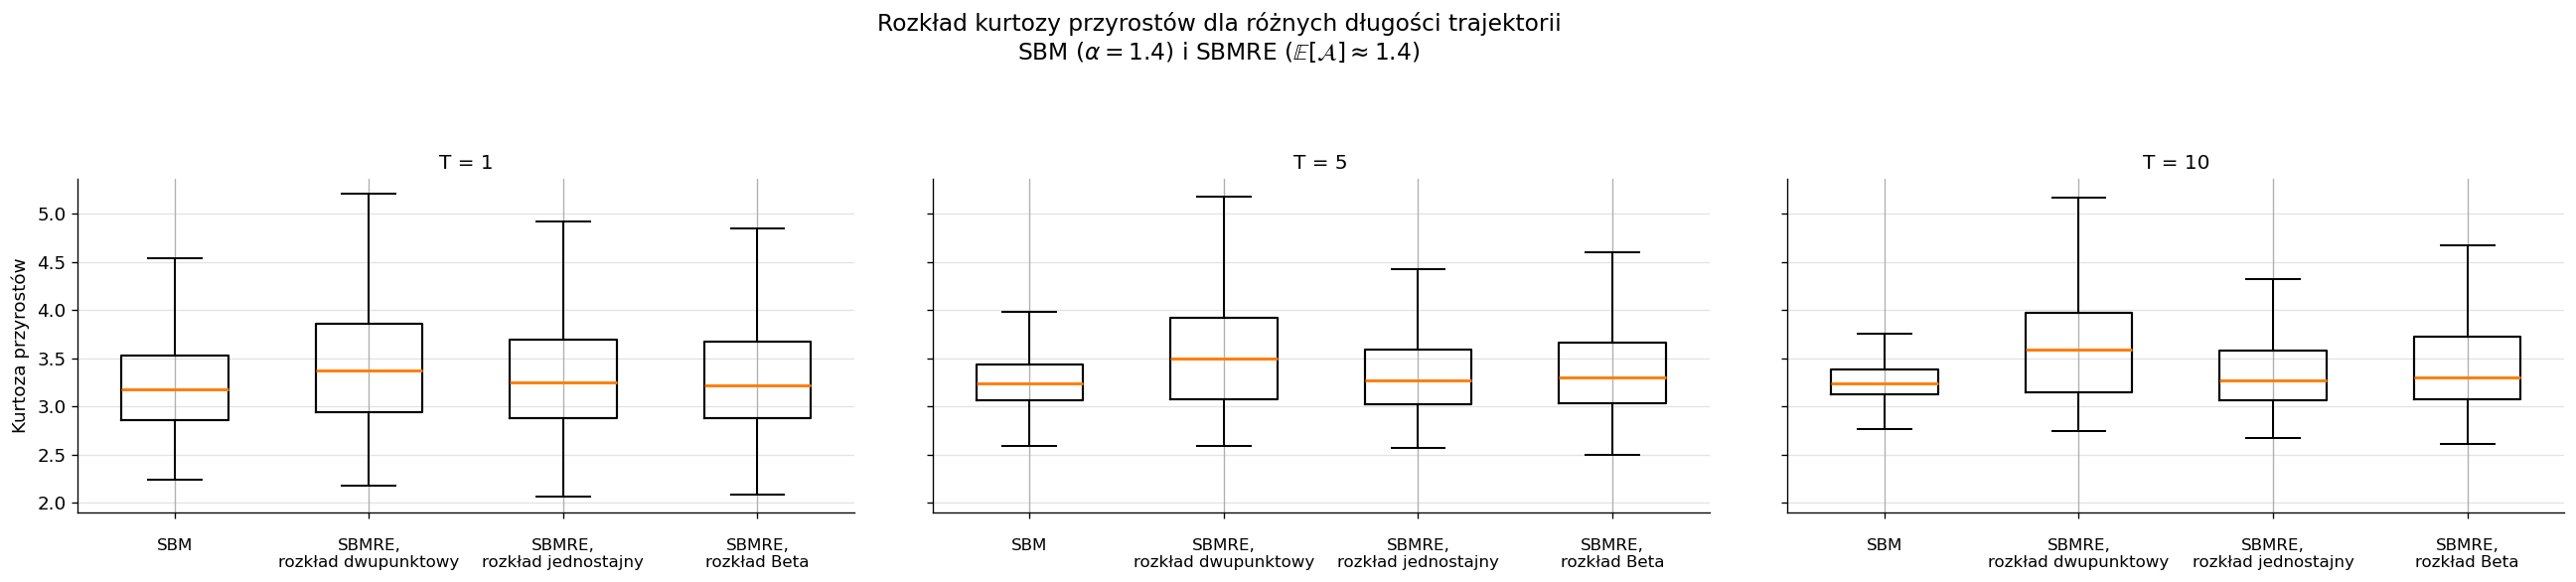

In [149]:
# ------------------------------------------------------------
# 5) Wykresy: 3 panele (spójne z TAMSD), etykiety prosto
# ------------------------------------------------------------
T_show = T_list  # [1, 5, 10]

# etykiety jak chcesz (bez skrótów)
labels = [
    "SBM",
    "SBMRE,\nrozkład dwupunktowy",
    "SBMRE,\nrozkład jednostajny",
    "SBMRE,\nrozkład Beta",
]
keys = ["SBM", "SBMRE: 2pkt", "SBMRE: U", "SBMRE: beta"]  # jak w results[(key,T)]

fig, axes = plt.subplots(1, len(T_show), figsize=(7.6*len(T_show), 5.6), sharey=True)
if len(T_show) == 1:
    axes = [axes]

for ax, T in zip(axes, T_show):
    data = [results[(k, T)] for k in keys]

    ax.boxplot(
        data,
        labels=labels,
        showfliers=False,
        widths=0.55,
        medianprops=dict(linewidth=1.8),
        boxprops=dict(linewidth=1.3),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )

    ax.set_title(f"T = {T}", fontsize=12, pad=6)
    ax.grid(True, axis="y", alpha=0.35)

    # etykiety prosto + trochę miejsca w dół
    ax.tick_params(axis="x", labelsize=10, pad=12)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(0)
        lbl.set_ha("center")

axes[0].set_ylabel("Kurtoza przyrostów")

fig.suptitle(
    r"Rozkład kurtozy przyrostów dla różnych długości trajektorii" + "\n" +
    r"SBM ($\alpha = 1.4$) i SBMRE ($\mathbb{E}[\mathcal{A}] \approx 1.4$)",
    fontsize=14, y=1.05
)

fig.subplots_adjust(left=0.08, right=0.995, bottom=0.30, top=0.80, wspace=0.10)
plt.show()


#### Wpływ wartości wykładnika dyfuzji

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# parametry symulacji
# -----------------------------
T = 10.0
dt = 1e-3
n_paths = 1000
seed = 123

# wartości wykładnika dyfuzji
alpha_list = [0.5, 0.75, 1.0, 1.25, 1.5]

rng = np.random.default_rng(seed)


In [42]:
# -----------------------------
# symulacje SBM
# -----------------------------
sbm_data = {}

for alpha in alpha_list:
    t, X = simulate_sbm(alpha, T, dt, n_paths, rng)
    sbm_data[alpha] = X   # X: (n_paths, N_time)


In [43]:
def msd(X):
    """
    X: (n_paths, n_time)
    """
    X0 = X[:, [0]]
    return np.mean((X - X0)**2, axis=0)


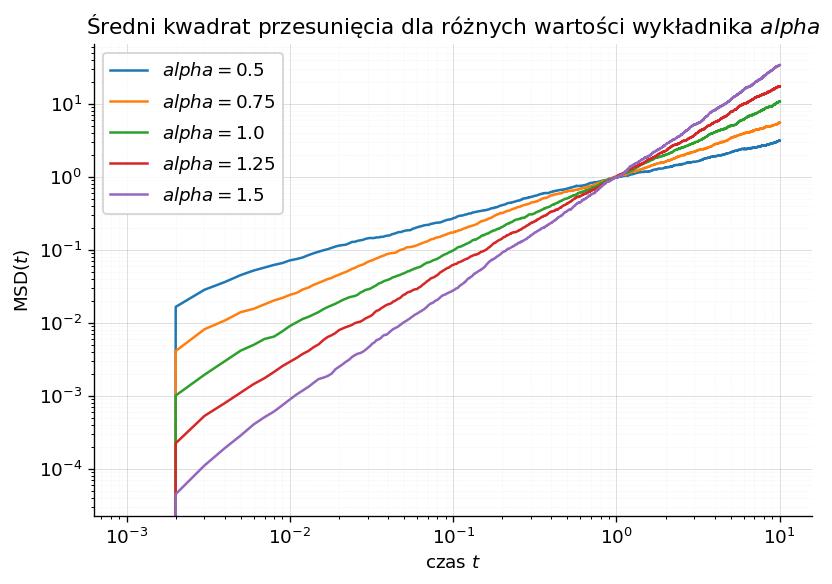

In [52]:
# -----------------------------
# MSD w skali log-log
# -----------------------------
plt.figure(figsize=(7,5))

for alpha in alpha_list:
    X = sbm_data[alpha]
    msd_val = msd(X)
    plt.loglog(t[1:], msd_val[1:], label=rf"$alpha={alpha}$")

plt.xlabel(r"czas $t$")
plt.ylabel(r"$\mathrm{MSD}(t)$")
plt.title("Średni kwadrat przesunięcia dla różnych wartości wykładnika $alpha$")
plt.legend()
plt.grid(which="major", linestyle="-", linewidth=0.4, alpha=0.6)
plt.grid(which="minor", linestyle=":", linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.show()


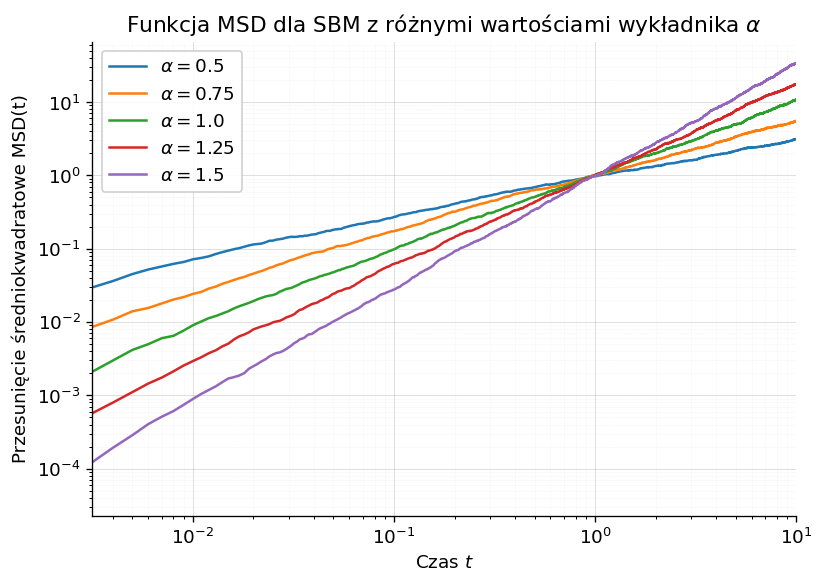

In [55]:
plt.figure(figsize=(7,5))

for alpha in alpha_list:
    X = sbm_data[alpha]
    msd_val = msd(X)
    plt.loglog(t[1:], msd_val[1:], label=rf"$\alpha={alpha}$")

# ---- osie ----
plt.xlabel(r"Czas $t$")
plt.ylabel(r"Przesunięcie średniokwadratowe MSD(t)")
plt.title(r"Funkcja MSD dla SBM z różnymi wartościami wykładnika $\alpha$")

# X od 10^-2.5
plt.xlim(10**(-2.5), t[-1])

# ---- siatka (ładniejsza) ----
plt.grid(which="major", linestyle="-", linewidth=0.4, alpha=0.6)
plt.grid(which="minor", linestyle=":", linewidth=0.3, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()


In [46]:
def estimate_alpha_from_msd(t, msd_vals, t_min=1.0):
    mask = t >= t_min
    coeffs = np.polyfit(np.log(t[mask]), np.log(msd_vals[mask]), 1)
    return coeffs[0]  # nachylenie


In [47]:
print("Estymowane nachylenia MSD:")
for alpha in alpha_list:
    X = sbm_data[alpha]
    msd_val = msd(X)
    alpha_hat = estimate_alpha_from_msd(t[1:], msd_val[1:])
    print(f"α = {alpha:4.2f}  →  α̂ ≈ {alpha_hat:.3f}")


Estymowane nachylenia MSD:
α = 0.50  →  α̂ ≈ 0.506
α = 0.75  →  α̂ ≈ 0.755
α = 1.00  →  α̂ ≈ 1.030
α = 1.25  →  α̂ ≈ 1.277
α = 1.50  →  α̂ ≈ 1.554


In [48]:
def tamsd(X, tau_idx):
    """
    tau_idx: opóźnienie w indeksach
    """
    n_paths, n_time = X.shape
    vals = []
    for i in range(n_paths):
        d = X[i, tau_idx:] - X[i, :-tau_idx]
        vals.append(np.mean(d**2))
    return np.array(vals)


C:\Users\User\AppData\Local\Temp\ipykernel_1180\1062547706.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[rf"$\alpha={a}$" for a in alpha_list], showfliers=False)


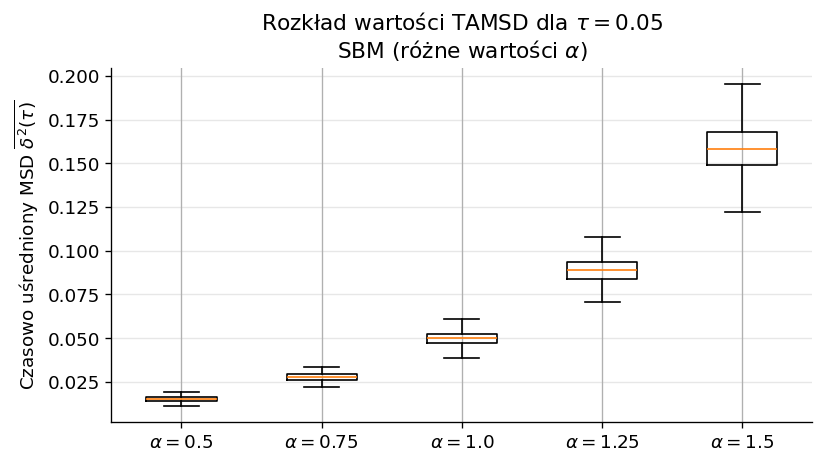

In [57]:
# -----------------------------
# TAMSD dla jednego τ
# -----------------------------
tau = 0.05
tau_idx = int(tau / dt)

plt.figure(figsize=(7,4))

data = [tamsd(sbm_data[alpha], tau_idx) for alpha in alpha_list]

plt.boxplot(data, labels=[rf"$\alpha={a}$" for a in alpha_list], showfliers=False)
plt.ylabel(r"Czasowo uśredniony MSD $\overline{\delta^2(\tau)}$")
plt.title(rf"Rozkład wartości TAMSD dla $\tau={tau}$"
        "\n" 
        r"SBM (różne wartości $\alpha$)"
)
# plt.title(
#     r"Rozkład wartości TAMSD dla $\tau \approx T/10$"
#     "\n"
#     r"SBM ($\alpha = 1.4$) i SBMRE ($\mathbb{E}[A] \approx 1.4$)"
# )
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [50]:
ref = alpha_list[0]

print("Względna zmiana MSD(T):")
msd_ref = msd(sbm_data[ref])[-1]

for alpha in alpha_list[1:]:
    msd_val = msd(sbm_data[alpha])[-1]
    change = 100 * (msd_val / msd_ref - 1)
    print(f"α={alpha}: +{change:.1f}% względem α={ref}")


Względna zmiana MSD(T):
α=0.75: +76.2% względem α=0.5
α=1.0: +241.9% względem α=0.5
α=1.25: +448.8% względem α=0.5
α=1.5: +982.7% względem α=0.5


#### Wypływ rodzaju losowości

Kontrola E[A] (średnia z próby):
dwupunktowy : mean(A) = 1.3868, std(A) = 0.5999
jednostajny : mean(A) = 1.4055, std(A) = 0.3402
beta        : mean(A) = 1.3973, std(A) = 0.4310


C:\Users\User\AppData\Local\Temp\ipykernel_1180\4206442074.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([features[k]["tamsd"] for k in order], labels=labels, showfliers=False, widths=0.55)
C:\Users\User\AppData\Local\Temp\ipykernel_1180\4206442074.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([features[k]["dma"] for k in order], labels=labels, showfliers=False, widths=0.55)
C:\Users\User\AppData\Local\Temp\ipykernel_1180\4206442074.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([features[k]["kurt"] for k in order], labels=labels, showfliers=False,

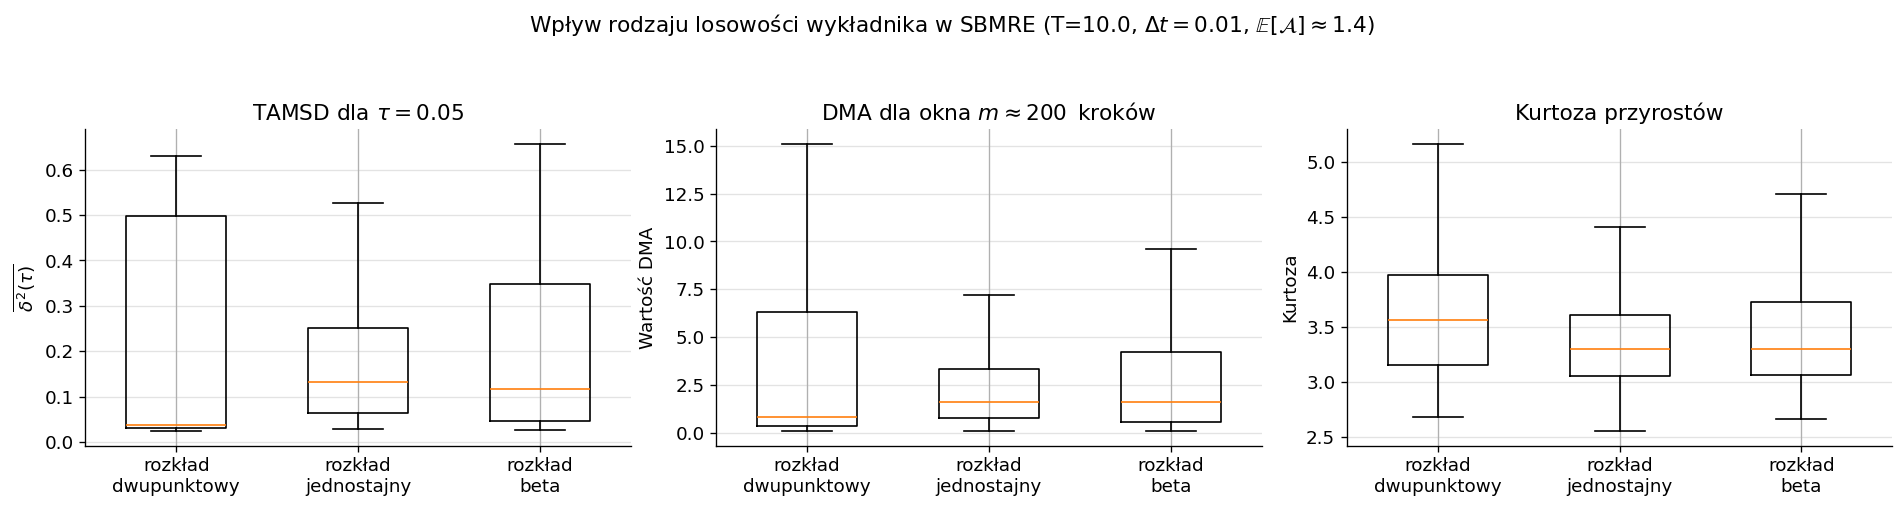


=== TAMSD ===
dwupunktowy : med=0.03726, IQR=0.4669, CV=0.908 | IQR vs jednostajny: +150.6%, med vs jednostajny: -71.9%
jednostajny : med=0.1325, IQR=0.1863, CV=0.738 | IQR vs jednostajny: +0.0%, med vs jednostajny: +0.0%
beta        : med=0.1162, IQR=0.3005, CV=0.857 | IQR vs jednostajny: +61.3%, med vs jednostajny: -12.3%

=== DMA ===
dwupunktowy : med=0.8026, IQR=5.935, CV=1.148 | IQR vs jednostajny: +130.7%, med vs jednostajny: -49.7%
jednostajny : med=1.595, IQR=2.573, CV=1.017 | IQR vs jednostajny: +0.0%, med vs jednostajny: +0.0%
beta        : med=1.601, IQR=3.631, CV=1.078 | IQR vs jednostajny: +41.1%, med vs jednostajny: +0.3%

=== KURT ===
dwupunktowy : med=3.559, IQR=0.8172, CV=0.136 | IQR vs jednostajny: +48.3%, med vs jednostajny: +7.9%
jednostajny : med=3.299, IQR=0.5511, CV=0.110 | IQR vs jednostajny: +0.0%, med vs jednostajny: +0.0%
beta        : med=3.3, IQR=0.657, CV=0.125 | IQR vs jednostajny: +19.2%, med vs jednostajny: +0.0%


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# ============================================================
# 0) PARAMETRY EKSPERYMENTU (edytuj tylko to)
# ============================================================
T = 10.0
dt = 1e-2              # daj 1e-2 żeby było szybko; do finalnych wykresów możesz 1e-3
n_paths = 1000         # 1000–3000 w zupełności wystarczy
alpha0 = 1.4           # E[A] = 1.4
eps = 0.6              # zakres ok. [0.8, 2.0] jeśli używasz "alpha0 ± eps"
seed_base = 202501

# opóźnienie do TAMSD (wybierz jedną opcję)
tau_ref = 0.05         # stałe tau
# tau_ref = T/10       # alternatywa: tau = T/10

# okno do DMA (wybierz jedną opcję; DMA jest czułe na okno)
m_ref = int(round((T/5) / dt))   # duże okno ~ T/5
m_ref = max(5, m_ref)            # zabezpieczenie

# ============================================================
# 1) SAMPLERY SBMRE (3 rodzaje losowości, stałe E[A]=alpha0)
#    UWAGA: make_beta_sampler u Ciebie przyjmuje (alpha0, eps, a, b)
# ============================================================
samplers = {
    "dwupunktowy": make_two_point_sampler(alpha0, eps),
    "jednostajny": make_uniform_sampler(alpha0, eps),
    "beta":        make_beta_sampler(alpha0, eps, a=0.5, b=0.5),
}

# ============================================================
# 2) FUNKCJE CECH: TAMSD(tau), DMA(m), kurtoza przyrostów
# ============================================================
def tamsd_for_tau(X, dt, tau):
    """Zwraca wektor TAMSD(tau) dla każdej trajektorii."""
    lag = int(np.round(tau / dt))
    if lag < 1 or lag >= X.shape[1]:
        raise ValueError("tau poza zakresem dla danego dt i długości trajektorii.")
    d = X[:, lag:] - X[:, :-lag]
    return np.mean(d**2, axis=1)

def dma_for_m(X, m):
    """
    Prosta wersja DMA:
    - liczymy średnią ruchomą (okno m) i bierzemy wariancję reszt.
    Zwraca wektor (n_paths,) z jedną liczbą na trajektorię.
    """
    if m < 3 or m >= X.shape[1]:
        raise ValueError("m poza zakresem.")
    # średnia ruchoma: splot po czasie dla każdej trajektorii
    kernel = np.ones(m) / m
    # valid => krótszy wynik, ale wystarczy do stabilnej miary
    mov = np.apply_along_axis(lambda x: np.convolve(x, kernel, mode="valid"), 1, X)
    # dopasuj długości: reszty liczymy na tym samym odcinku
    X_cut = X[:, (m-1):]  # odpowiada trybowi "valid"
    resid = X_cut - mov
    return np.mean(resid**2, axis=1)

def kurtosis_increments(X):
    """
    Kurtoza z przyrostów, liczona osobno na trajektorię.
    fisher=False => rozkład normalny ~ 3
    Standaryzujemy przyrosty per trajektoria.
    """
    dX = np.diff(X, axis=1)
    mu = dX.mean(axis=1, keepdims=True)
    sd = dX.std(axis=1, keepdims=True)
    sd = np.where(sd == 0, 1.0, sd)
    z = (dX - mu) / sd
    return kurtosis(z, axis=1, fisher=False, bias=False)

def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

def cv(x):
    # CV stabilniejsze licz z medianą? klasyczny CV:
    m = np.mean(x)
    return np.std(x) / m if m != 0 else np.nan

# ============================================================
# 3) SYMULACJE + LICZENIE CECH
# ============================================================
features = {}  # features[name] = dict(tamsd=..., dma=..., kurt=..., alphas=...)
for j, (name, sampler) in enumerate(samplers.items()):
    seed = seed_base + 100*j
    t_re, X_re, A_re = simulate_sbmre(T=T, dt=dt, n_paths=n_paths, seed=seed, alpha_sampler=sampler)

    feats = {}
    feats["tamsd"] = tamsd_for_tau(X_re, dt, tau_ref)
    feats["dma"]   = dma_for_m(X_re, m_ref)
    feats["kurt"]  = kurtosis_increments(X_re)
    feats["A"]     = A_re  # do ewentualnej kontroli E[A]
    features[name] = feats

# szybka kontrola, czy średnie E[A] są faktycznie podobne:
print("Kontrola E[A] (średnia z próby):")
for name in samplers:
    print(f"{name:12s}: mean(A) = {np.mean(features[name]['A']):.4f}, std(A) = {np.std(features[name]['A']):.4f}")

# ============================================================
# 4) WYKRESY: 3 boxploty (TAMSD, DMA, kurtoza) – spójny styl
# ============================================================
order = ["dwupunktowy", "jednostajny", "beta"]
labels = ["rozkład\ndwupunktowy", "rozkład\njednostajny", "rozkład\nbeta"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=False)

# (A) TAMSD
axes[0].boxplot([features[k]["tamsd"] for k in order], labels=labels, showfliers=False, widths=0.55)
axes[0].set_title(rf"TAMSD dla $\tau={tau_ref}$")
axes[0].set_ylabel(r"$\overline{\delta^2(\tau)}$")
axes[0].grid(True, axis="y", alpha=0.35)

# (B) DMA
axes[1].boxplot([features[k]["dma"] for k in order], labels=labels, showfliers=False, widths=0.55)
axes[1].set_title(rf"DMA dla okna $m \approx {m_ref}\,$ kroków")
axes[1].set_ylabel("Wartość DMA")
axes[1].grid(True, axis="y", alpha=0.35)

# (C) Kurtoza przyrostów
axes[2].boxplot([features[k]["kurt"] for k in order], labels=labels, showfliers=False, widths=0.55)
axes[2].set_title("Kurtoza przyrostów")
axes[2].set_ylabel("Kurtoza")
axes[2].grid(True, axis="y", alpha=0.35)

fig.suptitle(
    rf"Wpływ rodzaju losowości wykładnika w SBMRE (T={T}, $\Delta t={dt}$, $\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0}$)",
    y=1.05, fontsize=13
)
plt.tight_layout()
plt.show()

# ============================================================
# 5) LICZBY DO OPISU: mediana, IQR, CV + różnice w % względem 'jednostajny'
# ============================================================
baseline = "jednostajny"

def summarize_feature(key):
    print(f"\n=== {key.upper()} ===")
    base_iqr = iqr(features[baseline][key])
    base_med = np.median(features[baseline][key])

    for name in order:
        x = features[name][key]
        med = np.median(x)
        spread_iqr = iqr(x)
        spread_cv  = cv(x)

        # różnice w % względem baseline (IQR jako „rozrzut”)
        pct_iqr = (spread_iqr / base_iqr - 1.0) * 100 if base_iqr != 0 else np.nan
        pct_med = (med / base_med - 1.0) * 100 if base_med != 0 else np.nan

        print(
            f"{name:12s}: med={med:.4g}, IQR={spread_iqr:.4g}, CV={spread_cv:.3f} | "
            f"IQR vs {baseline}: {pct_iqr:+.1f}%, med vs {baseline}: {pct_med:+.1f}%"
        )

summarize_feature("tamsd")
summarize_feature("dma")
summarize_feature("kurt")


In [67]:
import matplotlib.pyplot as plt

order  = ["dwupunktowy", "jednostajny", "beta"]
labels = ["SBMRE,\nrozkład dwupunktowy", "SBMRE,\nrozkład jednostajny", "SBMRE,\nrozkład beta"]

title_common = rf"SBMRE ($\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0}$)"

C:\Users\User\AppData\Local\Temp\ipykernel_1180\960332355.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([features[k]["tamsd"] for k in order],


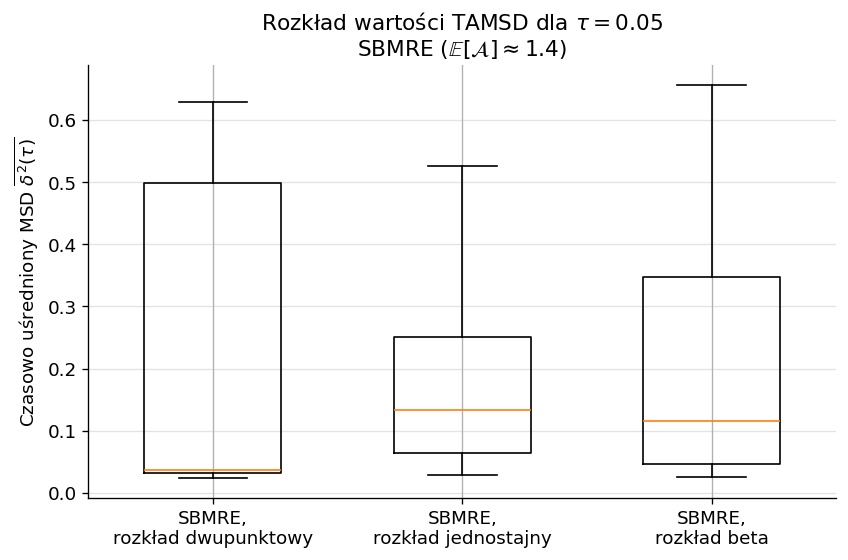

In [69]:
# -----------------------------
# (1) TAMSD — osobny wykres
# -----------------------------
plt.figure(figsize=(7.2, 4.8))
plt.boxplot([features[k]["tamsd"] for k in order],
            labels=labels, showfliers=False, widths=0.55)
plt.ylabel(r"Czasowo uśredniony MSD $\overline{\delta^2(\tau)}$")
plt.title(rf"Rozkład wartości TAMSD dla $\tau={tau_ref}$" + "\n" + title_common)
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_1180\943733871.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([features[k]["dma"] for k in order],


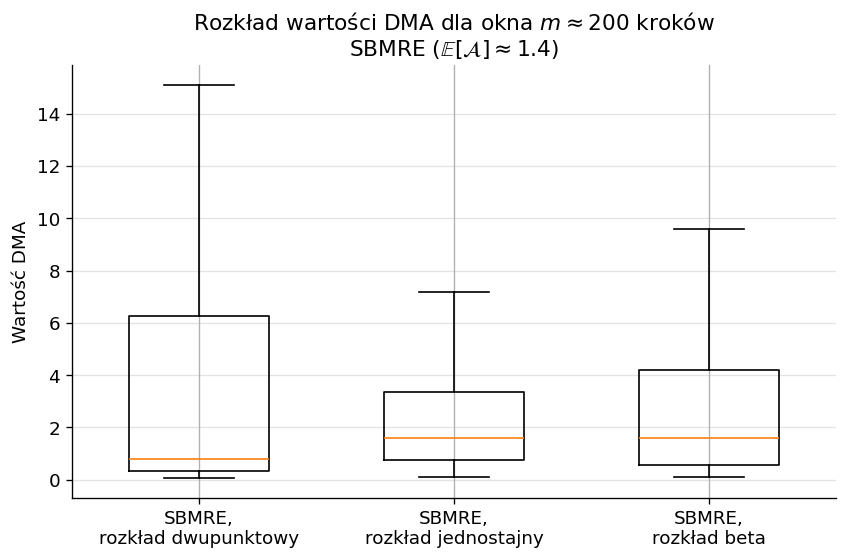

C:\Users\User\AppData\Local\Temp\ipykernel_1180\943733871.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([features[k]["kurt"] for k in order],


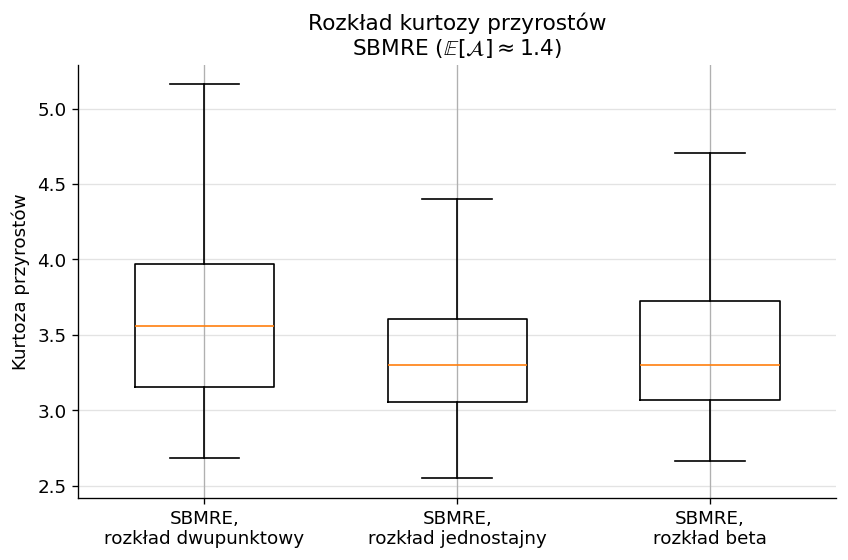

In [70]:
# -----------------------------
# (2) DMA — osobny wykres
# -----------------------------
plt.figure(figsize=(7.2, 4.8))
plt.boxplot([features[k]["dma"] for k in order],
            labels=labels, showfliers=False, widths=0.55)
plt.ylabel("Wartość DMA")
plt.title(rf"Rozkład wartości DMA dla okna $m \approx {m_ref}$ kroków" + "\n" + title_common)
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

# -----------------------------
# (3) Kurtoza — osobny wykres
# -----------------------------
plt.figure(figsize=(7.2, 4.8))
plt.boxplot([features[k]["kurt"] for k in order],
            labels=labels, showfliers=False, widths=0.55)
plt.ylabel("Kurtoza przyrostów")
plt.title("Rozkład kurtozy przyrostów" + "\n" + title_common)
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


In [71]:
import numpy as np

def dma_for_tau(X, dt, tau):
    """
    DMA dla skali czasowej tau (okno detrendowania).
    Zwraca wektor (n_paths,) — jedna wartość DMA na trajektorię.

    Idea:
    1) trend = średnia ruchoma w oknie m = round(tau/dt)
    2) reszty = X - trend (na części 'valid')
    3) DMA = średnia z reszt^2
    """
    m = int(np.round(tau / dt))
    if m < 3:
        raise ValueError("tau za małe (m<3). Zwiększ tau albo dt.")
    if m >= X.shape[1]:
        raise ValueError("tau za duże (m>=liczba punktów czasu).")

    kernel = np.ones(m) / m

    # moving average per trajektoria
    mov = np.apply_along_axis(lambda x: np.convolve(x, kernel, mode="valid"), 1, X)

    # dopasowanie długości (mode='valid' skraca serię o m-1)
    X_cut = X[:, (m-1):]
    resid = X_cut - mov

    return np.mean(resid**2, axis=1)


C:\Users\User\AppData\Local\Temp\ipykernel_1180\1498251341.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([features[k]["dma"] for k in order],


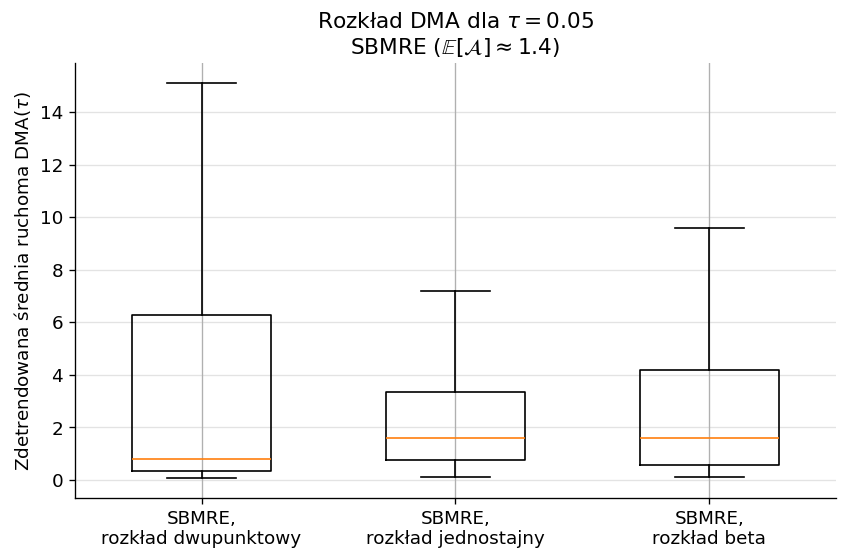

In [77]:
import matplotlib.pyplot as plt

# --- wybór tau do DMA (spójnie z TAMSD możesz wziąć np. tau = T/5) ---
tau_dma = T/200   # np. 2.0 gdy T=10

# jeśli features już istnieje i masz w nim np. X (nie masz) -> licz z trajektorii przed zapisaniem
# więc typowo: w pętli symulacji dodaj:
# feats["dma"] = dma_for_tau(X_re, dt, tau_dma)

# tu zakładam, że już masz:
# features[name]["dma"] dla name in {"dwupunktowy","jednostajny","beta"}

order  = ["dwupunktowy", "jednostajny", "beta"]
labels = ["SBMRE,\nrozkład dwupunktowy", "SBMRE,\nrozkład jednostajny", "SBMRE,\nrozkład beta"]

plt.figure(figsize=(7.2, 4.8))
plt.boxplot([features[k]["dma"] for k in order],
            labels=labels, showfliers=False, widths=0.55)
plt.ylabel(r"Zdetrendowana średnia ruchoma $\mathrm{DMA}(\tau)$")
plt.title(rf"Rozkład DMA dla $\tau={tau_dma}$" + "\n" +
          rf"SBMRE ($\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0}$)")
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


#### Wpływ kroku czasowego

In [103]:
import numpy as np
import matplotlib.pyplot as plt

def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

def rel_diff(a, b):
    """Względna różnica |a-b| / |b|."""
    b = float(b)
    if b == 0:
        return np.nan
    return abs(a - b) / abs(b)


In [104]:
# =========================
# 1) USTAWIENIA EKSPERYMENTU
# =========================
T = 10.0
dt_list = [1e-2, 5e-3, 1e-3]     # 1e-4 raczej odpuść na laptopie, chyba że mało trajektorii
n_paths = 1500                   # 1000–2000 ok
seed_base = 777

# stałe parametry porównania
alpha_sbm = 1.4
alpha0 = 1.4
eps = 0.6

# stałe skale do cech (czasowe, więc muszą być takie same między dt)
tau_tamsd = 0.05       # np. stałe 0.05
tau_dma   = T/5        # np. 2.0 przy T=10

# wybierz JEDEN rozkład SBMRE (najlepiej "jednostajny" albo "beta")
sampler = make_uniform_sampler(alpha0, eps)
name_sbmre = "SBMRE (rozkład jednostajny)"

results_dt = {}  # results_dt[dt] = dict z cechami

for k, dt in enumerate(dt_list):
    seed = seed_base + 100*k

    # --- SBM ---
    rng = np.random.default_rng(seed)
    t_sbm, X_sbm = simulate_sbm(alpha_sbm, T, dt, n_paths, rng)

    # --- SBMRE ---
    t_re, X_re, A_re = simulate_sbmre(T=T, dt=dt, n_paths=n_paths, seed=seed+999, alpha_sampler=sampler)

    # --- cechy ---
    feats = {
        "tamsd_sbm":  tamsd_for_tau(X_sbm, dt, tau_tamsd),
        "tamsd_re":   tamsd_for_tau(X_re,  dt, tau_tamsd),
        "dma_sbm":    dma_for_tau(X_sbm,   dt, tau_dma),
        "dma_re":     dma_for_tau(X_re,    dt, tau_dma),
        "kurt_sbm":   kurtosis_increments(X_sbm),
        "kurt_re":    kurtosis_increments(X_re),
        "meanA":      np.mean(A_re),
        "stdA":       np.std(A_re),
    }
    results_dt[dt] = feats

print("Kontrola SBMRE: średnia i std losowego wykładnika A:")
for dt in dt_list:
    print(f"dt={dt:g}: mean(A)={results_dt[dt]['meanA']:.4f}, std(A)={results_dt[dt]['stdA']:.4f}")


Kontrola SBMRE: średnia i std losowego wykładnika A:
dt=0.01: mean(A)=1.4049, std(A)=0.3421
dt=0.005: mean(A)=1.4061, std(A)=0.3479
dt=0.001: mean(A)=1.4174, std(A)=0.3411


C:\Users\User\AppData\Local\Temp\ipykernel_1180\1485668540.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False, widths=0.55)
C:\Users\User\AppData\Local\Temp\ipykernel_1180\1485668540.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False, widths=0.55)
C:\Users\User\AppData\Local\Temp\ipykernel_1180\1485668540.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False, widths=0.55)


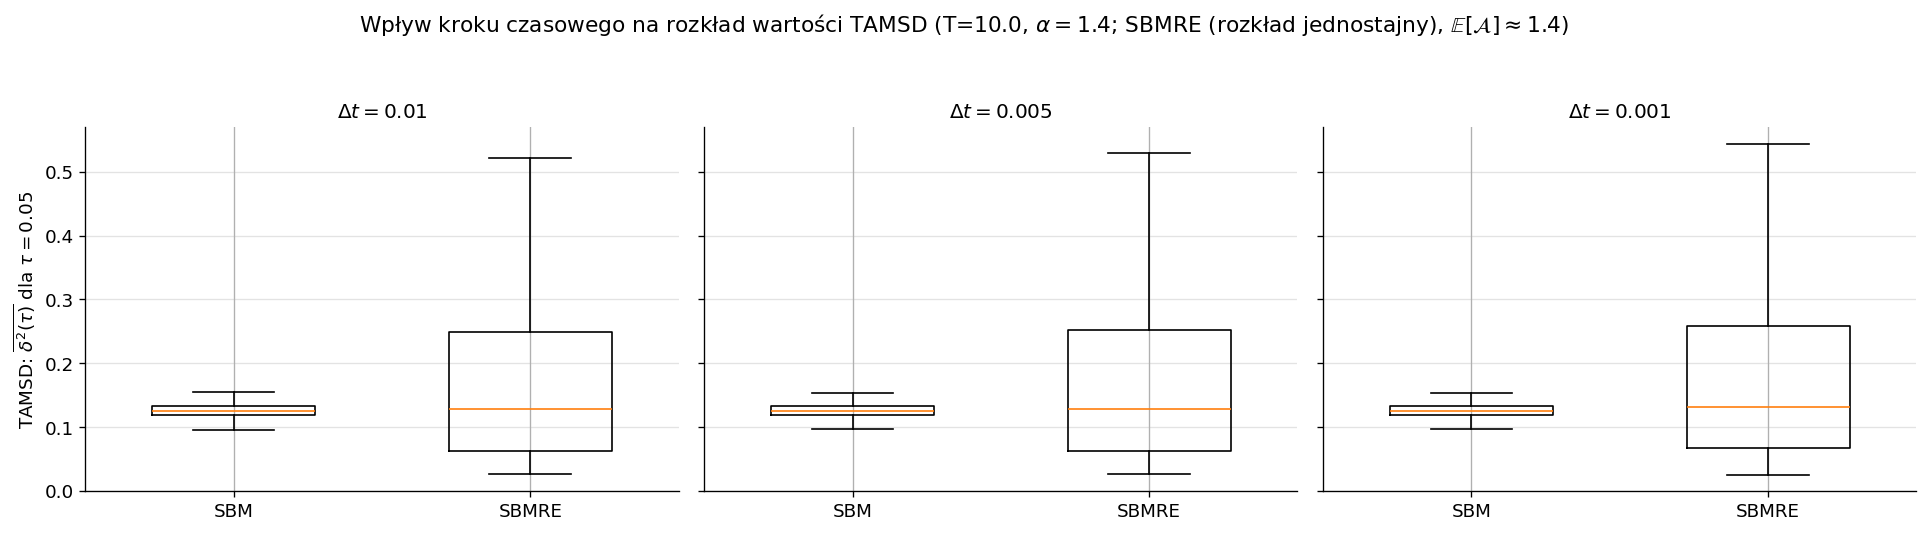

In [111]:
dt_show = dt_list
labels = ["SBM", "SBMRE"]

fig, axes = plt.subplots(1, len(dt_show), figsize=(5.4*len(dt_show), 4.2), sharey=True)
if len(dt_show) == 1:
    axes = [axes]

for ax, dt in zip(axes, dt_show):
    data = [results_dt[dt]["tamsd_sbm"], results_dt[dt]["tamsd_re"]]
    ax.boxplot(data, labels=labels, showfliers=False, widths=0.55)
    ax.set_title(rf"$\Delta t = {dt:g}$", fontsize=12)
    ax.grid(True, axis="y", alpha=0.35)

axes[0].set_ylabel(rf"TAMSD: $\overline{{\delta^2(\tau)}}$ dla $\tau={tau_tamsd}$")
fig.suptitle(
    rf"Wpływ kroku czasowego na rozkład wartości TAMSD (T={T}, $\alpha={alpha_sbm}$; {name_sbmre}, $\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0}$)",
    fontsize=13, y=1.05
)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


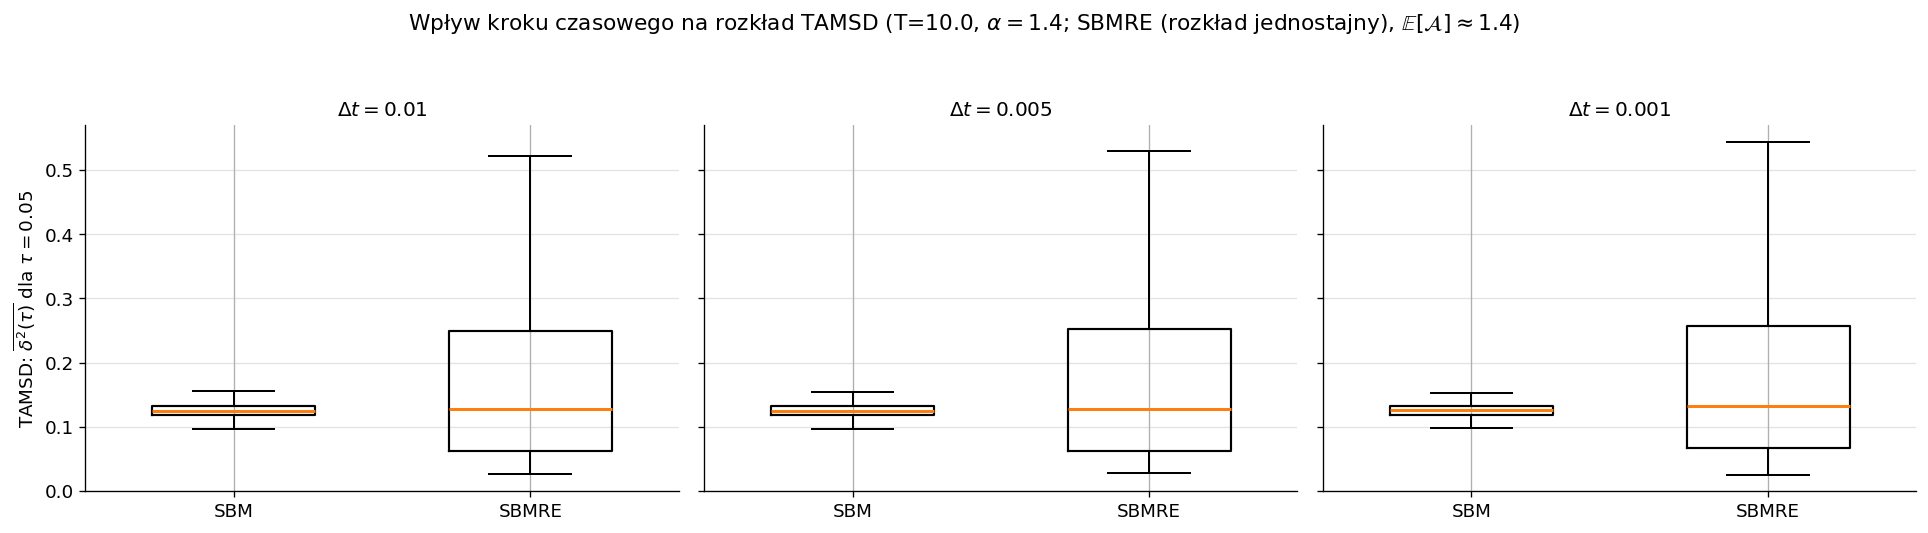

C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


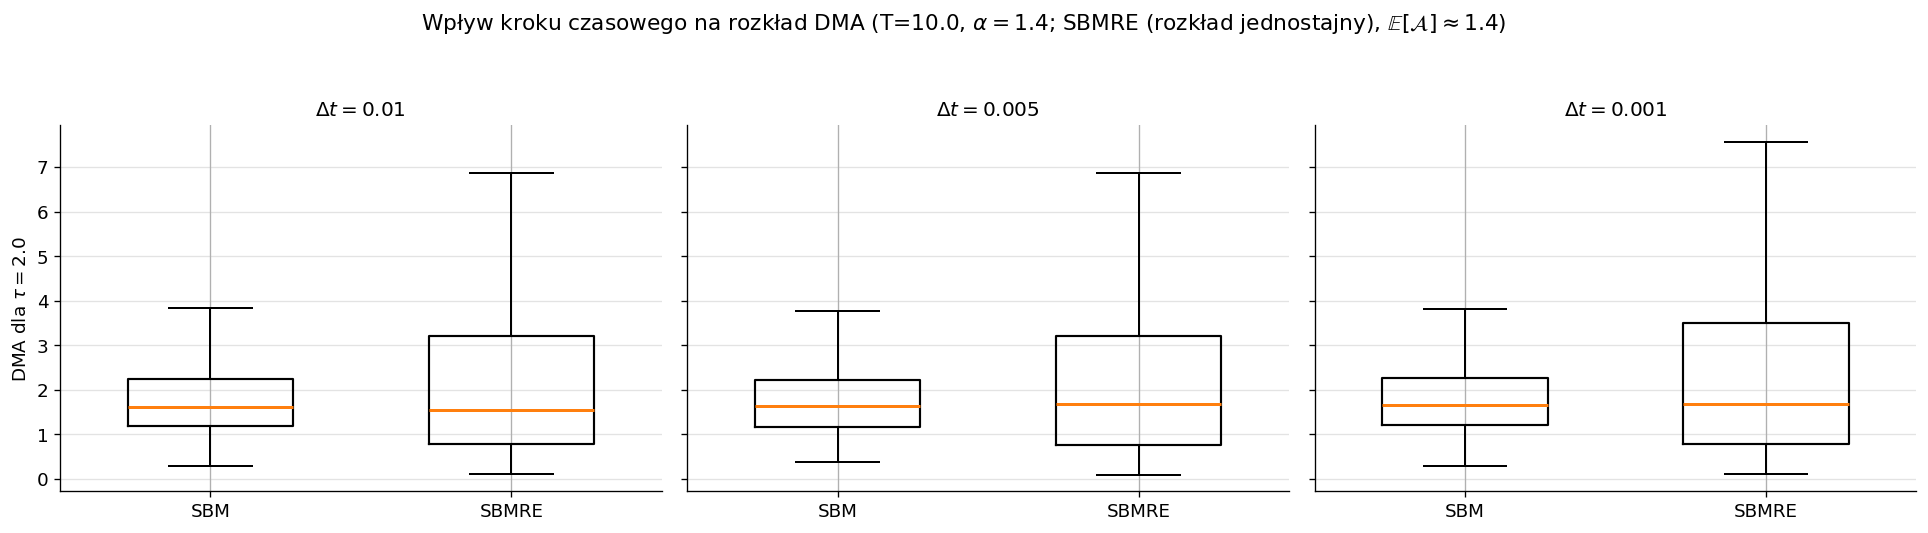

C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\612627934.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


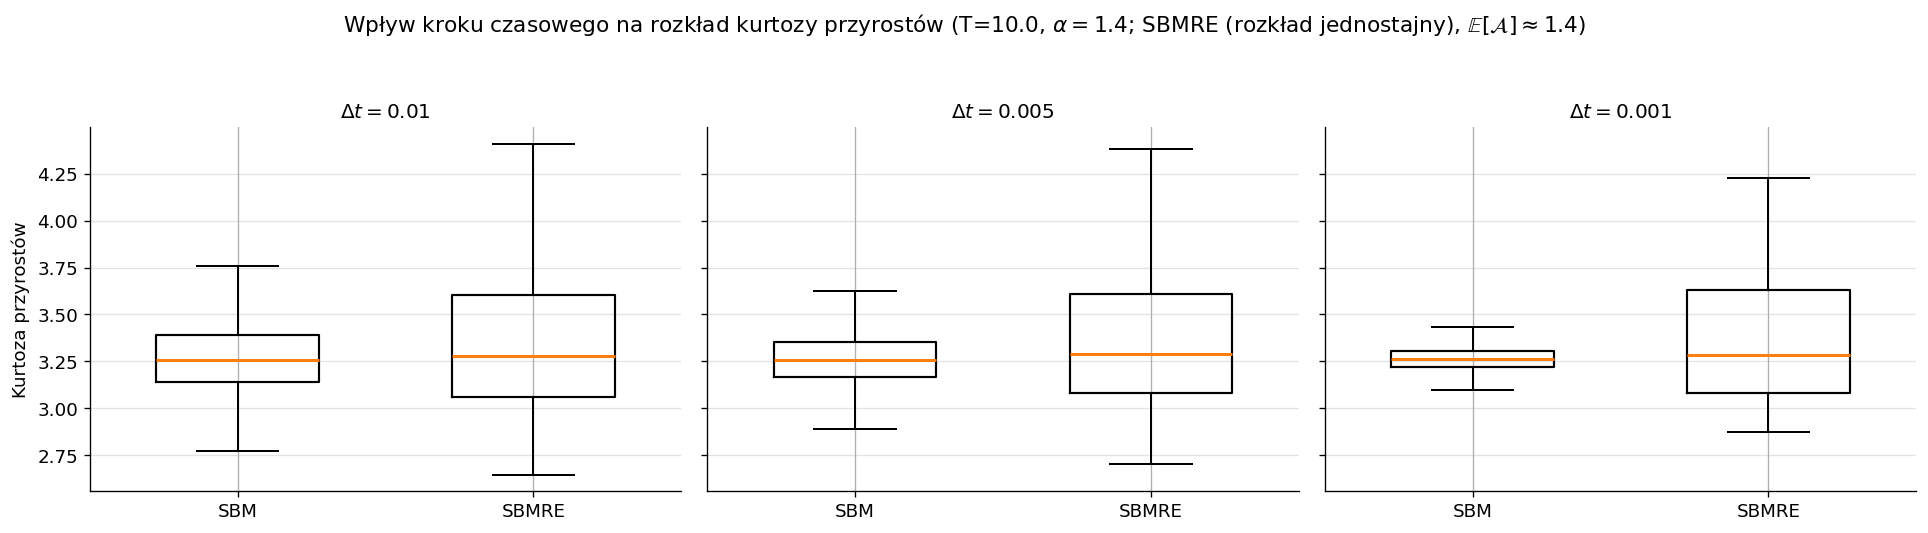

In [ ]:
import matplotlib.pyplot as plt

dt_show = dt_list
labels = ["SBM", "SBMRE"]

def boxplot_feature(feature_sbm, feature_re, ylabel, suptitle):
    fig, axes = plt.subplots(1, len(dt_show), figsize=(5.4*len(dt_show), 4.2), sharey=True)
    if len(dt_show) == 1:
        axes = [axes]

    for ax, dt in zip(axes, dt_show):
        data = [results_dt[dt][feature_sbm], results_dt[dt][feature_re]]
        ax.boxplot(
            data,
            labels=labels,
            showfliers=False,
            widths=0.55,
            medianprops=dict(linewidth=1.8),
            boxprops=dict(linewidth=1.3),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
        )
        ax.set_title(rf"$\Delta t = {dt:g}$", fontsize=12)
        ax.grid(True, axis="y", alpha=0.35)

    axes[0].set_ylabel(ylabel)
    fig.suptitle(suptitle, fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

# 1) TAMSD
boxplot_feature(
    feature_sbm="tamsd_sbm",
    feature_re="tamsd_re",
    ylabel=rf"TAMSD: $\overline{{\delta^2(\tau)}}$ dla $\tau={tau_tamsd}$",
    suptitle=(
        rf"Wpływ kroku czasowego na rozkład wartości TAMSD dla $\tau={tau_tamsd}$"
        "\n"
        rf"(SBM ($\alpha={alpha_sbm}$) i {name_sbmre}, $\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0}$)"
    ),
)

# # 2) DMA (dla tego samego tau/okna co ustaliłaś: tau_dma)
# boxplot_feature(
#     feature_sbm="dma_sbm",
#     feature_re="dma_re",
#     ylabel=rf"DMA dla $\tau={tau_dma}$",
#     suptitle=(
#         rf"Wpływ kroku czasowego na rozkład DMA "
#         rf"(T={T}, $\alpha={alpha_sbm}$; {name_sbmre}, $\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0}$)"
#     ),
# )

# # 3) Kurtoza przyrostów
# boxplot_feature(
#     feature_sbm="kurt_sbm",
#     feature_re="kurt_re",
#     ylabel="Kurtoza przyrostów",
#     suptitle=(
#         rf"Wpływ kroku czasowego na rozkład kurtozy przyrostów "
#         rf"(T={T}, $\alpha={alpha_sbm}$; {name_sbmre}, $\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0}$)"
#     ),
# )


C:\Users\User\AppData\Local\Temp\ipykernel_1180\266688173.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\266688173.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_1180\266688173.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


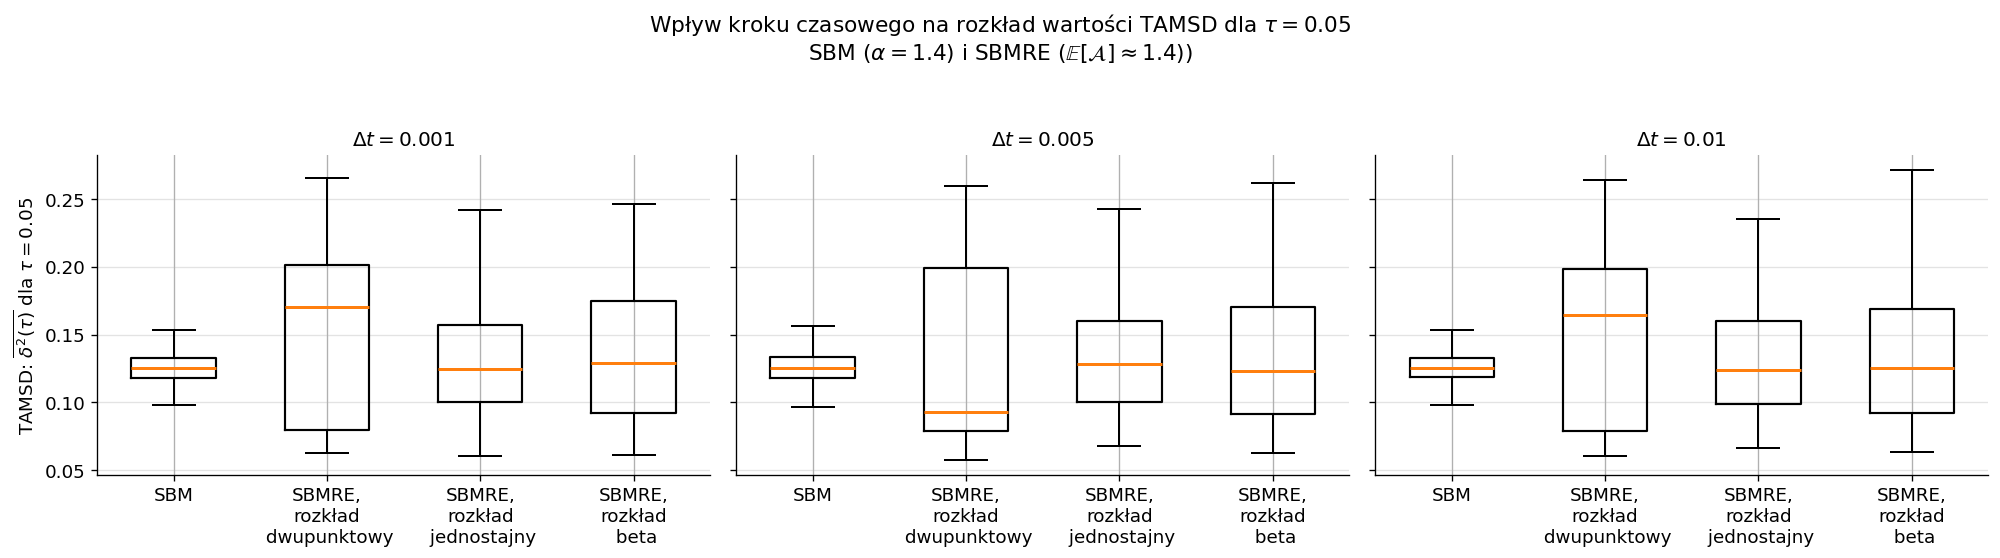

dt_min = 0.001

Maksymalne bezwzględne odchylenie mediany TAMSD względem dt_min:
SBM                         : 4.096%
SBMRE,
rozkład
 dwupunktowy : 46.228%
SBMRE,
rozkład
 jednostajny : 4.467%
SBMRE,
rozkład
 beta        : 7.475%


In [122]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) USTAWIENIA EKSPERYMENTU
# =========================
T = 10.0
dt_list = [1e-3, 1.5e-3, 2e-3, 3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 1e-2]  # 10 punktów
n_paths = 1500
seed_base = 777

alpha_sbm = 1.4
alpha0 = 1.4
eps = 0.2

tau_tamsd = 0.05  # stałe tau w całej sekcji

# =========================
# 2) SAMPLERY SBMRE
# =========================
samplers = {
    "SBMRE,\nrozkład\n dwupunktowy": make_two_point_sampler(alpha0, eps),
    "SBMRE,\nrozkład\n jednostajny": make_uniform_sampler(alpha0, eps),
    "SBMRE,\nrozkład\n beta":        make_beta_sampler(alpha0, eps, a=0.5, b=0.5),
}

# =========================
# 3) SYMULACJE + TAMSD
# =========================
results_dt = {}  # results_dt[dt][label] = wektor TAMSD dla n_paths trajektorii

for k, dt in enumerate(dt_list):
    seed = seed_base + 100*k

    # --- SBM ---
    rng = np.random.default_rng(seed)
    t_sbm, X_sbm = simulate_sbm(alpha_sbm, T, dt, n_paths, rng)
    tamsd_sbm = tamsd_for_tau(X_sbm, dt, tau_tamsd)

    out = {"SBM": tamsd_sbm}

    # --- SBMRE: 3 warianty ---
    for j, (name, sampler) in enumerate(samplers.items()):
        seed_re = seed + 1000 + 10*j
        t_re, X_re, A_re = simulate_sbmre(T=T, dt=dt, n_paths=n_paths, seed=seed_re, alpha_sampler=sampler)
        out[name] = tamsd_for_tau(X_re, dt, tau_tamsd)

    results_dt[dt] = out

# =========================
# 4) WYKRES: boxploty dla każdego dt (3 panele)
#    Jeśli chcesz 3 panele jak wcześniej — wybierz 3 dt (np. min, środek, max).
#    Jeśli chcesz wszystkie 10 dt — zrobimy 10 paneli (będzie bardzo szeroko).
# =========================

# --- wariant A: 3 panele (czytelniejsze do pracy) ---
dt_show = [dt_list[0], dt_list[len(dt_list)//2], dt_list[-1]]

labels_order = ["SBM"] + list(samplers.keys())

fig, axes = plt.subplots(1, len(dt_show), figsize=(5.6*len(dt_show), 4.4), sharey=True)
if len(dt_show) == 1:
    axes = [axes]

for ax, dt in zip(axes, dt_show):
    data = [results_dt[dt][lab] for lab in labels_order]

    ax.boxplot(
        data,
        labels=labels_order,
        showfliers=False,
        widths=0.55,
        medianprops=dict(linewidth=1.8),
        boxprops=dict(linewidth=1.3),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )

    ax.set_title(rf"$\Delta t = {dt:g}$", fontsize=12)
    ax.grid(True, axis="y", alpha=0.35)

axes[0].set_ylabel(rf"TAMSD: $\overline{{\delta^2(\tau)}}$ dla $\tau={tau_tamsd}$")

fig.suptitle(
    rf"Wpływ kroku czasowego na rozkład wartości TAMSD dla $\tau={tau_tamsd}$"
    "\n"
    rf"SBM ($\alpha={alpha_sbm}$) i SBMRE ($\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0})$)",
    fontsize=13, y=1.05
)

plt.tight_layout()
plt.show()

# =========================
# 5) (Opcjonalnie) liczby do opisu: mediany i max odchylenie [%] względem dt_min
# =========================
dt_min = dt_list[0]
print(f"dt_min = {dt_min:g}\n")

med = {lab: [] for lab in labels_order}
for dt in dt_list:
    for lab in labels_order:
        med[lab].append(np.median(results_dt[dt][lab]))

print("Maksymalne bezwzględne odchylenie mediany TAMSD względem dt_min:")
for lab in labels_order:
    baseline = med[lab][0]
    rel = 100.0 * (np.array(med[lab]) - baseline) / baseline
    print(f"{lab:28s}: {np.max(np.abs(rel)):.3f}%")


C:\Users\User\AppData\Local\Temp\ipykernel_1180\2426014174.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False, widths=0.55)
C:\Users\User\AppData\Local\Temp\ipykernel_1180\2426014174.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False, widths=0.55)
C:\Users\User\AppData\Local\Temp\ipykernel_1180\2426014174.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False, widths=0.55)


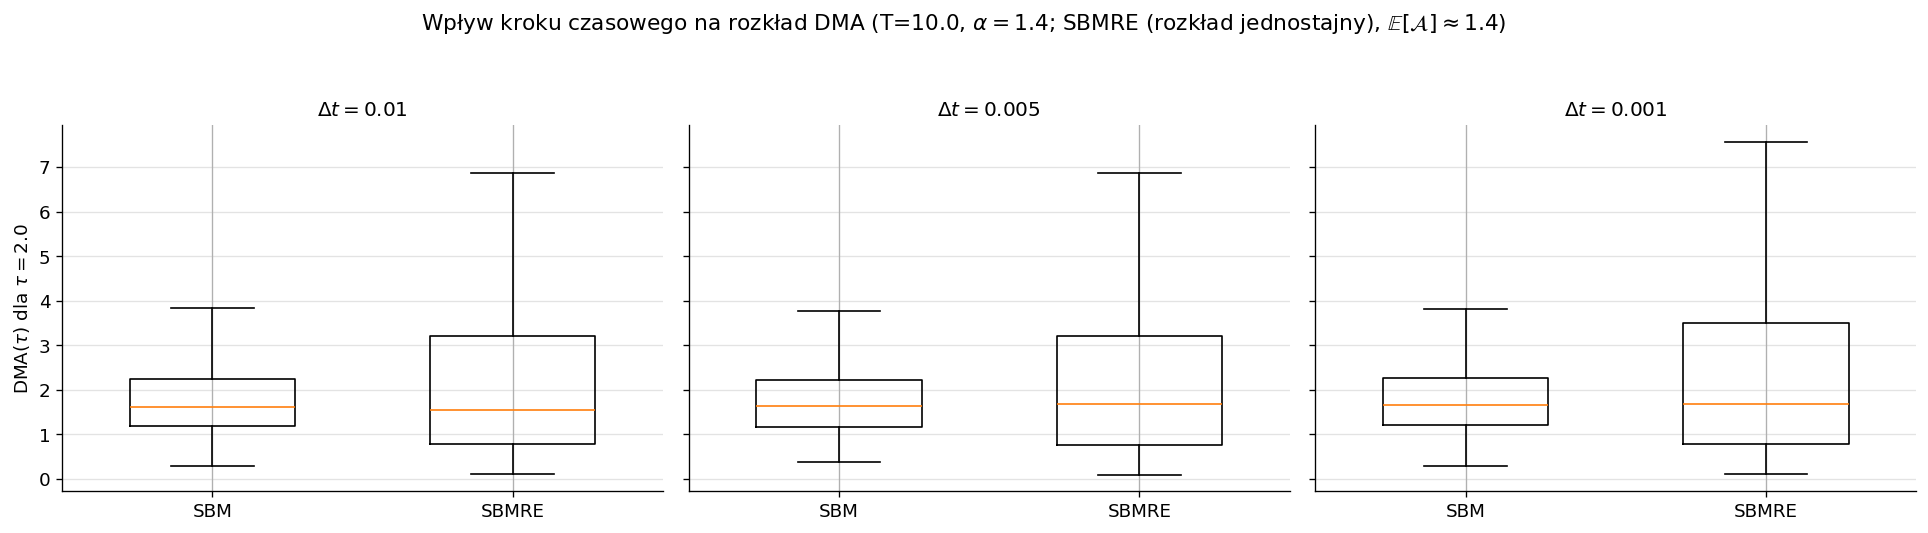

In [88]:
dt_show = dt_list
labels = ["SBM", "SBMRE"]

fig, axes = plt.subplots(1, len(dt_show), figsize=(5.4*len(dt_show), 4.2), sharey=True)
if len(dt_show) == 1:
    axes = [axes]

for ax, dt in zip(axes, dt_show):
    data = [results_dt[dt]["dma_sbm"], results_dt[dt]["dma_re"]]
    ax.boxplot(data, labels=labels, showfliers=False, widths=0.55)
    ax.set_title(rf"$\Delta t = {dt:g}$", fontsize=12)
    ax.grid(True, axis="y", alpha=0.35)

axes[0].set_ylabel(rf"DMA$(\tau)$ dla $\tau={tau_dma}$")
fig.suptitle(
    rf"Wpływ kroku czasowego na rozkład DMA (T={T}, $\alpha={alpha_sbm}$; {name_sbmre}, $\mathbb{{E}}[\mathcal{{A}}]\approx {alpha0}$)",
    fontsize=13, y=1.05
)
plt.tight_layout()
plt.show()


In [89]:
def summarize_dt_stability(key_sbm, key_re, label):
    # referencja: najmniejszy dt (najdokładniejszy)
    dt_ref = min(dt_list)
    med_ref_sbm = np.median(results_dt[dt_ref][key_sbm])
    med_ref_re  = np.median(results_dt[dt_ref][key_re])
    iqr_ref_sbm = iqr(results_dt[dt_ref][key_sbm])
    iqr_ref_re  = iqr(results_dt[dt_ref][key_re])

    max_med_sbm = 0.0
    max_med_re  = 0.0
    max_iqr_sbm = 0.0
    max_iqr_re  = 0.0

    for dt in dt_list:
        med_sbm = np.median(results_dt[dt][key_sbm])
        med_re  = np.median(results_dt[dt][key_re])
        iqr_sbm = iqr(results_dt[dt][key_sbm])
        iqr_re  = iqr(results_dt[dt][key_re])

        max_med_sbm = max(max_med_sbm, rel_diff(med_sbm, med_ref_sbm))
        max_med_re  = max(max_med_re,  rel_diff(med_re,  med_ref_re))
        max_iqr_sbm = max(max_iqr_sbm, rel_diff(iqr_sbm, iqr_ref_sbm))
        max_iqr_re  = max(max_iqr_re,  rel_diff(iqr_re,  iqr_ref_re))

    print(f"\n=== Stabilność względem dt: {label} ===")
    print(f"Referencja: dt_ref = {dt_ref:g}")
    print(f"SBM  | max rel diff mediany: {100*max_med_sbm:.2f}% | max rel diff IQR: {100*max_iqr_sbm:.2f}%")
    print(f"SBMRE| max rel diff mediany: {100*max_med_re :.2f}% | max rel diff IQR: {100*max_iqr_re :.2f}%")

summarize_dt_stability("tamsd_sbm", "tamsd_re", f"TAMSD (tau={tau_tamsd})")
summarize_dt_stability("dma_sbm",   "dma_re",   f"DMA (tau={tau_dma})")
# summarize_dt_stability("kurt_sbm", "kurt_re", "Kurtoza przyrostów")  # jeśli chcesz też to



=== Stabilność względem dt: TAMSD (tau=0.05) ===
Referencja: dt_ref = 0.001
SBM  | max rel diff mediany: 0.31% | max rel diff IQR: 3.55%
SBMRE| max rel diff mediany: 3.12% | max rel diff IQR: 2.15%

=== Stabilność względem dt: DMA (tau=2.0) ===
Referencja: dt_ref = 0.001
SBM  | max rel diff mediany: 3.55% | max rel diff IQR: 2.13%
SBMRE| max rel diff mediany: 8.67% | max rel diff IQR: 10.49%


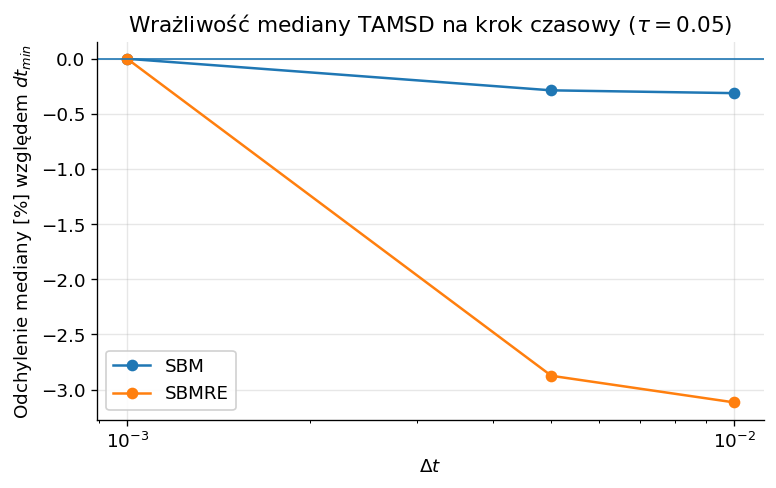

In [90]:
dt_ref = min(dt_list)

def median_rel_error(feat_key):
    ref = np.median(results_dt[dt_ref][feat_key])
    errs = []
    for dt in dt_list:
        val = np.median(results_dt[dt][feat_key])
        errs.append(100*(val-ref)/ref)
    return np.array(errs)

errs_sbm  = median_rel_error("tamsd_sbm")
errs_sbmre= median_rel_error("tamsd_re")

plt.figure(figsize=(6.6,4.2))
plt.plot(dt_list, errs_sbm,  marker="o", label="SBM")
plt.plot(dt_list, errs_sbmre,marker="o", label="SBMRE")
plt.xscale("log")
plt.axhline(0, linewidth=1)
plt.xlabel(r"$\Delta t$")
plt.ylabel("Odchylenie mediany [%] względem $dt_{min}$")
plt.title(rf"Wrażliwość mediany TAMSD na krok czasowy ($\tau={tau_tamsd}$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


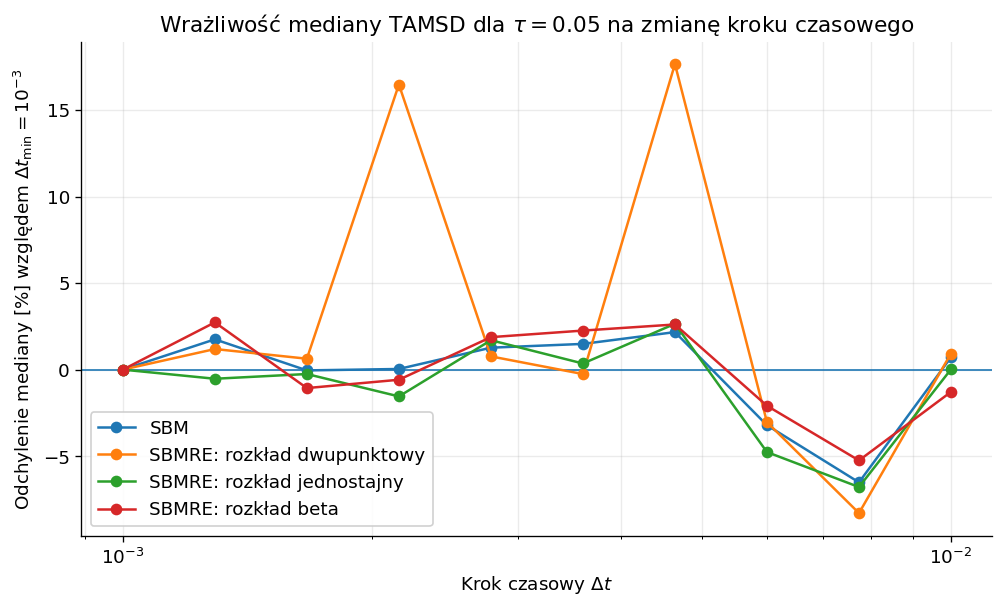

Maksymalne bezwzględne odchylenie mediany TAMSD względem dt_min:
SBM                         :  6.514%
SBMRE: rozkład dwupunktowy  : 17.656%
SBMRE: rozkład jednostajny  :  6.785%
SBMRE: rozkład beta         :  5.248%


In [101]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# WRAŻLIWOŚĆ TAMSD NA KROK CZASOWY dt (10 punktów) + 3 SBMRE
# ============================================================

# --- ustawienia bazowe ---
T = 10.0
alpha_sbm = 1.4
alpha0 = 1.4
eps = 0.1                     # 1.4 ± 0.6 => [0.8, 2.0]
tau_ref = 0.05                # to samo tau jak wcześniej
n_paths = 800                # daj 500-1000 żeby liczyło się szybko; 2000 będzie długo

# 10 kroków czasowych: od 1e-3 do 1e-2 równo w skali log
dt_list = np.logspace(-3, -2, 10)

# --- samplery SBMRE (3 warianty) ---
samplers = {
    "SBMRE: rozkład dwupunktowy": make_two_point_sampler(alpha0, eps),
    "SBMRE: rozkład jednostajny": make_uniform_sampler(alpha0, eps),
    "SBMRE: rozkład beta":        make_beta_sampler(alpha0, eps, a=0.5, b=0.5),
}

# --- pomocnicze: TAMSD dla jednej trajektorii i zadanego tau ---
def tamsd_single_tau(X, dt, tau):
    """
    X: (n_paths, N+1)
    dt: krok czasowy
    tau: opóźnienie (czas)
    Zwraca wektor TAMSD(tau) dla każdej trajektorii (n_paths,)
    """
    lag = int(np.round(tau / dt))
    if lag < 1:
        raise ValueError("tau jest za małe względem dt (lag < 1).")
    if lag >= X.shape[1]:
        raise ValueError("tau jest za duże względem długości trajektorii (lag >= N).")

    dX = X[:, lag:] - X[:, :-lag]
    return np.mean(dX**2, axis=1)

# --- wyniki: mediana TAMSD(tau) dla każdego dt i modelu ---
median_tamsd = {
    "SBM": [],
    **{k: [] for k in samplers.keys()}
}

seed_base = 202501

for i, dt in enumerate(dt_list):
    # SBM
    rng = np.random.default_rng(seed_base + 100*i)
    t_sbm, X_sbm = simulate_sbm(alpha_sbm, T, dt, n_paths, rng)
    vals = tamsd_single_tau(X_sbm, dt, tau_ref)
    median_tamsd["SBM"].append(np.median(vals))

    # SBMRE (3 rozkłady)
    for j, (name, sampler) in enumerate(samplers.items()):
        seed = seed_base + 10000*i + 10*j
        t_re, X_re, _ = simulate_sbmre(T=T, dt=dt, n_paths=n_paths, seed=seed, alpha_sampler=sampler)
        vals = tamsd_single_tau(X_re, dt, tau_ref)
        median_tamsd[name].append(np.median(vals))

# --- przelicz na odchylenie [%] względem dt_min = 1e-3 ---
dt_min = dt_list[0]
rel_change = {}
for name, med_list in median_tamsd.items():
    med = np.array(med_list, dtype=float)
    rel_change[name] = (med - med[0]) / med[0] * 100.0

# --- wykres ---
plt.figure(figsize=(8.5, 5.2))

# linia odniesienia
plt.axhline(0, linewidth=1)

# SBM
plt.plot(dt_list, rel_change["SBM"], marker="o", label="SBM")

# 3 SBMRE
for name in samplers.keys():
    plt.plot(dt_list, rel_change[name], marker="o", label=name)

plt.xscale("log")
plt.xlabel(r"Krok czasowy $\Delta t$")
plt.ylabel(r"Odchylenie mediany [%] względem $\Delta t_{\min}=10^{-3}$")
plt.title(rf"Wrażliwość mediany TAMSD dla $\tau={tau_ref}$ na zmianę kroku czasowego")
plt.grid(True, which="both", axis="both", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# --- (opcjonalnie) wypisz największe odchylenia ---
print("Maksymalne bezwzględne odchylenie mediany TAMSD względem dt_min:")
for name in ["SBM", *samplers.keys()]:
    mx = np.max(np.abs(rel_change[name]))
    print(f"{name:28s}: {mx:6.3f}%")


#### Analiza stabilności cech

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 0) Pomocnicze statystyki robust
# =========================================================
def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

def mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med))

def cv_percent(x):
    x = np.asarray(x, dtype=float)
    mu = np.mean(x)
    sd = np.std(x, ddof=1)
    return 100.0 * sd / mu if mu != 0 else np.nan

def mad_percent(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    return 100.0 * mad(x) / med if med != 0 else np.nan

# =========================================================
# 1) USTAWIENIA BAZOWE (możesz zmienić)
# =========================================================
seed_base = 1234
n_paths = 800                 # na laptopie 500–1200 zwykle ok

# cechy spójne z resztą rozdziału
tau_tamsd = 0.05

# SBM / SBMRE parametry
alpha_sbm_default = 1.4
alpha0 = 1.4
eps = 0.6  # => [0.8, 2.0]

samplers = {
    "SBMRE: dwupunktowy": make_two_point_sampler(alpha0, eps),
    "SBMRE: jednostajny": make_uniform_sampler(alpha0, eps),
    "SBMRE: beta":        make_beta_sampler(alpha0, eps, a=0.5, b=0.5),
}

# =========================================================
# 2) SCENARIUSZE — czyli "zmiany parametrów"
#    Tu robisz tak, żeby promotorce pokazać stabilność cech
# =========================================================
scenarios = [
    {"name": "bazowy",            "T": 10.0, "dt": 1e-3, "alpha_sbm": 1.4},
    {"name": "krótsza traj.",     "T":  5.0, "dt": 1e-3, "alpha_sbm": 1.4},
    {"name": "dłuższa traj.",     "T": 15.0, "dt": 1e-3, "alpha_sbm": 1.4},

    {"name": "rzadsza siatka",    "T": 10.0, "dt": 5e-3, "alpha_sbm": 1.4},
    {"name": "gęstsza siatka",    "T": 10.0, "dt": 5e-4, "alpha_sbm": 1.4},

    {"name": "subdyfuzja",        "T": 10.0, "dt": 1e-3, "alpha_sbm": 0.8},
    {"name": "superdyfuzja",      "T": 10.0, "dt": 1e-3, "alpha_sbm": 1.8},
]

# =========================================================
# 3) Funkcja licząca cechy dla jednego scenariusza i modelu
# =========================================================
def compute_features_for_paths(X, dt, T):
    tau_dma = T/5  # spójnie z Twoimi ustawieniami
    feats = {}

    # (A) TAMSD dla ustalonego tau
    feats["TAMSD_tau=0.05"] = tamsd_for_tau(X, dt, tau_tamsd)  # wektor (n_paths,)

    # (B) DMA dla tau = T/5
    feats["DMA_tau=T/5"] = dma_for_tau(X, dt, tau_dma)         # wektor (n_paths,)

    # (C) Kurtoza przyrostów
    feats["Kurtoza_przyrostów"] = kurtosis_increments(X)       # wektor (n_paths,)

    return feats

# =========================================================
# 4) GŁÓWNA PĘTLA: symulacje + agregacja cech
#    Agregujemy per scenariusz: mediana oraz IQR dla każdej cechy
# =========================================================
rows = []

for si, sc in enumerate(scenarios):
    T = sc["T"]
    dt = sc["dt"]
    alpha_sbm = sc["alpha_sbm"]
    name_sc = sc["name"]

    # --- SBM ---
    rng = np.random.default_rng(seed_base + 1000*si + 1)
    _, X_sbm = simulate_sbm(alpha_sbm, T, dt, n_paths, rng)
    feats_sbm = compute_features_for_paths(X_sbm, dt, T)

    for feat_name, values in feats_sbm.items():
        rows.append({
            "scenariusz": name_sc, "model": "SBM", "cecha": feat_name,
            "mediana": float(np.median(values)),
            "IQR": float(iqr(values))
        })

    # --- SBMRE (3 rozkłady) ---
    for j, (model_name, sampler) in enumerate(samplers.items()):
        _, X_re, A_re = simulate_sbmre(
            T=T, dt=dt, n_paths=n_paths,
            seed=seed_base + 1000*si + 100 + 10*j,
            alpha_sampler=sampler
        )
        feats_re = compute_features_for_paths(X_re, dt, T)

        for feat_name, values in feats_re.items():
            rows.append({
                "scenariusz": name_sc, "model": model_name, "cecha": feat_name,
                "mediana": float(np.median(values)),
                "IQR": float(iqr(values))
            })

df = pd.DataFrame(rows)

# =========================================================
# 5) STABILNOŚĆ CECH: zmienność median między scenariuszami
#    Robimy to osobno dla SBM i osobno dla SBMRE (średnio po rozkładach),
#    a na końcu możemy też zrobić "globalnie".
# =========================================================
# (A) Stabilność dla SBM
stab_sbm = (
    df[df["model"] == "SBM"]
    .groupby("cecha")["mediana"]
    .apply(lambda x: pd.Series({
        "CV_median_%": cv_percent(x),
        "MAD_median_%": mad_percent(x),
        "min_median": float(np.min(x)),
        "max_median": float(np.max(x)),
    }))
    .reset_index()
)

# (B) Stabilność dla SBMRE: bierzemy mediany, uśredniamy po rozkładach w danym scenariuszu,
#     a potem liczymy zmienność między scenariuszami
df_re = df[df["model"].str.startswith("SBMRE")].copy()
df_re_mean = (
    df_re.groupby(["scenariusz", "cecha"])["mediana"]
    .mean()
    .reset_index()
)

stab_sbmre = (
    df_re_mean.groupby("cecha")["mediana"]
    .apply(lambda x: pd.Series({
        "CV_median_%": cv_percent(x),
        "MAD_median_%": mad_percent(x),
        "min_median": float(np.min(x)),
        "max_median": float(np.max(x)),
    }))
    .reset_index()
)

stab_sbm["zbiór"] = "SBM"
stab_sbmre["zbiór"] = "SBMRE (średnio po rozkładach)"
stab = pd.concat([stab_sbm, stab_sbmre], ignore_index=True)

# =========================================================
# 6) WYKRES SŁUPKOWY: stabilność (np. CV mediany w %)
# =========================================================
# sortujemy cechy od najbardziej stabilnych (mały CV) do najmniej
stab_plot = stab.sort_values(["zbiór", "CV_median_%"], ascending=[True, True])

fig, ax = plt.subplots(figsize=(10, 4.5))
# robimy osobne słupki: SBM i SBMRE
for grp_name, grp in stab_plot.groupby("zbiór"):
    ax.bar(grp["cecha"] + " | " + grp_name, grp["CV_median_%"])

ax.set_ylabel("Współczynnik zmienności mediany (CV) [%]")
ax.set_title("Stabilność cech względem zmian parametrów symulacji")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# =========================================================
# 7) TABELKA POD WYKRES (do opisu w pracy)
# =========================================================
stab_rounded = stab.copy()
for col in ["CV_median_%", "MAD_median_%", "min_median", "max_median"]:
    stab_rounded[col] = stab_rounded[col].map(lambda v: np.nan if pd.isna(v) else round(v, 3))

display(stab_rounded.sort_values(["zbiór", "CV_median_%"]))


KeyError: 'CV_median_%'

Kolumny w stab: ['cecha', 'CV_median_%', 'MAD_median_%', 'min_median', 'max_median', 'zbiór']


,cecha,CV_median_%,MAD_median_%,min_median,max_median,zbiór
1,Kurtoza_przyrostów,5.594346,0.060073,3.185905,3.736455,SBM
2,TAMSD_tau=0.05,63.227129,17.495944,0.031342,0.316357,SBM
0,DMA_tau=T/5,71.773394,60.541927,0.339184,4.225155,SBM
4,Kurtoza_przyrostów,1.886132,1.077380,3.325928,3.481135,SBMRE (średnio po rozkładach)
5,TAMSD_tau=0.05,43.786846,27.642458,0.075621,0.307130,SBMRE (średnio po rozkładach)
3,DMA_tau=T/5,53.942345,33.233658,0.560613,3.752268,SBMRE (średnio po rozkładach)


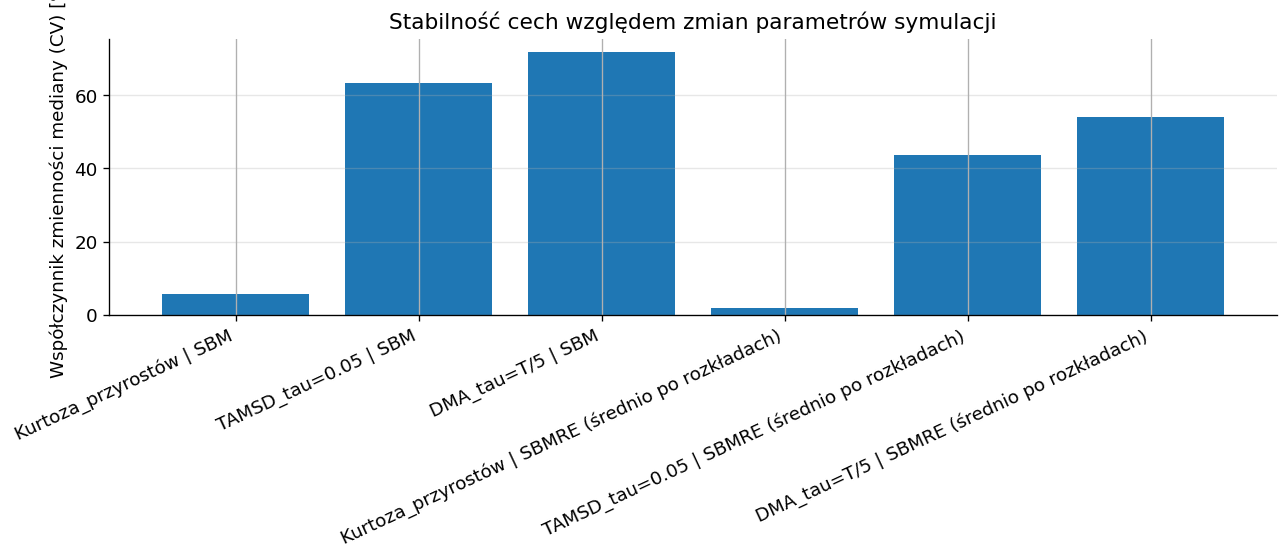

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- funkcje ----------
def iqr(x):
    x = np.asarray(x)
    return np.percentile(x, 75) - np.percentile(x, 25)

def mad(x):
    x = np.asarray(x)
    med = np.median(x)
    return np.median(np.abs(x - med))

def cv_percent(x):
    x = np.asarray(x, dtype=float)
    mu = np.mean(x)
    sd = np.std(x, ddof=1)
    return 100.0 * sd / mu if mu != 0 else np.nan

def mad_percent(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    return 100.0 * mad(x) / med if med != 0 else np.nan

# =========================================================
# STABILNOŚĆ CECH — wersja odporna na układ kolumn
# =========================================================

# 1) SBM: bierzemy mediany cech w scenariuszach i liczymy zmienność między scenariuszami
df_sbm = df[df["model"] == "SBM"].copy()

stab_sbm = (
    df_sbm.groupby("cecha")["mediana"]
    .agg(
        CV_median_ = cv_percent,
        MAD_median_ = mad_percent,
        min_median = "min",
        max_median = "max",
    )
    .reset_index()
)

stab_sbm = stab_sbm.rename(columns={
    "CV_median_": "CV_median_%",
    "MAD_median_": "MAD_median_%",
})
stab_sbm["zbiór"] = "SBM"

# 2) SBMRE: najpierw uśredniamy mediany po rozkładach w ramach scenariusza, potem stabilność
df_re = df[df["model"].str.startswith("SBMRE")].copy()

df_re_mean = (
    df_re.groupby(["scenariusz", "cecha"])["mediana"]
    .mean()
    .reset_index()
)

stab_sbmre = (
    df_re_mean.groupby("cecha")["mediana"]
    .agg(
        CV_median_ = cv_percent,
        MAD_median_ = mad_percent,
        min_median = "min",
        max_median = "max",
    )
    .reset_index()
)

stab_sbmre = stab_sbmre.rename(columns={
    "CV_median_": "CV_median_%",
    "MAD_median_": "MAD_median_%",
})
stab_sbmre["zbiór"] = "SBMRE (średnio po rozkładach)"

# 3) Łącznie
stab = pd.concat([stab_sbm, stab_sbmre], ignore_index=True)

# --- szybki debug, żebyś widziała co jest w środku ---
print("Kolumny w stab:", list(stab.columns))
display(stab.sort_values(["zbiór", "CV_median_%"]))

# =========================================================
# Wykres słupkowy (CV mediany)
# =========================================================
stab_plot = stab.sort_values(["zbiór", "CV_median_%"], ascending=[True, True]).copy()
stab_plot["label"] = stab_plot["cecha"] + " | " + stab_plot["zbiór"]

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(stab_plot["label"], stab_plot["CV_median_%"])
ax.set_ylabel("Współczynnik zmienności mediany (CV) [%]")
ax.set_title("Stabilność cech względem zmian parametrów symulacji")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
